In [ ]:
import os
import shutil
import random
import hashlib
from pathlib import Path

# ==========================================================
# Configuration
# ==========================================================

SOURCE_DIR  = "/content/drive/MyDrive/Dataset/Rice Leaf Images"
DEST_DIR    = "/content/drive/MyDrive/Dataset/Rice Leaf Images Split Clean"

TRAIN_RATIO = 0.80
VAL_RATIO   = 0.10
TEST_RATIO  = 0.10
SEED        = 42

random.seed(SEED)

# ==========================================================
# Step 1 — Collect all images per class, deduplicate by hash
# ==========================================================

classes = sorted([
    d for d in os.listdir(SOURCE_DIR)
    if os.path.isdir(os.path.join(SOURCE_DIR, d))
])

print("Deduplicating dataset...")
print("=" * 50)

total_removed = 0

for cls in classes:
    cls_path  = os.path.join(SOURCE_DIR, cls)
    all_files = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    # Hash every file — keep only one copy of each unique image
    seen_hashes = {}
    unique_files = []
    duplicates   = 0

    for fname in sorted(all_files):
        fpath = os.path.join(cls_path, fname)
        with open(fpath, 'rb') as f:
            h = hashlib.md5(f.read()).hexdigest()
        if h not in seen_hashes:
            seen_hashes[h] = fname
            unique_files.append(fname)
        else:
            duplicates += 1

    total_removed += duplicates
    print(f"{cls:<20}: {len(all_files):>4} total  "
          f"→  {len(unique_files):>4} unique  "
          f"({duplicates} duplicates removed)")

    # ==========================================================
    # Step 2 — Split unique images 80/10/10
    # ==========================================================

    random.shuffle(unique_files)

    n         = len(unique_files)
    n_train   = int(n * TRAIN_RATIO)
    n_val     = int(n * VAL_RATIO)

    train_imgs = unique_files[:n_train]
    val_imgs   = unique_files[n_train:n_train + n_val]
    test_imgs  = unique_files[n_train + n_val:]

    # ==========================================================
    # Step 3 — Copy to destination
    # ==========================================================

    for split, imgs in [("train", train_imgs),
                        ("val",   val_imgs),
                        ("test",  test_imgs)]:
        dest_path = Path(DEST_DIR) / split / cls
        dest_path.mkdir(parents=True, exist_ok=True)
        for img in imgs:
            shutil.copy(
                os.path.join(cls_path, img),
                dest_path / img
            )

    print(f"  {'train':>6}: {len(train_imgs)}  "
          f"{'val':>4}: {len(val_imgs)}  "
          f"{'test':>5}: {len(test_imgs)}")
    print()

print("=" * 50)
print(f"Total duplicates removed : {total_removed}")
print(f"Clean dataset saved to   : {DEST_DIR}")

# ==========================================================
# Step 4 — Verify no leakage in new split
# ==========================================================

def get_hashes(directory):
    hashes = set()
    for cls in os.listdir(directory):
        cls_path = os.path.join(directory, cls)
        if not os.path.isdir(cls_path):
            continue
        for fname in os.listdir(cls_path):
            fpath = os.path.join(cls_path, fname)
            with open(fpath, 'rb') as f:
                hashes.add(hashlib.md5(f.read()).hexdigest())
    return hashes

print("\nVerifying clean split...")
train_h = get_hashes(os.path.join(DEST_DIR, "train"))
val_h   = get_hashes(os.path.join(DEST_DIR, "val"))
test_h  = get_hashes(os.path.join(DEST_DIR, "test"))

tv_overlap  = train_h & val_h
tt_overlap  = train_h & test_h
vt_overlap  = val_h   & test_h

print(f"Train ∩ Val  : {len(tv_overlap)} duplicates")
print(f"Train ∩ Test : {len(tt_overlap)} duplicates")
print(f"Val   ∩ Test : {len(vt_overlap)} duplicates")

if len(tv_overlap) == len(tt_overlap) == len(vt_overlap) == 0:
    print("\n✅ Clean split verified — no leakage detected")
    print(f"Update your config:")
    print(f'  DATASET_DIR = "{DEST_DIR}"')
else:
    print("\n❌ Still has overlap — investigate source dataset further")

Deduplicating dataset...
BacterialBlight     :  982 total  →   821 unique  (161 duplicates removed)
   train: 656   val: 82   test: 83

Blast               :  957 total  →   777 unique  (180 duplicates removed)
   train: 621   val: 77   test: 79

BrownSpot           :  857 total  →   670 unique  (187 duplicates removed)
   train: 536   val: 67   test: 67

Healthy             :  971 total  →   968 unique  (3 duplicates removed)
   train: 774   val: 96   test: 98

Tungro              :  974 total  →   974 unique  (0 duplicates removed)
   train: 779   val: 97   test: 98

Total duplicates removed : 531
Clean dataset saved to   : /content/drive/MyDrive/Dataset/Rice Leaf Images Split Clean

Verifying clean split...
Train ∩ Val  : 0 duplicates
Train ∩ Test : 0 duplicates
Val   ∩ Test : 0 duplicates

✅ Clean split verified — no leakage detected
Update your config:
  DATASET_DIR = "/content/drive/MyDrive/Dataset/Rice Leaf Images Split Clean"


# Rice Leaf Disease Detection using Lightweight CNN

This notebook implements a complete deep learning pipeline for rice leaf disease classification.

Workflow:

1. Import Libraries
2. Dataset Preparation
3. Image Preprocessing
4. Data Augmentation
5. Dataset & DataLoader
6. Model Development
7. Training
8. Evaluation
9. Performance Analysis

In [ ]:
# ==========================================================
# 1. Import Required Libraries
# ==========================================================

# Standard Libraries
import os
import random
import time
import copy
from pathlib import Path

# Numerical Computing
import numpy as np

# Image Processing
import cv2
from PIL import Image

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Progress Bar
from tqdm import tqdm

# Machine Learning Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision import models

print("PyTorch Version :", torch.__version__)
print("Torchvision Version :", torchvision.__version__)

PyTorch Version : 2.11.0+cu128
Torchvision Version : 0.26.0+cu128


In [ ]:
# ==========================================================
# 2. Set Random Seed for Reproducibility
# ==========================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Random seed set successfully!")

Random seed set successfully!


## 2. Configuration

This section defines all configurable parameters used throughout the project, including dataset paths, image size, batch size, training hyperparameters, and device selection.

In [ ]:
# ==========================================================
# 2. Configuration
# ==========================================================

# Dataset Paths
DATASET_DIR = "/content/drive/MyDrive/Dataset/Rice Leaf Images Split Clean"

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR   = os.path.join(DATASET_DIR, "val")
TEST_DIR  = os.path.join(DATASET_DIR, "test")

# Image Parameters
RESIZE_SIZE = 256
IMAGE_SIZE = 224

# Training Parameters
BATCH_SIZE = 32
NUM_CLASSES = 5
EPOCHS = 30

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

# DataLoader
NUM_WORKERS = 2

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device : {DEVICE}")

Device : cuda


In [ ]:
# ==========================================================
# 3. Verify Dataset Structure
# ==========================================================

from collections import Counter

splits = {
    "Train": TRAIN_DIR,
    "Validation": VAL_DIR,
    "Test": TEST_DIR
}

for split_name, split_path in splits.items():
    print(f"\n{split_name} Dataset")
    print("-" * 40)

    total_images = 0

    for cls in sorted(os.listdir(split_path)):
        cls_path = os.path.join(split_path, cls)

        if not os.path.isdir(cls_path):
            continue

        count = len([
            f for f in os.listdir(cls_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])

        total_images += count
        print(f"{cls:<20}: {count}")

    print("-" * 40)
    print(f"Total Images: {total_images}")


Train Dataset
----------------------------------------
BacterialBlight     : 656
Blast               : 621
BrownSpot           : 536
Healthy             : 774
Tungro              : 779
----------------------------------------
Total Images: 3366

Validation Dataset
----------------------------------------
BacterialBlight     : 82
Blast               : 77
BrownSpot           : 67
Healthy             : 96
Tungro              : 97
----------------------------------------
Total Images: 419

Test Dataset
----------------------------------------
BacterialBlight     : 83
Blast               : 79
BrownSpot           : 69
Healthy             : 98
Tungro              : 98
----------------------------------------
Total Images: 427


## 3. Dataset Analysis

This section provides an overview of the dataset, including:

- Number of images in each class
- Distribution across train, validation, and test sets
- Sample images from each class

In [ ]:
# ==========================================================
# Dataset Summary
# ==========================================================

import pandas as pd

classes = sorted(os.listdir(TRAIN_DIR))

dataset_summary = []

for cls in classes:

    train_count = len([
        f for f in os.listdir(os.path.join(TRAIN_DIR, cls))
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    val_count = len([
        f for f in os.listdir(os.path.join(VAL_DIR, cls))
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    test_count = len([
        f for f in os.listdir(os.path.join(TEST_DIR, cls))
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    dataset_summary.append({
        "Class": cls,
        "Train": train_count,
        "Validation": val_count,
        "Test": test_count,
        "Total": train_count + val_count + test_count
    })

dataset_df = pd.DataFrame(dataset_summary)

dataset_df

,Class,Train,Validation,Test,Total
0,BacterialBlight,656,82,83,821
1,Blast,621,77,79,777
2,BrownSpot,536,67,69,672
3,Healthy,774,96,98,968
4,Tungro,779,97,98,974


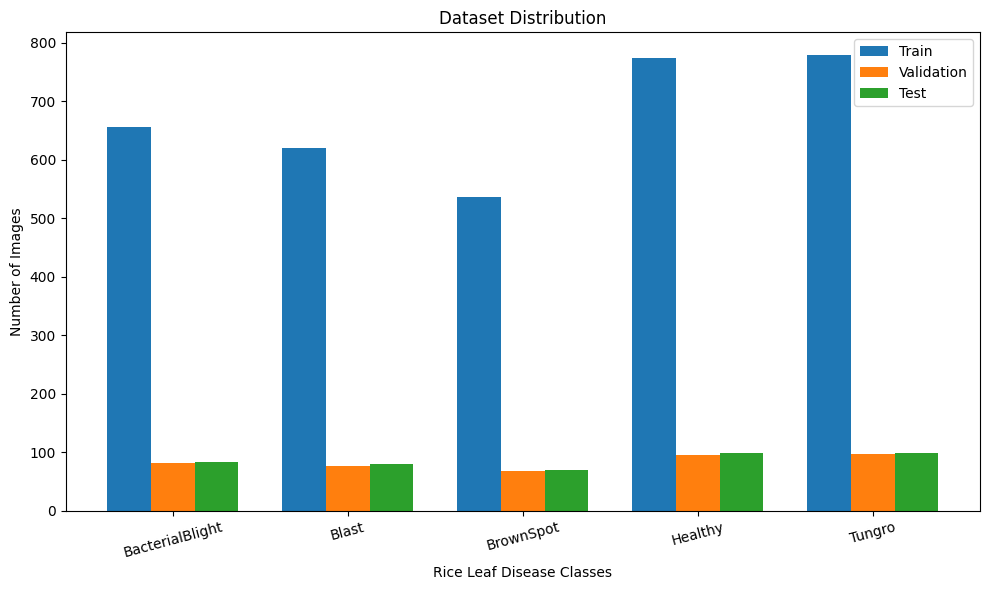

In [ ]:
# ==========================================================
# Plot Dataset Distribution
# ==========================================================

plt.figure(figsize=(10,6))

x = np.arange(len(dataset_df))

width = 0.25

plt.bar(x-width,
        dataset_df["Train"],
        width,
        label="Train")

plt.bar(x,
        dataset_df["Validation"],
        width,
        label="Validation")

plt.bar(x+width,
        dataset_df["Test"],
        width,
        label="Test")

plt.xticks(x, dataset_df["Class"], rotation=15)

plt.ylabel("Number of Images")
plt.xlabel("Rice Leaf Disease Classes")
plt.title("Dataset Distribution")

plt.legend()

plt.tight_layout()

plt.show()

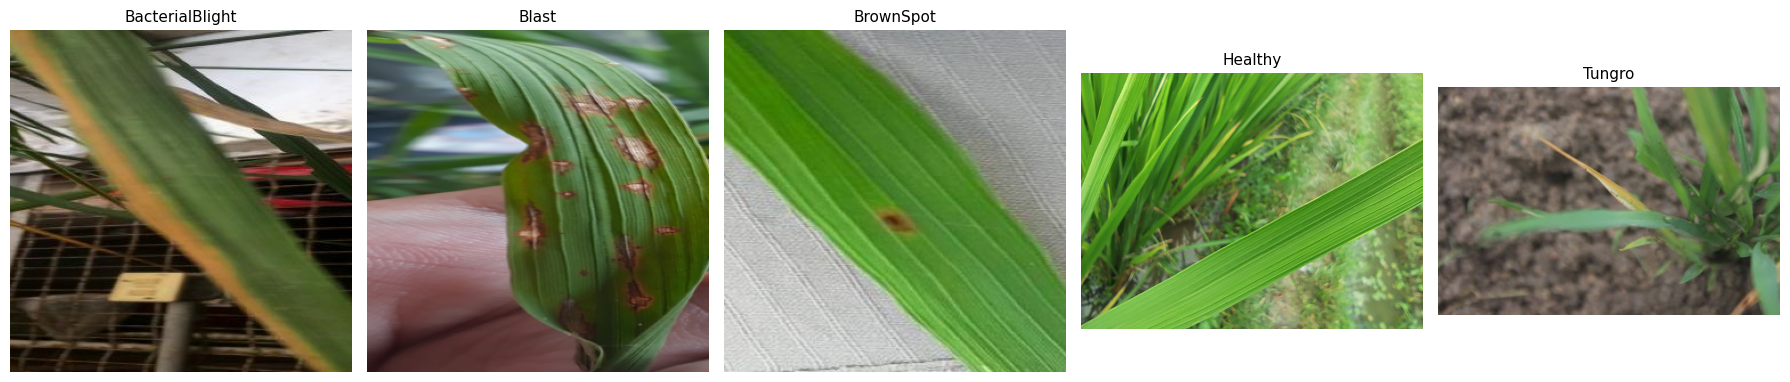

In [ ]:
# ==========================================================
# Display Sample Images
# ==========================================================

fig, axes = plt.subplots(1, len(classes), figsize=(18,5))

for ax, cls in zip(axes, classes):

    img_path = os.path.join(
        TRAIN_DIR,
        cls,
        random.choice(os.listdir(os.path.join(TRAIN_DIR, cls)))
    )

    image = Image.open(img_path).convert("RGB")

    ax.imshow(image)
    ax.set_title(cls, fontsize=11)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 4. Image Preprocessing

To improve image quality before feature extraction, a sequence of image enhancement techniques is applied.

The preprocessing pipeline consists of:

1. Resize
2. White Balance
3. CLAHE
4. Bilateral Filtering
5. Unsharp Masking
6. HSV Enhancement

Each preprocessing operation can be enabled or disabled independently, allowing ablation studies to evaluate its contribution.

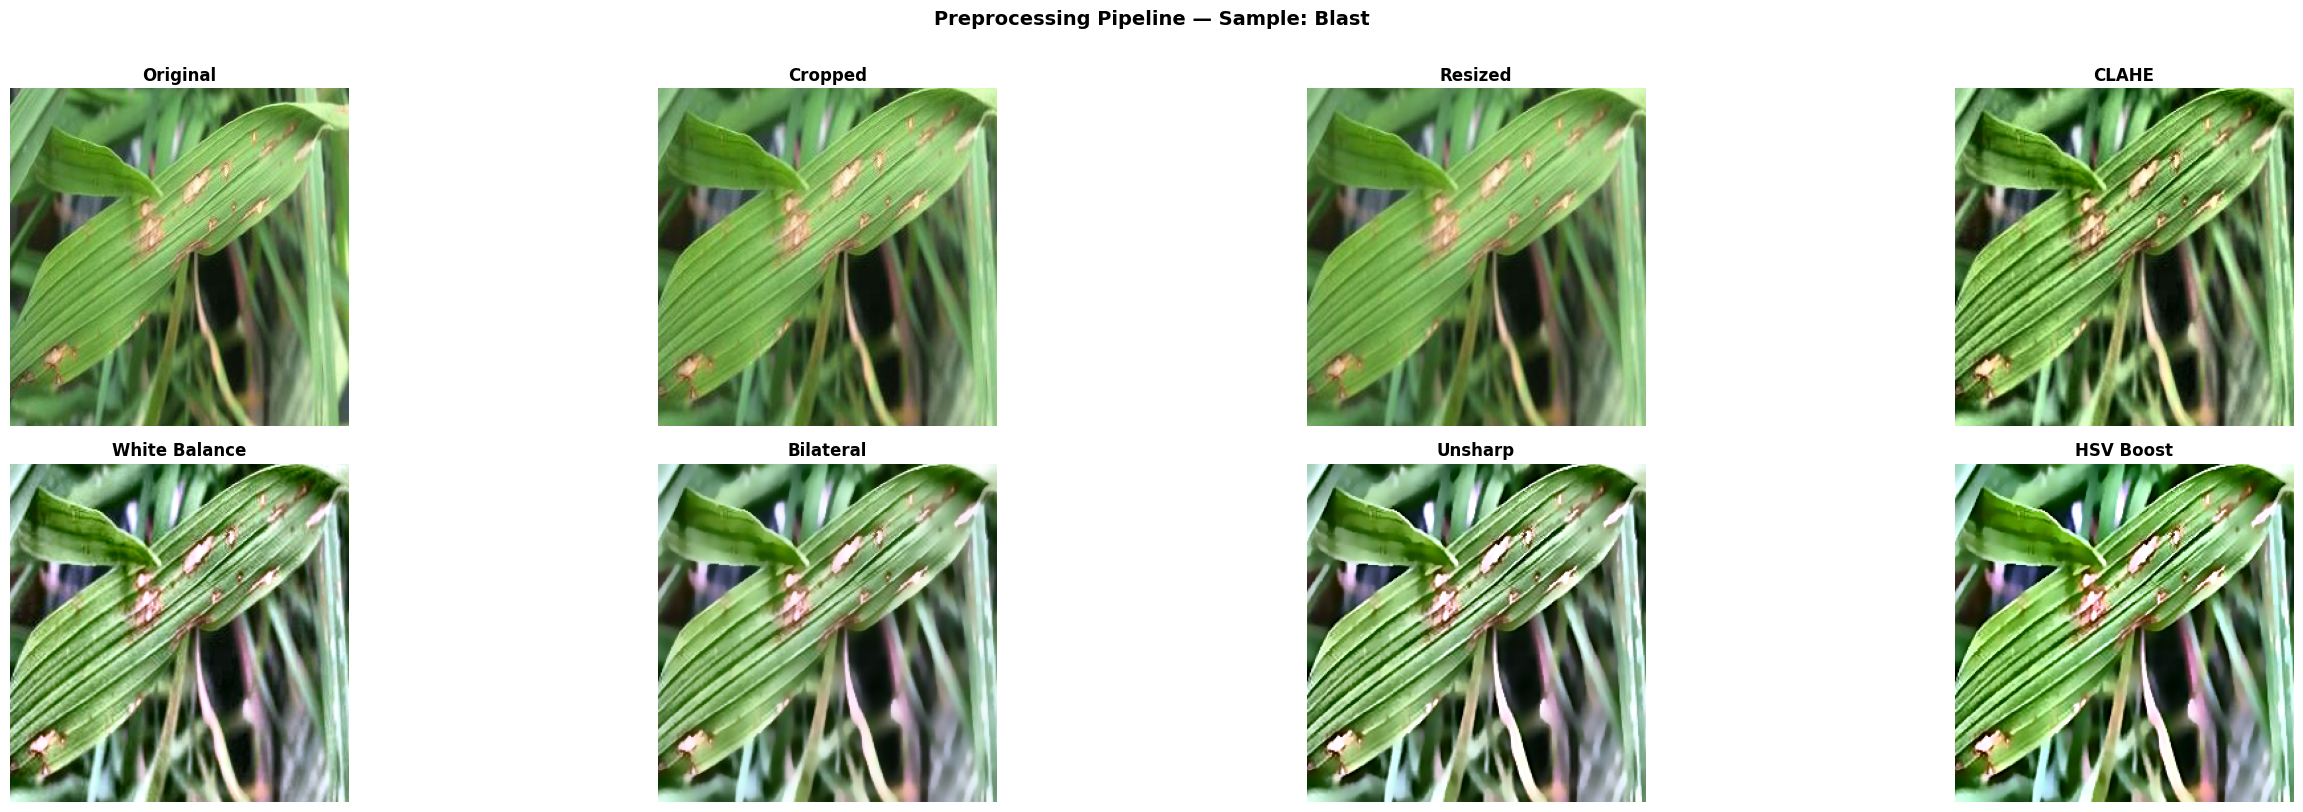

Preprocessing pipeline complete.
Final output size : (256, 256, 3)


In [ ]:
# ==========================================================
# Preprocessing Configuration
# ==========================================================

PREPROCESS_CONFIG = {
    "crop":          True,
    "resize":        True,
    "clahe":         True,
    "white_balance": True,
    "bilateral":     True,
    "unsharp":       True,
    "hsv_boost":     True,
}


# ==========================================================
# Preprocessing Functions
# ==========================================================

def center_crop_leaf(img_rgb, crop_ratio=0.90):
    """
    Crop 90% of center to remove background borders.
    Many rice disease dataset images (Mendeley, Kaggle) are
    taken in lab/studio conditions with plain or patterned
    backgrounds. Those borders cause white balance to produce
    purple/pink edge artifacts.
    90% crop safely removes borders while keeping the full
    leaf area — lesions are almost never at the very edge.
    For genuine field photos with no border, this has
    negligible effect since the leaf fills the frame anyway.
    """
    h, w = img_rgb.shape[:2]
    new_h = int(h * crop_ratio)
    new_w = int(w * crop_ratio)
    top  = (h - new_h) // 2
    left = (w - new_w) // 2
    return img_rgb[top:top + new_h, left:left + new_w]


def apply_clahe(img_rgb):
    """
    Contrast Limited Adaptive Histogram Equalization.
    Applied FIRST — fixes uneven field lighting before
    any color processing. Works on L-channel (LAB) only
    so lesion colors are not affected.
    clipLimit=3.0 stronger than default 2.0 because rice
    field images often have very low local contrast.
    """
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)


def apply_white_balance(img_rgb):
    """
    Von Kries white balance using 98th percentile per channel.
    Applied AFTER CLAHE so specular highlights are already
    dampened — prevents over-brightening the entire image.
    Scale cap of 1.5x prevents any channel being amplified
    too aggressively on remaining edge pixels.
    """
    img = img_rgb.astype(np.float32)
    for i in range(3):
        p98 = np.percentile(img[:, :, i], 98)
        if p98 > 0:
            scale = min(255.0 / p98, 1.5)
            img[:, :, i] = np.clip(img[:, :, i] * scale, 0, 255)
    return img.astype(np.uint8)


def apply_bilateral(img_rgb):
    """
    Edge-preserving noise reduction.
    Removes smartphone JPEG noise / compression artifacts
    that look like small lesion dots to a CNN,
    while keeping actual lesion boundaries sharp.
    """
    return cv2.bilateralFilter(img_rgb, d=9, sigmaColor=75, sigmaSpace=75)


def apply_unsharp_mask(img_rgb, strength=0.6):
    """
    Sharpens lesion edges after bilateral smoothing.
    Critical for Bacterial Blight (water-soaked margins)
    and Brown Spot (brown halo with yellow ring) — both
    rely on sharp lesion boundaries for diagnosis.
    """
    blurred = cv2.GaussianBlur(img_rgb, (0, 0), sigmaX=2)
    return cv2.addWeighted(img_rgb, 1 + strength, blurred, -strength, 0)


def apply_hsv_boost(img_rgb):
    """
    Boosts saturation to widen color gap between
    healthy green tissue and lesion colors
    (yellow-brown for Tungro, dark brown for Brown Spot,
    pale grey-green for Blast).
    saturation x1.35 for field images desaturated by sunlight.
    brightness x1.05 — subtle lift only.
    Green channel dominance is naturally handled here —
    HSV boost widens color separation without the purple
    artifacts caused by direct green channel manipulation.
    """
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV).astype(np.float32)
    hsv[:, :, 1] = np.clip(hsv[:, :, 1] * 1.35, 0, 255)
    hsv[:, :, 2] = np.clip(hsv[:, :, 2] * 1.05, 0, 255)
    return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)


def preprocess_image(img_rgb):
    """
    Complete preprocessing pipeline — 7 steps, correct order:

      0. Center Crop    → remove background borders FIRST
      1. Resize         → standard size (256x256)
      2. CLAHE          → fix contrast before color processing
      3. White Balance  → safe now, highlights already dampened
      4. Bilateral      → noise removal, preserve edges
      5. Unsharp        → restore sharpness after bilateral
      6. HSV Boost      → enhance lesion color visibility

    NOTE: Green channel normalization intentionally removed.
    It caused purple artifacts on water/soil/mud backgrounds
    which are common in real rice field photos. CLAHE +
    HSV Boost together already handle green dominance safely.

    Apply to ALL images (train / val / test) before transforms.
    """
    if PREPROCESS_CONFIG["crop"]:
        img_rgb = center_crop_leaf(img_rgb, crop_ratio=0.90)

    if PREPROCESS_CONFIG["resize"]:
        img_rgb = cv2.resize(img_rgb, (RESIZE_SIZE, RESIZE_SIZE), interpolation=cv2.INTER_AREA)

    if PREPROCESS_CONFIG["clahe"]:
        img_rgb = apply_clahe(img_rgb)

    if PREPROCESS_CONFIG["white_balance"]:
        img_rgb = apply_white_balance(img_rgb)

    if PREPROCESS_CONFIG["bilateral"]:
        img_rgb = apply_bilateral(img_rgb)

    if PREPROCESS_CONFIG["unsharp"]:
        img_rgb = apply_unsharp_mask(img_rgb)

    if PREPROCESS_CONFIG["hsv_boost"]:
        img_rgb = apply_hsv_boost(img_rgb)

    return img_rgb


# ==========================================================
# Visualize Each Preprocessing Step
# ==========================================================

sample_class = random.choice(os.listdir(TRAIN_DIR))

sample_image_path = os.path.join(
    TRAIN_DIR,
    sample_class,
    random.choice(os.listdir(os.path.join(TRAIN_DIR, sample_class)))
)

# Read image
original = cv2.imread(sample_image_path)
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

# Apply each step sequentially — each feeds into the next
cropped        = center_crop_leaf(original, crop_ratio=0.90)
resized        = cv2.resize(cropped, (RESIZE_SIZE, RESIZE_SIZE))
clahe_img      = apply_clahe(resized)
white_balanced = apply_white_balance(clahe_img)
bilateral_img  = apply_bilateral(white_balanced)
unsharp_img    = apply_unsharp_mask(bilateral_img)
hsv_img        = apply_hsv_boost(unsharp_img)

# Collect all stages
images = [
    original,
    cropped,
    resized,
    clahe_img,
    white_balanced,
    bilateral_img,
    unsharp_img,
    hsv_img,
]

titles = [
    "Original",
    "Cropped",
    "Resized",
    "CLAHE",
    "White Balance",
    "Bilateral",
    "Unsharp",
    "HSV Boost",
]

# Plot — 2 rows x 4 cols = 8 slots (exactly 8 images)
plt.figure(figsize=(28, 8))

for i, (img, title) in enumerate(zip(images, titles), 1):
    plt.subplot(2, 4, i)
    plt.imshow(img)
    plt.title(title, fontsize=12, fontweight='bold')
    plt.axis("off")

plt.suptitle(
    f"Preprocessing Pipeline — Sample: {sample_class}",
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

print("Preprocessing pipeline complete.")
print(f"Final output size : {hsv_img.shape}")

## 5. Data Augmentation

To improve the generalization ability of the CNN model and reduce overfitting,
data augmentation techniques are applied only to the training images.

The validation and test datasets are not augmented to ensure a fair and
unbiased evaluation of model performance.

In [ ]:
# ==========================================================
# ImageNet Normalization
# ==========================================================

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

In [ ]:
# ==========================================================
# Training Data Augmentation
# ==========================================================

train_transform = transforms.Compose([

    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.80, 1.00)
    ),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomVerticalFlip(p=0.3),

    transforms.RandomRotation(degrees=30),

    transforms.ColorJitter(
        brightness=0.20,
        contrast=0.20,
        saturation=0.20,
        hue=0.03
    ),

    transforms.GaussianBlur(
        kernel_size=3,
        sigma=(0.1,1.0)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )

])

In [ ]:
# ==========================================================
# Validation / Test Transform
# ==========================================================

test_transform = transforms.Compose([

    transforms.CenterCrop(IMAGE_SIZE),

    transforms.ToTensor(),

    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )

])

In [ ]:
print("Training Transform")
print(train_transform)

print("\nValidation/Test Transform")
print(test_transform)

Training Transform
Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.3)
    RandomRotation(degrees=[-30.0, 30.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.03, 0.03))
    GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 1.0))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Validation/Test Transform
Compose(
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [ ]:
# ==========================================================
# Dataset Utilities
# ==========================================================

from torch.utils.data import Dataset
from PIL import Image

In [ ]:
# ==========================================================
# Custom Rice Leaf Dataset
# ==========================================================

class RiceLeafDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.root_dir = root_dir
        self.transform = transform

        self.classes = sorted([
            d for d in os.listdir(root_dir)
            if os.path.isdir(os.path.join(root_dir, d))
        ])

        self.class_to_idx = {
            cls: idx
            for idx, cls in enumerate(self.classes)
        }

        self.samples = []

        for cls in self.classes:

            class_path = os.path.join(root_dir, cls)

            for file_name in sorted(os.listdir(class_path)):

                if file_name.lower().endswith(
                    (".jpg", ".jpeg", ".png")
                ):

                    self.samples.append(

                        (
                            os.path.join(class_path, file_name),
                            self.class_to_idx[cls]
                        )

                    )

    def __len__(self):

        return len(self.samples)

    def __getitem__(self, index):

        image_path, label = self.samples[index]

        # Read image
        image = cv2.imread(image_path)

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        # Apply preprocessing
        image = preprocess_image(image)

        # Convert to PIL
        image = Image.fromarray(image)

        # Apply augmentation / transforms
        if self.transform:

            image = self.transform(image)

        return image, label

In [ ]:
# ==========================================================
# Create Dataset Objects
# ==========================================================

train_dataset = RiceLeafDataset(

    TRAIN_DIR,

    transform=train_transform

)

val_dataset = RiceLeafDataset(

    VAL_DIR,

    transform=test_transform

)

test_dataset = RiceLeafDataset(

    TEST_DIR,

    transform=test_transform

)

In [ ]:
print("Training Images   :", len(train_dataset))
print("Validation Images :", len(val_dataset))
print("Testing Images    :", len(test_dataset))

print("\nClasses")

for idx, cls in enumerate(train_dataset.classes):

    print(f"{idx} : {cls}")

Training Images   : 3366
Validation Images : 419
Testing Images    : 427

Classes
0 : BacterialBlight
1 : Blast
2 : BrownSpot
3 : Healthy
4 : Tungro


In [ ]:
image, label = train_dataset[0]

print("Image Shape :", image.shape)
print("Label :", label)
print("Class :", train_dataset.classes[label])

Image Shape : torch.Size([3, 224, 224])
Label : 0
Class : BacterialBlight


## 7. DataLoader

PyTorch DataLoaders are created for the training,
validation, and test datasets.

The training DataLoader shuffles the data before
each epoch to improve model generalization,
whereas the validation and test DataLoaders
preserve the original order.

In [ ]:
# ==========================================================
# Create DataLoaders
# ==========================================================

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(NUM_WORKERS > 0)
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(NUM_WORKERS > 0)
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(NUM_WORKERS > 0)
)

In [ ]:
# ==========================================================
# Verify DataLoaders
# ==========================================================

print(f"Training batches   : {len(train_loader)}")
print(f"Validation batches : {len(val_loader)}")
print(f"Testing batches    : {len(test_loader)}")

Training batches   : 106
Validation batches : 14
Testing batches    : 14


In [ ]:
# ==========================================================
# Inspect One Batch
# ==========================================================

images, labels = next(iter(train_loader))

print(f"Batch Image Shape : {images.shape}")
print(f"Batch Label Shape : {labels.shape}")

print(f"\nData Type : {images.dtype}")

print(f"Device : {images.device}")

print(f"\nImage Min : {images.min():.3f}")
print(f"Image Max : {images.max():.3f}")

Batch Image Shape : torch.Size([32, 3, 224, 224])
Batch Label Shape : torch.Size([32])

Data Type : torch.float32
Device : cpu

Image Min : -2.118
Image Max : 2.640


## 8. Data Visualization

This section visualizes samples from the training and validation
datasets after preprocessing and data augmentation.

The objective is to verify that:

- Images are loaded correctly.
- The preprocessing pipeline is working as expected.
- Data augmentation produces realistic variations.
- Class labels are assigned correctly.

In [ ]:
# ==========================================================
# Helper Function for Visualization
# ==========================================================

def denormalize(image_tensor):
    """
    Convert normalized tensor back to displayable RGB image.
    """

    image = image_tensor.clone().cpu()

    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std = torch.tensor(IMAGENET_STD).view(3,1,1)

    image = image * std + mean
    image = image.clamp(0,1)

    return image.permute(1,2,0).numpy()

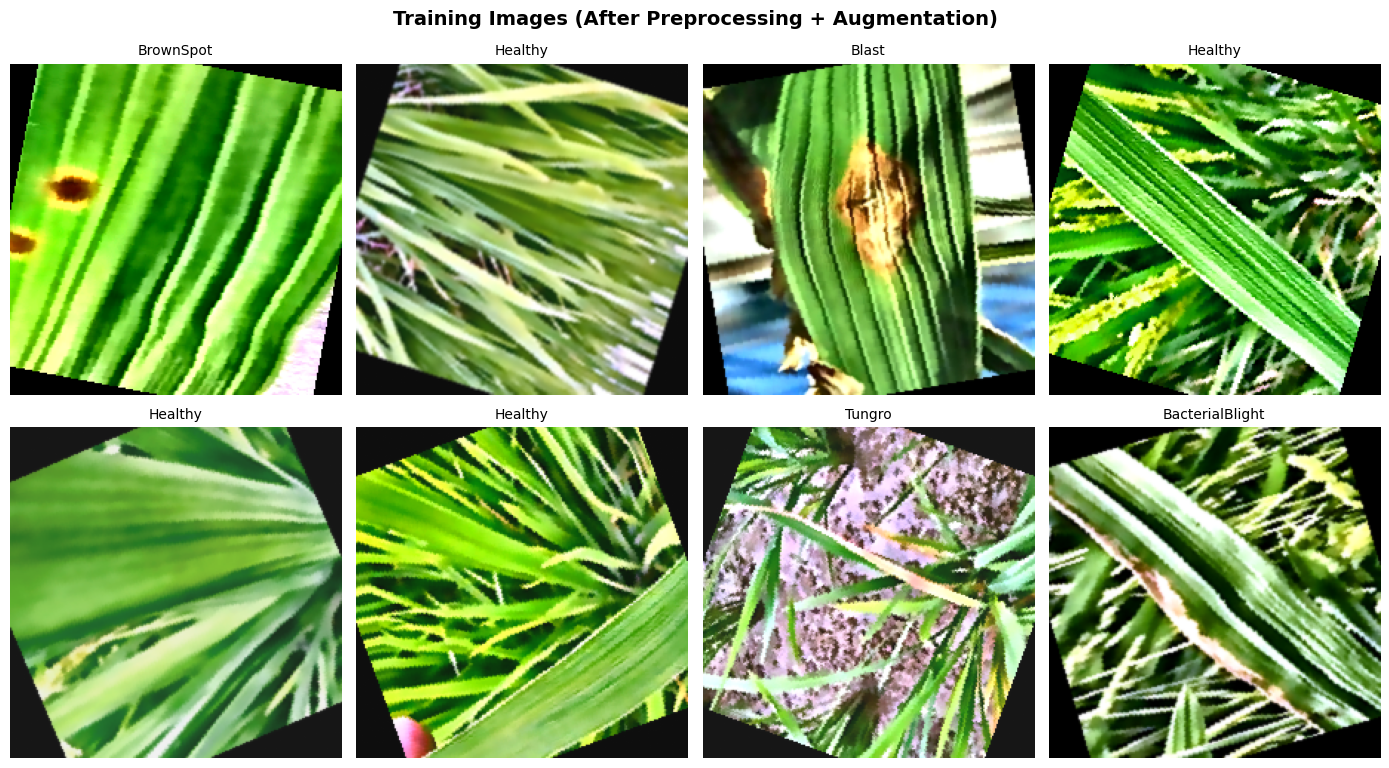

In [ ]:
# ==========================================================
# Visualize Training Batch
# ==========================================================

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2,4, figsize=(14,8))

axes = axes.flatten()

for i in range(8):

    img = denormalize(images[i])

    axes[i].imshow(img)

    axes[i].set_title(
        train_dataset.classes[labels[i]],
        fontsize=10
    )

    axes[i].axis("off")

plt.suptitle(
    "Training Images (After Preprocessing + Augmentation)",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

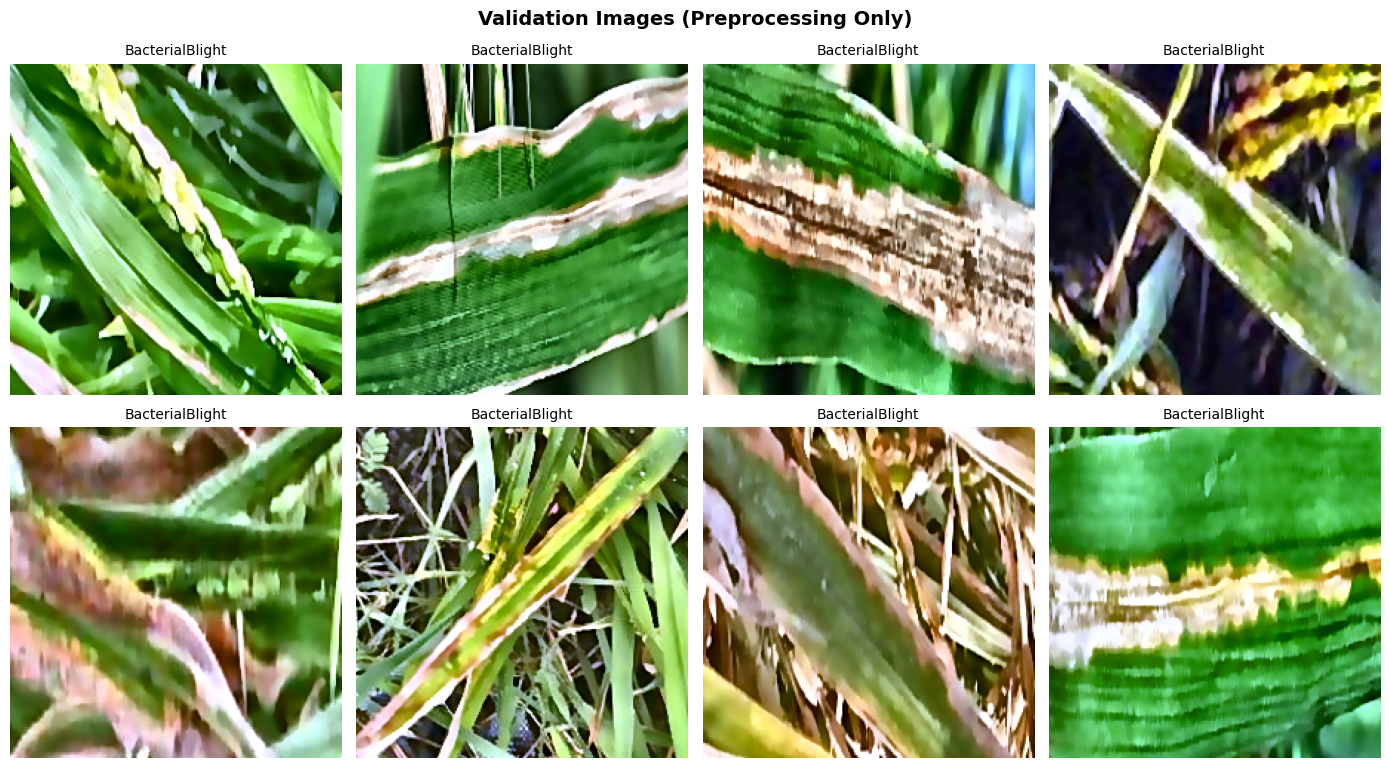

In [ ]:
# ==========================================================
# Visualize Validation Batch
# ==========================================================

images, labels = next(iter(val_loader))

fig, axes = plt.subplots(2,4, figsize=(14,8))

axes = axes.flatten()

for i in range(8):

    img = denormalize(images[i])

    axes[i].imshow(img)

    axes[i].set_title(
        val_dataset.classes[labels[i]],
        fontsize=10
    )

    axes[i].axis("off")

plt.suptitle(
    "Validation Images (Preprocessing Only)",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [ ]:
# ==========================================================
# Final Pipeline Check
# ==========================================================

images, labels = next(iter(train_loader))

print("=" * 45)
print("DataLoader Verification")
print("=" * 45)

print(f"Image Batch Shape : {images.shape}")
print(f"Label Shape       : {labels.shape}")
print(f"Image Data Type   : {images.dtype}")
print(f"Label Data Type   : {labels.dtype}")
print(f"Device            : {images.device}")
print(f"Pixel Range       : {images.min():.3f} ~ {images.max():.3f}")

DataLoader Verification
Image Batch Shape : torch.Size([32, 3, 224, 224])
Label Shape       : torch.Size([32])
Image Data Type   : torch.float32
Label Data Type   : torch.int64
Device            : cpu
Pixel Range       : -2.118 ~ 2.640


## 9. MobileNetV3-Large Model

This section loads the pretrained MobileNetV3-Large architecture,
modifies the classifier for rice leaf disease classification,
and prepares the model for transfer learning.

In [ ]:
# ==========================================================
# Load MobileNetV3-Large
# ==========================================================

from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights

weights = MobileNet_V3_Large_Weights.DEFAULT
model   = mobilenet_v3_large(weights=weights)

print("Pretrained MobileNetV3-Large loaded.")

Pretrained MobileNetV3-Large loaded.


In [ ]:
# ==========================================================
# Replace Classifier (Baseline)
# ==========================================================

in_features = model.classifier[3].in_features

model.classifier[3] = nn.Linear(
    in_features,
    NUM_CLASSES
)

print("\nUpdated Classifier:")
print(model.classifier)


Updated Classifier:
Sequential(
  (0): Linear(in_features=960, out_features=1280, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1280, out_features=5, bias=True)
)


In [ ]:
# ==========================================================
# Phase A — Freeze backbone, train head only
# ==========================================================

for param in model.features.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

In [ ]:
# ==========================================================
# Model Statistics
# ==========================================================

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 50)
print(f"Total Parameters      : {total_params:,}")
print(f"Trainable Parameters  : {trainable_params:,}")
print(f"Model Size (fp32)     : {total_params * 4 / 1024 / 1024:.2f} MB")
print("=" * 50)

Total Parameters      : 4,208,437
Trainable Parameters  : 1,236,485
Model Size (fp32)     : 16.05 MB


In [ ]:
# ==========================================================
# Loss, Optimizer, Scheduler
# ==========================================================

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode    = "min",
    factor  = 0.5,
    patience= 5,
    min_lr  = 1e-6
)

print("Loss      : CrossEntropyLoss (label_smoothing=0.1)")
print("Optimizer : AdamW")
print("Scheduler : ReduceLROnPlateau")

Loss      : CrossEntropyLoss (label_smoothing=0.1)
Optimizer : AdamW
Scheduler : ReduceLROnPlateau


In [ ]:
# ==========================================================
# Move to Device + Forward Pass Verification
# ==========================================================

model = model.to(DEVICE)

model.eval()
with torch.no_grad():
    images, labels = next(iter(train_loader))
    images, labels = images.to(DEVICE), labels.to(DEVICE)
    outputs        = model(images)
    loss           = criterion(outputs, labels)
    _, preds       = torch.max(outputs, dim=1)

print("=" * 50)
print("Forward Pass Verification")
print("=" * 50)
print(f"Input Shape        : {images.shape}")
print(f"Output Shape       : {outputs.shape}")
print(f"Loss               : {loss.item():.4f}")
print(f"Unique Predictions : {torch.unique(preds)}")
print("=" * 50)

Forward Pass Verification
Input Shape        : torch.Size([32, 3, 224, 224])
Output Shape       : torch.Size([32, 5])
Loss               : 1.6300
Unique Predictions : tensor([0, 1, 2, 3, 4], device='cuda:0')


# **Models**

Training MobileNetV3-Large — Baseline
Phase A : Epochs 1–10  (backbone frozen,  LR=0.0001)
Phase B : Epochs 11–30  (last 4 blocks unfrozen, LR=1e-05)

Epoch   Phase   Tr Loss   Tr Acc   Va Loss   Va Acc        LR   Time
──────────────────────────────────────────────────────────────────────
    1       A    1.1304   71.27%    0.9055   77.80%  1.00e-04   142s
    2       A    0.7576   86.39%    0.6754   89.50%  1.00e-04   133s
    3       A    0.6612   89.99%    0.6068   92.60%  1.00e-04   136s
    4       A    0.6186   92.51%    0.5786   93.56%  1.00e-04   138s
    5       A    0.5987   92.90%    0.5489   96.42%  1.00e-04   136s
    6       A    0.5745   94.41%    0.5390   97.37%  1.00e-04   136s
    7       A    0.5684   95.01%    0.5254   97.37%  1.00e-04   142s
    8       A    0.5521   95.78%    0.5198   97.61%  1.00e-04   140s
    9       A    0.5511   95.60%    0.5131   97.85%  1.00e-04   144s
   10       A    0.5437   95.99%    0.5119   97.85%  1.00e-04   144s

──────────────────

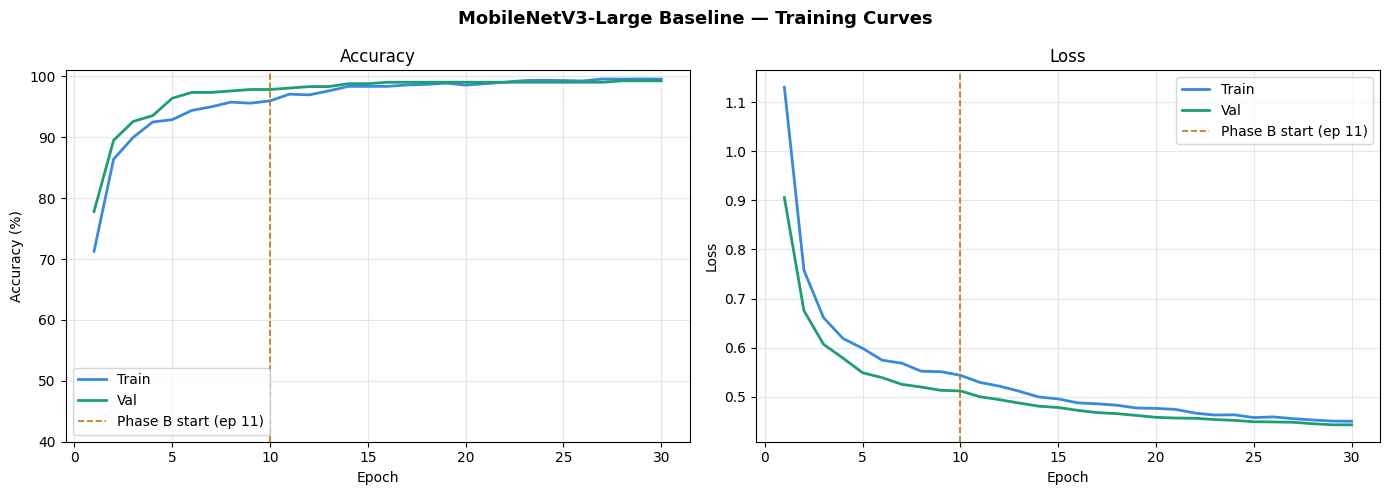

Training curves saved.

Loading best model for test set evaluation...

Test Loss     : 0.4407
Test Accuracy : 99.76%

Classification Report
                 precision    recall  f1-score   support

BacterialBlight     1.0000    0.9880    0.9939        83
          Blast     1.0000    1.0000    1.0000        79
      BrownSpot     1.0000    1.0000    1.0000        67
        Healthy     0.9899    1.0000    0.9949        98
         Tungro     1.0000    1.0000    1.0000        98

       accuracy                         0.9976       425
      macro avg     0.9980    0.9976    0.9978       425
   weighted avg     0.9977    0.9976    0.9976       425



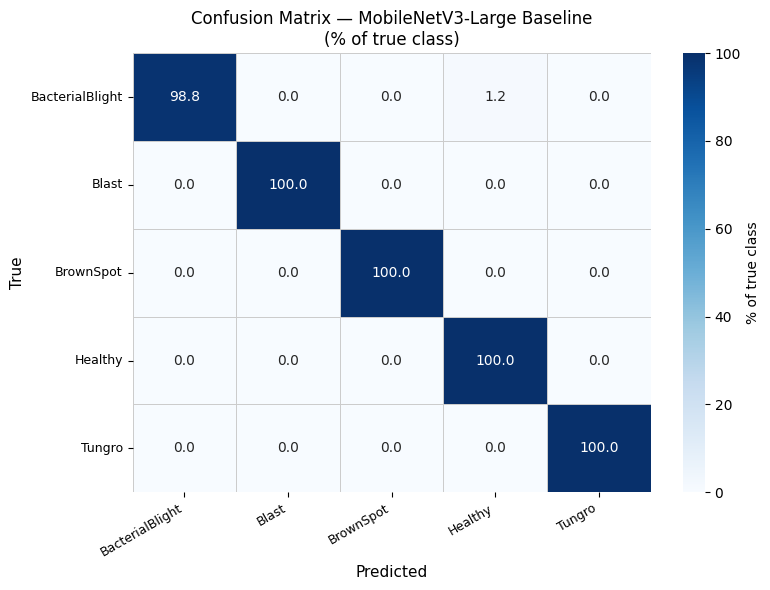

Confusion matrix saved.

Model Summary — MobileNetV3-Large Baseline
Total Parameters  : 4,208,437
Model Size (fp32) : 16.05 MB
Best Val Accuracy : 99.28%
Test Accuracy     : 99.76%

All outputs saved to: /content/drive/MyDrive/Results/MobileNetV3_Large_Baseline Clean/
  best_model.pth
  last_model.pth
  training_history.json
  training_curves.png
  confusion_matrix.png
  classification_report.txt
  model_info.json


In [ ]:
# ==========================================================
# 10. Training Loop — MobileNetV3-Large (Baseline)
# ==========================================================
#
# Two-phase training strategy:
#
#   Phase A (Epochs 1–10)
#     Backbone frozen — only classifier trains
#     LR = LEARNING_RATE (1e-3)
#     Goal: fast convergence of new classifier layers
#
#   Phase B (Epochs 11–30)
#     Last 4 backbone blocks unfrozen — fine-tuning
#     LR reset to 1e-5 (careful, low LR for pretrained weights)
#     Goal: adapt deep features to rice disease domain
#
# Outputs saved:
#   best_model.pth          ← highest val accuracy checkpoint
#   last_model.pth          ← final epoch checkpoint
#   training_history.json   ← epoch-by-epoch metrics
# ==========================================================

import copy
import json

# ==========================================================
# Configuration
# ==========================================================

PHASE_A_EPOCHS = 10
PHASE_B_EPOCHS = 20
TOTAL_EPOCHS   = PHASE_A_EPOCHS + PHASE_B_EPOCHS   # 30

LR_PHASE_B     = 1e-5     # fine-tuning LR for Phase B

OUTPUT_DIR     = "/content/drive/MyDrive/Results/MobileNetV3_Large_Baseline Clean"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ==========================================================
# Helper Functions
# ==========================================================

def train_one_epoch(model, loader, criterion, optimizer):
    """Run one training epoch. Returns avg loss and accuracy."""
    model.train()

    running_loss = 0.0
    correct      = 0
    total        = 0

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)
        loss    = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds      = torch.max(outputs, 1)
        correct      += (preds == labels).sum().item()
        total        += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = 100.0 * correct / total

    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion):
    """Evaluate model on val or test loader. Returns loss, acc, preds, labels."""
    model.eval()

    running_loss = 0.0
    correct      = 0
    total        = 0
    all_preds    = []
    all_labels   = []

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        loss    = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, preds      = torch.max(outputs, 1)
        correct      += (preds == labels).sum().item()
        total        += images.size(0)

        all_preds .extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

    epoch_loss = running_loss / total
    epoch_acc  = 100.0 * correct / total

    return epoch_loss, epoch_acc, all_preds, all_labels


def unfreeze_last_n_blocks(model, n=4):
    """
    Unfreeze last n blocks of model.features for Phase B fine-tuning.
    MobileNetV3-Large has 17 feature blocks (index 0-16).
    Unfreezing last 4 = blocks 13-16 (deepest, most task-specific).
    """
    # First freeze everything
    for param in model.features.parameters():
        param.requires_grad = False

    # Then unfreeze last n blocks
    blocks = list(model.features.children())
    for block in blocks[-n:]:
        for param in block.parameters():
            param.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Unfroze last {n} backbone blocks")
    print(f"  Trainable parameters: {trainable:,}")


# ==========================================================
# Training Loop
# ==========================================================

history  = []
best_acc = 0.0
best_wts = copy.deepcopy(model.state_dict())

print("=" * 70)
print("Training MobileNetV3-Large — Baseline")
print("=" * 70)
print(f"Phase A : Epochs 1–{PHASE_A_EPOCHS}  (backbone frozen,  LR={LEARNING_RATE})")
print(f"Phase B : Epochs {PHASE_A_EPOCHS+1}–{TOTAL_EPOCHS}  (last 4 blocks unfrozen, LR={LR_PHASE_B})")
print("=" * 70)
print(f"\n{'Epoch':>5} {'Phase':>7} {'Tr Loss':>9} {'Tr Acc':>8} "
      f"{'Va Loss':>9} {'Va Acc':>8} {'LR':>9} {'Time':>6}")
print("─" * 70)

for epoch in range(1, TOTAL_EPOCHS + 1):

    t0 = time.time()

    # ── Phase switch at epoch 11 ──────────────────────────
    if epoch == PHASE_A_EPOCHS + 1:
        print(f"\n{'─'*70}")
        print(f"  Switching to Phase B — fine-tuning")
        unfreeze_last_n_blocks(model, n=4)

        # Reinitialise optimizer with lower LR for fine-tuning
        optimizer = optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr          = LR_PHASE_B,
            weight_decay= WEIGHT_DECAY
        )

        # Reset scheduler for Phase B
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode    = "min",
            factor  = 0.5,
            patience= 5,
            min_lr  = 1e-7
        )
        print(f"{'─'*70}\n")

    phase = "A" if epoch <= PHASE_A_EPOCHS else "B"

    # ── Train ─────────────────────────────────────────────
    tr_loss, tr_acc = train_one_epoch(
        model, train_loader, criterion, optimizer
    )

    # ── Validate ──────────────────────────────────────────
    va_loss, va_acc, _, _ = evaluate(
        model, val_loader, criterion
    )

    # ── Scheduler step ────────────────────────────────────
    # ReduceLROnPlateau uses val loss
    scheduler.step(va_loss)

    # ── Log ───────────────────────────────────────────────
    elapsed    = time.time() - t0
    current_lr = optimizer.param_groups[0]['lr']

    print(f"{epoch:>5} {phase:>7} {tr_loss:>9.4f} {tr_acc:>7.2f}% "
          f"{va_loss:>9.4f} {va_acc:>7.2f}% "
          f"{current_lr:>9.2e} {elapsed:>5.0f}s")

    history.append({
        "epoch"     : epoch,
        "phase"     : phase,
        "train_loss": round(tr_loss, 6),
        "train_acc" : round(tr_acc, 4),
        "val_loss"  : round(va_loss, 6),
        "val_acc"   : round(va_acc, 4),
        "lr"        : current_lr,
    })

    # ── Save best model ───────────────────────────────────
    if va_acc > best_acc:
        best_acc = va_acc
        best_wts = copy.deepcopy(model.state_dict())
        torch.save(
            best_wts,
            os.path.join(OUTPUT_DIR, "best_model.pth")
        )

# Save last checkpoint
torch.save(
    model.state_dict(),
    os.path.join(OUTPUT_DIR, "last_model.pth")
)

# Save history
with open(os.path.join(OUTPUT_DIR, "training_history.json"), "w") as f:
    json.dump(history, f, indent=2)

print("\n" + "=" * 70)
print(f"Training complete.")
print(f"Best Val Accuracy : {best_acc:.2f}%")
print(f"Saved to          : {OUTPUT_DIR}")
print("=" * 70)


# ==========================================================
# 11. Training Curves
# ==========================================================

epochs  = [h["epoch"]      for h in history]
tr_acc  = [h["train_acc"]  for h in history]
va_acc  = [h["val_acc"]    for h in history]
tr_loss = [h["train_loss"] for h in history]
va_loss = [h["val_loss"]   for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "MobileNetV3-Large Baseline — Training Curves",
    fontsize=13, fontweight='bold'
)

# Accuracy
ax1.plot(epochs, tr_acc,  label="Train", color="#378ADD", linewidth=2)
ax1.plot(epochs, va_acc,  label="Val",   color="#1D9E75", linewidth=2)
ax1.axvline(
    PHASE_A_EPOCHS,
    color="#BA7517", linestyle="--", linewidth=1.2,
    label=f"Phase B start (ep {PHASE_A_EPOCHS+1})"
)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy (%)")
ax1.set_title("Accuracy")
ax1.legend()
ax1.grid(alpha=0.3)
ax1.set_ylim([40, 101])

# Loss
ax2.plot(epochs, tr_loss, label="Train", color="#378ADD", linewidth=2)
ax2.plot(epochs, va_loss, label="Val",   color="#1D9E75", linewidth=2)
ax2.axvline(
    PHASE_A_EPOCHS,
    color="#BA7517", linestyle="--", linewidth=1.2,
    label=f"Phase B start (ep {PHASE_A_EPOCHS+1})"
)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.set_title("Loss")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "training_curves.png"),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Training curves saved.")


# ==========================================================
# 12. Final Evaluation on Test Set
# ==========================================================

print("\nLoading best model for test set evaluation...")
model.load_state_dict(best_wts)

test_loss, test_acc, test_preds, test_labels = evaluate(
    model, test_loader, criterion
)

print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.2f}%")

# Classification report
print("\n" + "=" * 60)
print("Classification Report")
print("=" * 60)

classes = train_dataset.classes

report = classification_report(
    test_labels,
    test_preds,
    target_names=classes,
    digits=4
)
print(report)

# Save report
with open(os.path.join(OUTPUT_DIR, "classification_report.txt"), "w") as f:
    f.write("MobileNetV3-Large Baseline — Classification Report\n")
    f.write("=" * 60 + "\n")
    f.write(report)


# ==========================================================
# 13. Confusion Matrix
# ==========================================================

cm     = confusion_matrix(test_labels, test_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm_pct,
    annot         = True,
    fmt           = ".1f",
    cmap          = "Blues",
    xticklabels   = classes,
    yticklabels   = classes,
    ax            = ax,
    linewidths    = 0.5,
    linecolor     = '#ccc',
    cbar_kws      = {"label": "% of true class"}
)
ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("True",      fontsize=11)
ax.set_title(
    "Confusion Matrix — MobileNetV3-Large Baseline\n(% of true class)",
    fontsize=12
)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(rotation=0,  fontsize=9)
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "confusion_matrix.png"),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Confusion matrix saved.")


# ==========================================================
# 14. Model Info Summary
# ==========================================================

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\n" + "=" * 50)
print("Model Summary — MobileNetV3-Large Baseline")
print("=" * 50)
print(f"Total Parameters  : {total_params:,}")
print(f"Model Size (fp32) : {total_params * 4 / 1024 / 1024:.2f} MB")
print(f"Best Val Accuracy : {best_acc:.2f}%")
print(f"Test Accuracy     : {test_acc:.2f}%")
print("=" * 50)

# Save model info
model_info = {
    "model"          : "MobileNetV3-Large Baseline",
    "total_params"   : total_params,
    "size_mb_fp32"   : round(total_params * 4 / 1024 / 1024, 2),
    "num_classes"    : NUM_CLASSES,
    "classes"        : classes,
    "best_val_acc"   : round(best_acc, 4),
    "test_acc"       : round(test_acc, 4),
    "phase_a_epochs" : PHASE_A_EPOCHS,
    "phase_b_epochs" : PHASE_B_EPOCHS,
    "lr_phase_a"     : LEARNING_RATE,
    "lr_phase_b"     : LR_PHASE_B,
    "batch_size"     : BATCH_SIZE,
    "optimizer"      : "AdamW",
    "scheduler"      : "ReduceLROnPlateau",
    "label_smoothing": 0.1,
}

with open(os.path.join(OUTPUT_DIR, "model_info.json"), "w") as f:
    json.dump(model_info, f, indent=2)

print(f"\nAll outputs saved to: {OUTPUT_DIR}/")
print("  best_model.pth")
print("  last_model.pth")
print("  training_history.json")
print("  training_curves.png")
print("  confusion_matrix.png")
print("  classification_report.txt")
print("  model_info.json")

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import mobilenet_v3_large

# ==========================================================
# Build Baseline Model
# ==========================================================

model = mobilenet_v3_large(weights=None)

in_features = model.classifier[3].in_features
model.classifier[3] = nn.Linear(
    in_features,
    NUM_CLASSES
)

# ==========================================================
# Load Saved Weights
# ==========================================================

MODEL_PATH = "/content/drive/MyDrive/Results/MobileNetV3_Large_Baseline Clean/best_model.pth"

state_dict = torch.load(MODEL_PATH, map_location=DEVICE)

model.load_state_dict(state_dict)

model = model.to(DEVICE)
model.eval()

print("Baseline model loaded successfully.")

Baseline model loaded successfully.


In [ ]:
# ==========================================================
# MobileNetV3-Large Baseline
# ==========================================================

!pip install -q thop

import time
import torch
from thop import profile

model.eval()

dummy = torch.randn(1, 3, 224, 224).to(DEVICE)

# ==========================================================
# Parameter Count
# ==========================================================

total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

# ==========================================================
# FLOPs / MACs
# ==========================================================

macs, params = profile(
    model,
    inputs=(dummy,),
    verbose=False
)

# ==========================================================
# Peak GPU Memory
# ==========================================================

torch.cuda.empty_cache()
torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()

with torch.no_grad():
    _ = model(dummy)

torch.cuda.synchronize()

peak_memory = torch.cuda.max_memory_allocated() / (1024 ** 2)

# ==========================================================
# Inference Time
# ==========================================================

for _ in range(10):
    with torch.no_grad():
        _ = model(dummy)

torch.cuda.synchronize()

start = time.time()

for _ in range(100):
    with torch.no_grad():
        _ = model(dummy)

torch.cuda.synchronize()

end = time.time()

avg_time_ms = ((end - start) / 100) * 1000

fps = 1000 / avg_time_ms

# ==========================================================
# Model Depth
# ==========================================================

depth = sum(
    1
    for module in model.modules()
    if len(list(module.children())) == 0
)

# ==========================================================
# Model Size
# ==========================================================

model_size = total_params * 4 / (1024 ** 2)

# ==========================================================
# Results
# ==========================================================

print("=" * 65)
print("MobileNetV3-Large Baseline")
print("=" * 65)

print(f"Total Parameters      : {total_params:,}")
print(f"Trainable Parameters  : {trainable_params:,}")

print("-" * 65)

print(f"MACs                  : {macs/1e6:.2f} M")
print(f"FLOPs                 : {(2*macs)/1e6:.2f} M")

print("-" * 65)

print(f"Peak GPU Memory       : {peak_memory:.2f} MB")
print(f"Average Inference     : {avg_time_ms:.2f} ms/image")
print(f"Images Per Second     : {fps:.2f} FPS")

print("-" * 65)

print(f"Model Depth           : {depth}")
print(f"Model Size            : {model_size:.2f} MB")

print("=" * 65)

MobileNetV3-Large Baseline
Total Parameters      : 4,208,437
Trainable Parameters  : 4,208,437
-----------------------------------------------------------------
MACs                  : 233.56 M
FLOPs                 : 467.13 M
-----------------------------------------------------------------
Peak GPU Memory       : 154.40 MB
Average Inference     : 8.09 ms/image
Images Per Second     : 123.65 FPS
-----------------------------------------------------------------
Model Depth           : 168
Model Size            : 16.05 MB


In [ ]:
starter = torch.cuda.Event(enable_timing=True)
ender = torch.cuda.Event(enable_timing=True)

# Warm-up
for _ in range(20):
    with torch.no_grad():
        _ = model(dummy)

torch.cuda.synchronize()

times = []

for _ in range(100):
    starter.record()

    with torch.no_grad():
        _ = model(dummy)

    ender.record()
    torch.cuda.synchronize()

    times.append(starter.elapsed_time(ender))

avg_time = sum(times) / len(times)

Training — MobileNetV2
Phase A : Epochs 1–10  (backbone frozen, classifier trains, LR=0.0001)
Phase B : Epochs 11–30  (last 4 blocks unfrozen, LR=1e-05)

Epoch   Phase   Tr Loss   Tr Acc   Va Loss   Va Acc        LR   Time
──────────────────────────────────────────────────────────────────────
    1       A    1.5246   40.23%    1.4409   62.05%  1.00e-04   516s
    2       A    1.3458   67.86%    1.2862   75.66%  1.00e-04   388s
    3       A    1.2086   75.13%    1.1747   78.28%  1.00e-04   395s
    4       A    1.1112   78.46%    1.0817   80.67%  1.00e-04   391s
    5       A    1.0244   81.70%    1.0225   81.62%  1.00e-04   397s
    6       A    0.9810   81.25%    0.9717   82.82%  1.00e-04   389s
    7       A    0.9322   82.92%    0.9289   83.77%  1.00e-04   399s
    8       A    0.8986   83.01%    0.8959   84.73%  1.00e-04   391s
    9       A    0.8735   83.42%    0.8629   84.73%  1.00e-04   392s
   10       A    0.8365   84.82%    0.8516   84.01%  1.00e-04   387s

───────────────

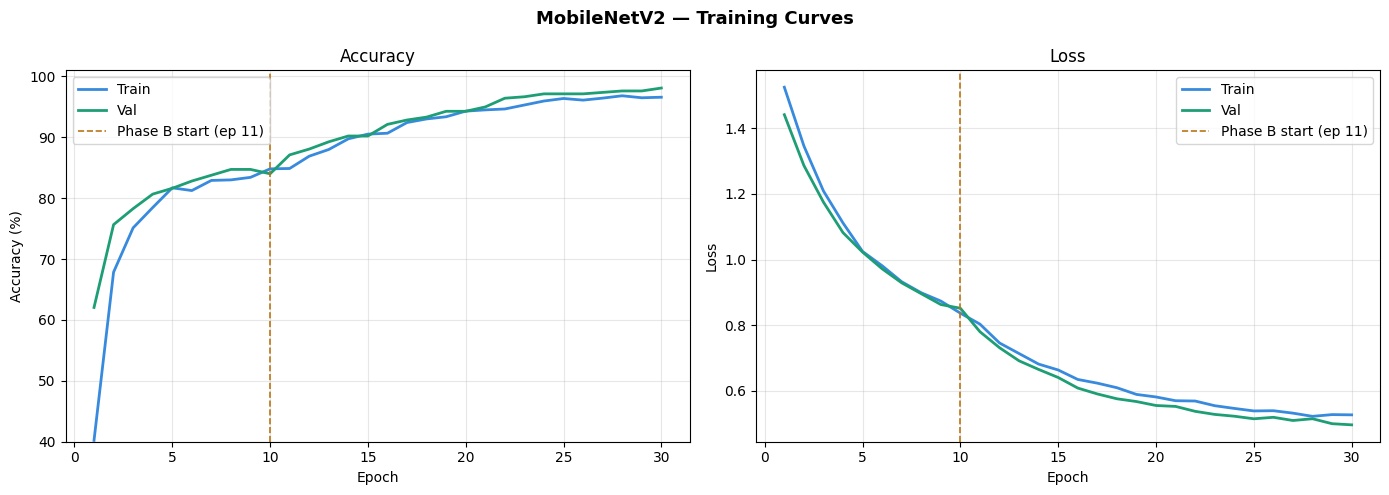

Training curves saved.

Loading best model for test set evaluation...

Test Loss     : 0.4961
Test Accuracy : 98.59%

Classification Report — MobileNetV2
                 precision    recall  f1-score   support

BacterialBlight     0.9880    0.9880    0.9880        83
          Blast     0.9872    0.9747    0.9809        79
      BrownSpot     0.9710    1.0000    0.9853        67
        Healthy     0.9897    0.9796    0.9846        98
         Tungro     0.9898    0.9898    0.9898        98

       accuracy                         0.9859       425
      macro avg     0.9851    0.9864    0.9857       425
   weighted avg     0.9860    0.9859    0.9859       425



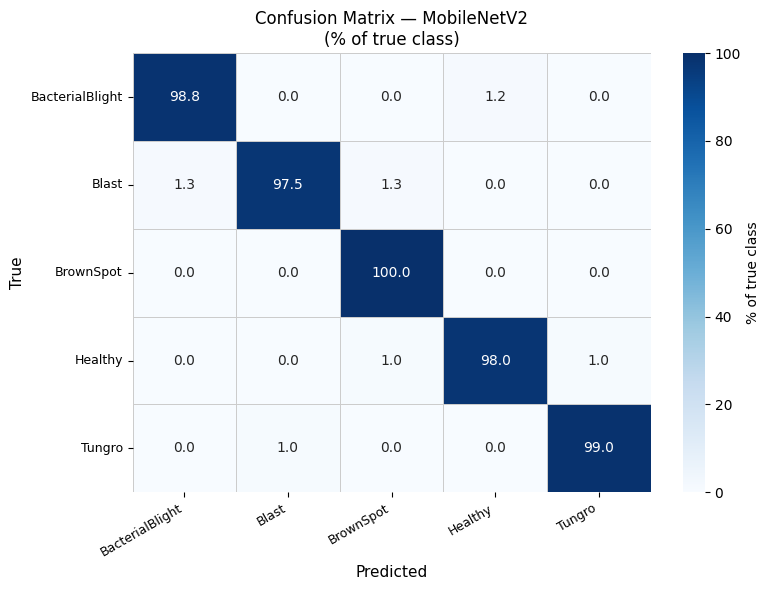

Confusion matrix saved.

Model Summary — MobileNetV2
Total Parameters  : 2,230,277
Model Size (fp32) : 8.51 MB
Best Val Accuracy : 98.09%
Test Accuracy     : 98.59%

All outputs saved to: /content/drive/MyDrive/Results/MobileNetV2/
  best_model.pth
  last_model.pth
  training_history.json
  training_curves.png
  confusion_matrix.png
  classification_report.txt
  model_info.json


In [ ]:
# ==========================================================
# Experiment 2 — Training Loop
# MobileNetV2
# ==========================================================

import copy
import json

# ==========================================================
# Configuration
# ==========================================================

PHASE_A_EPOCHS = 10
PHASE_B_EPOCHS = 20
TOTAL_EPOCHS   = PHASE_A_EPOCHS + PHASE_B_EPOCHS

LR_PHASE_B     = 1e-5

OUTPUT_DIR_V2  = "/content/drive/MyDrive/Results/MobileNetV2"
os.makedirs(OUTPUT_DIR_V2, exist_ok=True)


def unfreeze_last_n_blocks_v2(model, n=4):
    """
    Unfreeze last n blocks of MobileNetV2 features for Phase B.
    MobileNetV2 has 19 feature blocks (index 0-18).
    Unfreezing last 4 = blocks 15-18 (deepest features).
    """
    for param in model.features.parameters():
        param.requires_grad = False

    blocks = list(model.features.children())
    for block in blocks[-n:]:
        for param in block.parameters():
            param.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters()
                    if p.requires_grad)
    print(f"  Unfroze last {n} backbone blocks")
    print(f"  Trainable parameters: {trainable:,}")


# ==========================================================
# Training Loop
# ==========================================================

history_v2  = []
best_acc_v2 = 0.0
best_wts_v2 = copy.deepcopy(model_v2.state_dict())

print("=" * 70)
print("Training — MobileNetV2")
print("=" * 70)
print(f"Phase A : Epochs 1–{PHASE_A_EPOCHS}  "
      f"(backbone frozen, classifier trains, LR={LEARNING_RATE})")
print(f"Phase B : Epochs {PHASE_A_EPOCHS+1}–{TOTAL_EPOCHS}  "
      f"(last 4 blocks unfrozen, LR={LR_PHASE_B})")
print("=" * 70)
print(f"\n{'Epoch':>5} {'Phase':>7} {'Tr Loss':>9} {'Tr Acc':>8} "
      f"{'Va Loss':>9} {'Va Acc':>8} {'LR':>9} {'Time':>6}")
print("─" * 70)

for epoch in range(1, TOTAL_EPOCHS + 1):

    t0 = time.time()

    # ── Phase B switch ────────────────────────────────────
    if epoch == PHASE_A_EPOCHS + 1:
        print(f"\n{'─'*70}")
        print(f"  Switching to Phase B — fine-tuning")
        unfreeze_last_n_blocks_v2(model_v2, n=4)

        optimizer_v2 = optim.AdamW(
            filter(lambda p: p.requires_grad, model_v2.parameters()),
            lr           = LR_PHASE_B,
            weight_decay = WEIGHT_DECAY
        )
        scheduler_v2 = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer_v2,
            mode    = "min",
            factor  = 0.5,
            patience= 5,
            min_lr  = 1e-7
        )
        print(f"{'─'*70}\n")

    phase = "A" if epoch <= PHASE_A_EPOCHS else "B"

    # ── Train ─────────────────────────────────────────────
    tr_loss, tr_acc = train_one_epoch(
        model_v2, train_loader, criterion_v2, optimizer_v2
    )

    # ── Validate ──────────────────────────────────────────
    va_loss, va_acc, _, _ = evaluate(
        model_v2, val_loader, criterion_v2
    )

    # ── Scheduler ─────────────────────────────────────────
    scheduler_v2.step(va_loss)

    # ── Log ───────────────────────────────────────────────
    elapsed    = time.time() - t0
    current_lr = optimizer_v2.param_groups[0]['lr']

    print(f"{epoch:>5} {phase:>7} {tr_loss:>9.4f} {tr_acc:>7.2f}% "
          f"{va_loss:>9.4f} {va_acc:>7.2f}% "
          f"{current_lr:>9.2e} {elapsed:>5.0f}s")

    history_v2.append({
        "epoch"     : epoch,
        "phase"     : phase,
        "train_loss": round(tr_loss, 6),
        "train_acc" : round(tr_acc, 4),
        "val_loss"  : round(va_loss, 6),
        "val_acc"   : round(va_acc, 4),
        "lr"        : current_lr,
    })

    if va_acc > best_acc_v2:
        best_acc_v2 = va_acc
        best_wts_v2 = copy.deepcopy(model_v2.state_dict())
        torch.save(
            best_wts_v2,
            os.path.join(OUTPUT_DIR_V2, "best_model.pth")
        )

torch.save(
    model_v2.state_dict(),
    os.path.join(OUTPUT_DIR_V2, "last_model.pth")
)
with open(os.path.join(OUTPUT_DIR_V2, "training_history.json"), "w") as f:
    json.dump(history_v2, f, indent=2)

print("\n" + "=" * 70)
print(f"Training complete.")
print(f"Best Val Accuracy : {best_acc_v2:.2f}%")
print(f"Saved to          : {OUTPUT_DIR_V2}")
print("=" * 70)


# ==========================================================
# Training Curves
# ==========================================================

epochs  = [h["epoch"]      for h in history_v2]
tr_acc  = [h["train_acc"]  for h in history_v2]
va_acc  = [h["val_acc"]    for h in history_v2]
tr_loss = [h["train_loss"] for h in history_v2]
va_loss = [h["val_loss"]   for h in history_v2]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("MobileNetV2 — Training Curves", fontsize=13, fontweight='bold')

ax1.plot(epochs, tr_acc,  label="Train", color="#378ADD", linewidth=2)
ax1.plot(epochs, va_acc,  label="Val",   color="#1D9E75", linewidth=2)
ax1.axvline(PHASE_A_EPOCHS, color="#BA7517", linestyle="--",
            linewidth=1.2, label=f"Phase B start (ep {PHASE_A_EPOCHS+1})")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy (%)")
ax1.set_title("Accuracy"); ax1.legend(); ax1.grid(alpha=0.3)
ax1.set_ylim([40, 101])

ax2.plot(epochs, tr_loss, label="Train", color="#378ADD", linewidth=2)
ax2.plot(epochs, va_loss, label="Val",   color="#1D9E75", linewidth=2)
ax2.axvline(PHASE_A_EPOCHS, color="#BA7517", linestyle="--",
            linewidth=1.2, label=f"Phase B start (ep {PHASE_A_EPOCHS+1})")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
ax2.set_title("Loss"); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_V2, "training_curves.png"),
            dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved.")


# ==========================================================
# Final Evaluation on Test Set
# ==========================================================

print("\nLoading best model for test set evaluation...")
model_v2.load_state_dict(best_wts_v2)

test_loss_v2, test_acc_v2, test_preds_v2, test_labels_v2 = evaluate(
    model_v2, test_loader, criterion_v2
)

print(f"\nTest Loss     : {test_loss_v2:.4f}")
print(f"Test Accuracy : {test_acc_v2:.2f}%")

classes = train_dataset.classes

report_v2 = classification_report(
    test_labels_v2,
    test_preds_v2,
    target_names = classes,
    digits       = 4
)

print("\n" + "=" * 60)
print("Classification Report — MobileNetV2")
print("=" * 60)
print(report_v2)

with open(os.path.join(OUTPUT_DIR_V2, "classification_report.txt"), "w") as f:
    f.write("MobileNetV2 — Classification Report\n")
    f.write("=" * 60 + "\n")
    f.write(report_v2)


# ==========================================================
# Confusion Matrix
# ==========================================================

cm     = confusion_matrix(test_labels_v2, test_preds_v2)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm_pct, annot=True, fmt=".1f", cmap="Blues",
    xticklabels=classes, yticklabels=classes,
    ax=ax, linewidths=0.5, linecolor='#ccc',
    cbar_kws={"label": "% of true class"}
)
ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("True",      fontsize=11)
ax.set_title("Confusion Matrix — MobileNetV2\n(% of true class)", fontsize=12)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(rotation=0,  fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_V2, "confusion_matrix.png"),
            dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved.")


# ==========================================================
# Model Summary
# ==========================================================

total_params_v2 = sum(p.numel() for p in model_v2.parameters())

print("\n" + "=" * 50)
print("Model Summary — MobileNetV2")
print("=" * 50)
print(f"Total Parameters  : {total_params_v2:,}")
print(f"Model Size (fp32) : {total_params_v2 * 4 / 1024 / 1024:.2f} MB")
print(f"Best Val Accuracy : {best_acc_v2:.2f}%")
print(f"Test Accuracy     : {test_acc_v2:.2f}%")
print("=" * 50)

model_info_v2 = {
    "model"          : "MobileNetV2",
    "total_params"   : total_params_v2,
    "size_mb_fp32"   : round(total_params_v2 * 4 / 1024 / 1024, 2),
    "num_classes"    : NUM_CLASSES,
    "classes"        : classes,
    "best_val_acc"   : round(best_acc_v2, 4),
    "test_acc"       : round(test_acc_v2, 4),
    "phase_a_epochs" : PHASE_A_EPOCHS,
    "phase_b_epochs" : PHASE_B_EPOCHS,
    "lr_phase_a"     : LEARNING_RATE,
    "lr_phase_b"     : LR_PHASE_B,
    "batch_size"     : BATCH_SIZE,
    "optimizer"      : "AdamW",
    "scheduler"      : "ReduceLROnPlateau",
    "label_smoothing": 0.1,
}

with open(os.path.join(OUTPUT_DIR_V2, "model_info.json"), "w") as f:
    json.dump(model_info_v2, f, indent=2)

print(f"\nAll outputs saved to: {OUTPUT_DIR_V2}/")
print("  best_model.pth")
print("  last_model.pth")
print("  training_history.json")
print("  training_curves.png")
print("  confusion_matrix.png")
print("  classification_report.txt")
print("  model_info.json")

In [ ]:
# ==========================================================
# Experiment 2 — MobileNetV2
# ==========================================================
#
# MobileNetV2 is included as a comparison point against
# MobileNetV3-Large baseline (Exp 1) to show architectural
# progression within the MobileNet family.
#
# Architecture differences vs MobileNetV3-Large:
#   - Uses ReLU6 instead of Hard-Swish activation
#   - No squeeze-excitation in bottleneck blocks
#   - Simpler inverted residual structure
#   - Smaller model — fewer parameters
#
# Training strategy: identical to Exp 1 for fair comparison
#   Phase A (Epochs 1–10) : backbone frozen, classifier trains
#   Phase B (Epochs 11–30): last 4 backbone layers unfrozen
# ==========================================================


# ==========================================================
# Load MobileNetV2
# ==========================================================

from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

weights_v2 = MobileNet_V2_Weights.DEFAULT
model_v2   = mobilenet_v2(weights=weights_v2)

print("Pretrained MobileNetV2 loaded.")

# ==========================================================
# Inspect classifier structure
# ==========================================================

print("\nOriginal Classifier:")
print(model_v2.classifier)

# MobileNetV2 classifier structure:
#   Sequential(
#     (0): Dropout(p=0.2)
#     (1): Linear(1280, 1000)   ← replace this
#   )

# ==========================================================
# Replace Classifier (Baseline — replace only last layer)
# ==========================================================

in_features_v2 = model_v2.classifier[1].in_features

model_v2.classifier[1] = nn.Linear(
    in_features_v2,
    NUM_CLASSES
)

print("\nUpdated Classifier:")
print(model_v2.classifier)

# ==========================================================
# Phase A — Freeze backbone, train classifier only
# ==========================================================

for param in model_v2.features.parameters():
    param.requires_grad = False

for param in model_v2.classifier.parameters():
    param.requires_grad = True

# ==========================================================
# Model Statistics
# ==========================================================

total_params_v2     = sum(p.numel() for p in model_v2.parameters())
trainable_params_v2 = sum(p.numel() for p in model_v2.parameters()
                          if p.requires_grad)

print("=" * 50)
print("Model Summary — MobileNetV2")
print("=" * 50)
print(f"Total Parameters      : {total_params_v2:,}")
print(f"Trainable Parameters  : {trainable_params_v2:,}")
print(f"Model Size (fp32)     : {total_params_v2 * 4 / 1024 / 1024:.2f} MB")
print("=" * 50)

# ==========================================================
# Loss, Optimizer, Scheduler
# ==========================================================

criterion_v2 = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer_v2 = optim.AdamW(
    filter(lambda p: p.requires_grad, model_v2.parameters()),
    lr           = LEARNING_RATE,
    weight_decay = WEIGHT_DECAY
)

scheduler_v2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_v2,
    mode    = "min",
    factor  = 0.5,
    patience= 5,
    min_lr  = 1e-6
)

print("Loss      : CrossEntropyLoss (label_smoothing=0.1)")
print("Optimizer : AdamW")
print("Scheduler : ReduceLROnPlateau")

# ==========================================================
# Move to Device + Forward Pass Verification
# ==========================================================

model_v2 = model_v2.to(DEVICE)

model_v2.eval()
with torch.no_grad():
    images, labels = next(iter(train_loader))
    images, labels = images.to(DEVICE), labels.to(DEVICE)
    outputs        = model_v2(images)
    loss           = criterion_v2(outputs, labels)
    _, preds       = torch.max(outputs, 1)

print("=" * 50)
print("Forward Pass Verification")
print("=" * 50)
print(f"Input Shape        : {images.shape}")
print(f"Output Shape       : {outputs.shape}")
print(f"Loss               : {loss.item():.4f}")
print(f"Unique Predictions : {torch.unique(preds)}")
print("=" * 50)

Pretrained MobileNetV2 loaded.

Original Classifier:
Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

Updated Classifier:
Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=5, bias=True)
)
Model Summary — MobileNetV2
Total Parameters      : 2,230,277
Trainable Parameters  : 6,405
Model Size (fp32)     : 8.51 MB
Loss      : CrossEntropyLoss (label_smoothing=0.1)
Optimizer : AdamW
Scheduler : ReduceLROnPlateau
Forward Pass Verification
Input Shape        : torch.Size([32, 3, 224, 224])
Output Shape       : torch.Size([32, 5])
Loss               : 1.5988
Unique Predictions : tensor([0, 1, 2, 4])


In [ ]:
import torch
import torch.nn as nn
from torchvision.models import mobilenet_v2

# ==========================================================
# Build MobileNetV2
# ==========================================================

model_v2 = mobilenet_v2(weights=None)

# Replace classifier
in_features = model_v2.classifier[1].in_features
model_v2.classifier[1] = nn.Linear(
    in_features,
    NUM_CLASSES
)

# ==========================================================
# Load trained weights
# ==========================================================

MODEL_PATH = "/content/drive/MyDrive/Results/MobileNetV2/best_model.pth"

state_dict = torch.load(MODEL_PATH, map_location=DEVICE)

model_v2.load_state_dict(state_dict)

model_v2 = model_v2.to(DEVICE)
model_v2.eval()

print("MobileNetV2 loaded successfully.")

MobileNetV2 loaded successfully.


In [ ]:
# ==========================================================
# Model Complexity Analysis
# MobileNetV2
# ==========================================================

!pip install -q thop

import time
import torch
from thop import profile

model = model_v2
model.eval()

dummy = torch.randn(1, 3, 224, 224).to(DEVICE)

# ==========================================================
# Parameter Count
# ==========================================================

total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

# ==========================================================
# FLOPs / MACs
# ==========================================================

macs, params = profile(
    model,
    inputs=(dummy,),
    verbose=False
)

# ==========================================================
# Peak GPU Memory
# ==========================================================

torch.cuda.empty_cache()
torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()

with torch.no_grad():
    _ = model(dummy)

torch.cuda.synchronize()

peak_memory = torch.cuda.max_memory_allocated() / (1024**2)

# ==========================================================
# Inference Time
# ==========================================================

# Warm-up
for _ in range(20):
    with torch.no_grad():
        _ = model(dummy)

torch.cuda.synchronize()

starter = torch.cuda.Event(enable_timing=True)
ender = torch.cuda.Event(enable_timing=True)

times = []

for _ in range(100):
    starter.record()

    with torch.no_grad():
        _ = model(dummy)

    ender.record()

    torch.cuda.synchronize()

    times.append(starter.elapsed_time(ender))

avg_time_ms = sum(times) / len(times)

fps = 1000 / avg_time_ms

# ==========================================================
# Model Depth
# ==========================================================

depth = sum(
    1
    for module in model.modules()
    if len(list(module.children())) == 0
)

# ==========================================================
# Model Size
# ==========================================================

model_size = total_params * 4 / (1024**2)

# ==========================================================
# Results
# ==========================================================

print("=" * 65)
print("MobileNetV2 Complexity Analysis")
print("=" * 65)

print(f"Total Parameters      : {total_params:,}")
print(f"Trainable Parameters  : {trainable_params:,}")

print("-" * 65)

print(f"MACs                  : {macs/1e6:.2f} M")
print(f"FLOPs                 : {(2*macs)/1e6:.2f} M")

print("-" * 65)

print(f"Peak GPU Memory       : {peak_memory:.2f} MB")

print(f"Average Inference     : {avg_time_ms:.2f} ms/image")

print(f"Images Per Second     : {fps:.2f} FPS")

print("-" * 65)

print(f"Model Depth           : {depth}")

print(f"Model Size            : {model_size:.2f} MB")

print("=" * 65)

MobileNetV2 Complexity Analysis
Total Parameters      : 2,230,277
Trainable Parameters  : 2,230,277
-----------------------------------------------------------------
MACs                  : 326.21 M
FLOPs                 : 652.43 M
-----------------------------------------------------------------
Peak GPU Memory       : 37.66 MB
Average Inference     : 5.05 ms/image
Images Per Second     : 198.10 FPS
-----------------------------------------------------------------
Model Depth           : 141
Model Size            : 8.51 MB


In [ ]:
# ==========================================================
# Experiment 3 — EfficientNet-B0
# ==========================================================
#
# EfficientNet-B0 is included as a cross-architecture
# benchmark — different family from MobileNet, uses
# compound scaling (depth + width + resolution together).
#
# Architecture differences vs MobileNet family:
#   - MBConv blocks with built-in Squeeze-Excitation
#   - Compound scaling strategy
#   - Swish activation (smooth, non-monotonic)
#   - More accurate per parameter than MobileNet
#
# Key question this experiment answers:
#   "Does a non-MobileNet lightweight architecture
#    perform better or worse on rice disease detection?"
#
# Training strategy: identical to Exp 1 and Exp 2
#   Phase A (Epochs 1–10) : backbone frozen, classifier trains
#   Phase B (Epochs 11–30): last 4 backbone blocks unfrozen
# ==========================================================


# ==========================================================
# Load EfficientNet-B0
# ==========================================================

from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

weights_eff = EfficientNet_B0_Weights.DEFAULT
model_eff   = efficientnet_b0(weights=weights_eff)

print("Pretrained EfficientNet-B0 loaded.")

# ==========================================================
# Inspect classifier structure
# ==========================================================

print("\nOriginal Classifier:")
print(model_eff.classifier)

# EfficientNet-B0 classifier structure:
#   Sequential(
#     (0): Dropout(p=0.2)
#     (1): Linear(1280, 1000)   ← replace this
#   )

# ==========================================================
# Replace Classifier (replace only last layer — same as Exp 1)
# ==========================================================

in_features_eff = model_eff.classifier[1].in_features

model_eff.classifier[1] = nn.Linear(
    in_features_eff,
    NUM_CLASSES
)

print("\nUpdated Classifier:")
print(model_eff.classifier)

# ==========================================================
# Phase A — Freeze backbone, train classifier only
# ==========================================================

for param in model_eff.features.parameters():
    param.requires_grad = False

for param in model_eff.classifier.parameters():
    param.requires_grad = True

# ==========================================================
# Model Statistics
# ==========================================================

total_params_eff     = sum(p.numel() for p in model_eff.parameters())
trainable_params_eff = sum(p.numel() for p in model_eff.parameters()
                           if p.requires_grad)

print("=" * 50)
print("Model Summary — EfficientNet-B0")
print("=" * 50)
print(f"Total Parameters      : {total_params_eff:,}")
print(f"Trainable Parameters  : {trainable_params_eff:,}")
print(f"Model Size (fp32)     : {total_params_eff * 4 / 1024 / 1024:.2f} MB")
print("=" * 50)

# ==========================================================
# Loss, Optimizer, Scheduler
# ==========================================================

criterion_eff = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer_eff = optim.AdamW(
    filter(lambda p: p.requires_grad, model_eff.parameters()),
    lr           = LEARNING_RATE,
    weight_decay = WEIGHT_DECAY
)

scheduler_eff = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_eff,
    mode    = "min",
    factor  = 0.5,
    patience= 5,
    min_lr  = 1e-6
)

print("Loss      : CrossEntropyLoss (label_smoothing=0.1)")
print("Optimizer : AdamW")
print("Scheduler : ReduceLROnPlateau")

# ==========================================================
# Move to Device + Forward Pass Verification
# ==========================================================

model_eff = model_eff.to(DEVICE)

model_eff.eval()
with torch.no_grad():
    images, labels = next(iter(train_loader))
    images, labels = images.to(DEVICE), labels.to(DEVICE)
    outputs        = model_eff(images)
    loss           = criterion_eff(outputs, labels)
    _, preds       = torch.max(outputs, 1)

print("=" * 50)
print("Forward Pass Verification")
print("=" * 50)
print(f"Input Shape        : {images.shape}")
print(f"Output Shape       : {outputs.shape}")
print(f"Loss               : {loss.item():.4f}")
print(f"Unique Predictions : {torch.unique(preds)}")
print("=" * 50)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 46.0MB/s]


Pretrained EfficientNet-B0 loaded.

Original Classifier:
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

Updated Classifier:
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=5, bias=True)
)
Model Summary — EfficientNet-B0
Total Parameters      : 4,013,953
Trainable Parameters  : 6,405
Model Size (fp32)     : 15.31 MB
Loss      : CrossEntropyLoss (label_smoothing=0.1)
Optimizer : AdamW
Scheduler : ReduceLROnPlateau
Forward Pass Verification
Input Shape        : torch.Size([32, 3, 224, 224])
Output Shape       : torch.Size([32, 5])
Loss               : 1.5693
Unique Predictions : tensor([0, 2, 3, 4], device='cuda:0')


Training — EfficientNet-B0
Phase A : Epochs 1–10  (backbone frozen, classifier trains, LR=0.0001)
Phase B : Epochs 11–30  (last 4 blocks unfrozen, LR=1e-05)

Epoch   Phase   Tr Loss   Tr Acc   Va Loss   Va Acc        LR   Time
──────────────────────────────────────────────────────────────────────
    1       A    1.4874   43.37%    1.3679   55.37%  1.00e-04   944s
    2       A    1.2777   67.08%    1.1943   69.45%  1.00e-04   141s
    3       A    1.1376   76.14%    1.0720   76.13%  1.00e-04   143s
    4       A    1.0428   79.03%    1.0056   78.04%  1.00e-04   141s
    5       A    0.9675   81.76%    0.9267   81.38%  1.00e-04   141s
    6       A    0.9171   82.92%    0.8785   82.58%  1.00e-04   140s
    7       A    0.8689   84.19%    0.8598   83.29%  1.00e-04   143s
    8       A    0.8406   84.43%    0.8037   85.44%  1.00e-04   143s
    9       A    0.8127   85.50%    0.7858   86.16%  1.00e-04   142s
   10       A    0.8027   85.47%    0.7634   87.11%  1.00e-04   142s

───────────

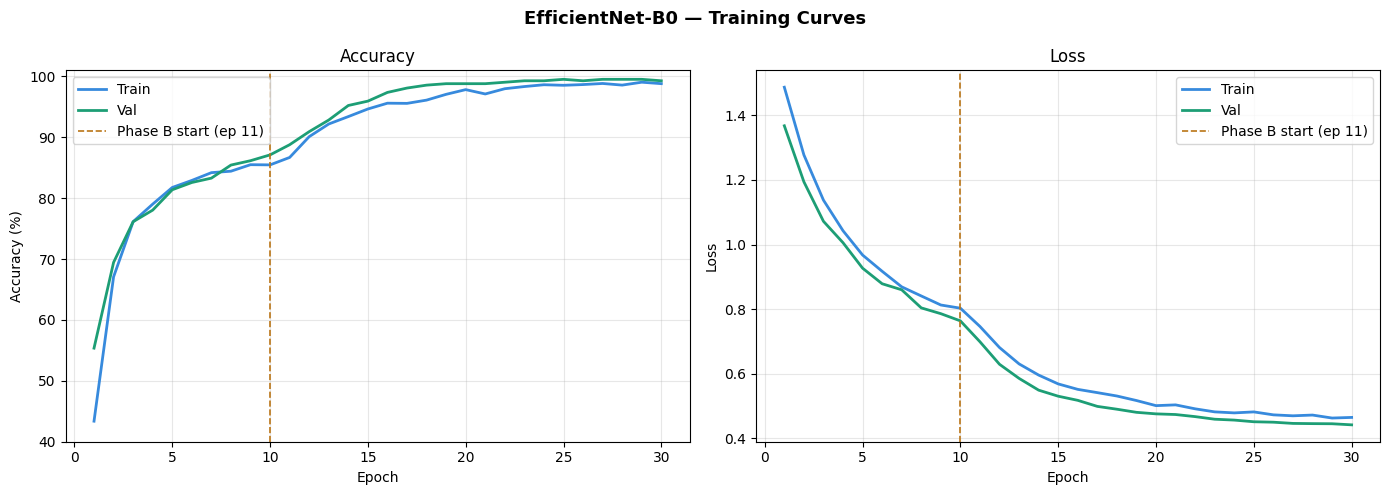

Training curves saved.

Loading best model for test set evaluation...

Test Loss     : 0.4435
Test Accuracy : 99.76%

Classification Report — EfficientNet-B0
                 precision    recall  f1-score   support

BacterialBlight     1.0000    0.9880    0.9939        83
          Blast     1.0000    1.0000    1.0000        79
      BrownSpot     1.0000    1.0000    1.0000        67
        Healthy     0.9899    1.0000    0.9949        98
         Tungro     1.0000    1.0000    1.0000        98

       accuracy                         0.9976       425
      macro avg     0.9980    0.9976    0.9978       425
   weighted avg     0.9977    0.9976    0.9976       425



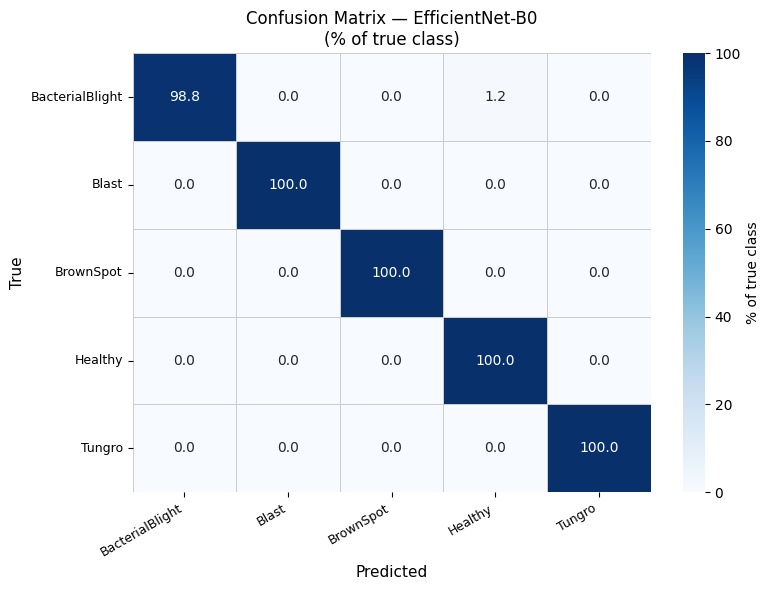

Confusion matrix saved.

Model Summary — EfficientNet-B0
Total Parameters  : 4,013,953
Model Size (fp32) : 15.31 MB
Best Val Accuracy : 99.52%
Test Accuracy     : 99.76%

All outputs saved to: /content/drive/MyDrive/Results/EfficientNet_B0/
  best_model.pth
  last_model.pth
  training_history.json
  training_curves.png
  confusion_matrix.png
  classification_report.txt
  model_info.json


In [ ]:
# ==========================================================
# Experiment 3 — Training Loop
# EfficientNet-B0
# ==========================================================

import copy
import json

# ==========================================================
# Configuration
# ==========================================================

PHASE_A_EPOCHS = 10
PHASE_B_EPOCHS = 20
TOTAL_EPOCHS   = PHASE_A_EPOCHS + PHASE_B_EPOCHS

LR_PHASE_B     = 1e-5

OUTPUT_DIR_EFF = "/content/drive/MyDrive/Results/EfficientNet_B0"
os.makedirs(OUTPUT_DIR_EFF, exist_ok=True)


def unfreeze_last_n_blocks_eff(model, n=4):
    """
    Unfreeze last n blocks of EfficientNet-B0 features for Phase B.
    EfficientNet-B0 has 9 feature blocks (index 0-8).
    Unfreezing last 4 = blocks 5-8 (deepest, most task-specific).
    Note: EfficientNet has fewer but larger blocks than MobileNet.
    """
    for param in model.features.parameters():
        param.requires_grad = False

    blocks = list(model.features.children())
    for block in blocks[-n:]:
        for param in block.parameters():
            param.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters()
                    if p.requires_grad)
    print(f"  Unfroze last {n} backbone blocks")
    print(f"  Trainable parameters: {trainable:,}")


# ==========================================================
# Training Loop
# ==========================================================

history_eff  = []
best_acc_eff = 0.0
best_wts_eff = copy.deepcopy(model_eff.state_dict())

print("=" * 70)
print("Training — EfficientNet-B0")
print("=" * 70)
print(f"Phase A : Epochs 1–{PHASE_A_EPOCHS}  "
      f"(backbone frozen, classifier trains, LR={LEARNING_RATE})")
print(f"Phase B : Epochs {PHASE_A_EPOCHS+1}–{TOTAL_EPOCHS}  "
      f"(last 4 blocks unfrozen, LR={LR_PHASE_B})")
print("=" * 70)
print(f"\n{'Epoch':>5} {'Phase':>7} {'Tr Loss':>9} {'Tr Acc':>8} "
      f"{'Va Loss':>9} {'Va Acc':>8} {'LR':>9} {'Time':>6}")
print("─" * 70)

for epoch in range(1, TOTAL_EPOCHS + 1):

    t0 = time.time()

    # ── Phase B switch ────────────────────────────────────
    if epoch == PHASE_A_EPOCHS + 1:
        print(f"\n{'─'*70}")
        print(f"  Switching to Phase B — fine-tuning")
        unfreeze_last_n_blocks_eff(model_eff, n=4)

        optimizer_eff = optim.AdamW(
            filter(lambda p: p.requires_grad, model_eff.parameters()),
            lr           = LR_PHASE_B,
            weight_decay = WEIGHT_DECAY
        )
        scheduler_eff = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer_eff,
            mode    = "min",
            factor  = 0.5,
            patience= 5,
            min_lr  = 1e-7
        )
        print(f"{'─'*70}\n")

    phase = "A" if epoch <= PHASE_A_EPOCHS else "B"

    # ── Train ─────────────────────────────────────────────
    tr_loss, tr_acc = train_one_epoch(
        model_eff, train_loader, criterion_eff, optimizer_eff
    )

    # ── Validate ──────────────────────────────────────────
    va_loss, va_acc, _, _ = evaluate(
        model_eff, val_loader, criterion_eff
    )

    # ── Scheduler ─────────────────────────────────────────
    scheduler_eff.step(va_loss)

    # ── Log ───────────────────────────────────────────────
    elapsed    = time.time() - t0
    current_lr = optimizer_eff.param_groups[0]['lr']

    print(f"{epoch:>5} {phase:>7} {tr_loss:>9.4f} {tr_acc:>7.2f}% "
          f"{va_loss:>9.4f} {va_acc:>7.2f}% "
          f"{current_lr:>9.2e} {elapsed:>5.0f}s")

    history_eff.append({
        "epoch"     : epoch,
        "phase"     : phase,
        "train_loss": round(tr_loss, 6),
        "train_acc" : round(tr_acc, 4),
        "val_loss"  : round(va_loss, 6),
        "val_acc"   : round(va_acc, 4),
        "lr"        : current_lr,
    })

    if va_acc > best_acc_eff:
        best_acc_eff = va_acc
        best_wts_eff = copy.deepcopy(model_eff.state_dict())
        torch.save(
            best_wts_eff,
            os.path.join(OUTPUT_DIR_EFF, "best_model.pth")
        )

torch.save(
    model_eff.state_dict(),
    os.path.join(OUTPUT_DIR_EFF, "last_model.pth")
)
with open(os.path.join(OUTPUT_DIR_EFF, "training_history.json"), "w") as f:
    json.dump(history_eff, f, indent=2)

print("\n" + "=" * 70)
print(f"Training complete.")
print(f"Best Val Accuracy : {best_acc_eff:.2f}%")
print(f"Saved to          : {OUTPUT_DIR_EFF}")
print("=" * 70)


# ==========================================================
# Training Curves
# ==========================================================

epochs  = [h["epoch"]      for h in history_eff]
tr_acc  = [h["train_acc"]  for h in history_eff]
va_acc  = [h["val_acc"]    for h in history_eff]
tr_loss = [h["train_loss"] for h in history_eff]
va_loss = [h["val_loss"]   for h in history_eff]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("EfficientNet-B0 — Training Curves",
             fontsize=13, fontweight='bold')

ax1.plot(epochs, tr_acc,  label="Train", color="#378ADD", linewidth=2)
ax1.plot(epochs, va_acc,  label="Val",   color="#1D9E75", linewidth=2)
ax1.axvline(PHASE_A_EPOCHS, color="#BA7517", linestyle="--",
            linewidth=1.2, label=f"Phase B start (ep {PHASE_A_EPOCHS+1})")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy (%)")
ax1.set_title("Accuracy"); ax1.legend(); ax1.grid(alpha=0.3)
ax1.set_ylim([40, 101])

ax2.plot(epochs, tr_loss, label="Train", color="#378ADD", linewidth=2)
ax2.plot(epochs, va_loss, label="Val",   color="#1D9E75", linewidth=2)
ax2.axvline(PHASE_A_EPOCHS, color="#BA7517", linestyle="--",
            linewidth=1.2, label=f"Phase B start (ep {PHASE_A_EPOCHS+1})")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
ax2.set_title("Loss"); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_EFF, "training_curves.png"),
            dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved.")


# ==========================================================
# Final Evaluation on Test Set
# ==========================================================

print("\nLoading best model for test set evaluation...")
model_eff.load_state_dict(best_wts_eff)

test_loss_eff, test_acc_eff, test_preds_eff, test_labels_eff = evaluate(
    model_eff, test_loader, criterion_eff
)

print(f"\nTest Loss     : {test_loss_eff:.4f}")
print(f"Test Accuracy : {test_acc_eff:.2f}%")

classes = train_dataset.classes

report_eff = classification_report(
    test_labels_eff,
    test_preds_eff,
    target_names = classes,
    digits       = 4
)

print("\n" + "=" * 60)
print("Classification Report — EfficientNet-B0")
print("=" * 60)
print(report_eff)

with open(os.path.join(OUTPUT_DIR_EFF, "classification_report.txt"), "w") as f:
    f.write("EfficientNet-B0 — Classification Report\n")
    f.write("=" * 60 + "\n")
    f.write(report_eff)


# ==========================================================
# Confusion Matrix
# ==========================================================

cm     = confusion_matrix(test_labels_eff, test_preds_eff)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm_pct, annot=True, fmt=".1f", cmap="Blues",
    xticklabels=classes, yticklabels=classes,
    ax=ax, linewidths=0.5, linecolor='#ccc',
    cbar_kws={"label": "% of true class"}
)
ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("True",      fontsize=11)
ax.set_title("Confusion Matrix — EfficientNet-B0\n(% of true class)",
             fontsize=12)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(rotation=0,  fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_EFF, "confusion_matrix.png"),
            dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved.")


# ==========================================================
# Model Summary
# ==========================================================

total_params_eff = sum(p.numel() for p in model_eff.parameters())

print("\n" + "=" * 50)
print("Model Summary — EfficientNet-B0")
print("=" * 50)
print(f"Total Parameters  : {total_params_eff:,}")
print(f"Model Size (fp32) : {total_params_eff * 4 / 1024 / 1024:.2f} MB")
print(f"Best Val Accuracy : {best_acc_eff:.2f}%")
print(f"Test Accuracy     : {test_acc_eff:.2f}%")
print("=" * 50)

model_info_eff = {
    "model"          : "EfficientNet-B0",
    "total_params"   : total_params_eff,
    "size_mb_fp32"   : round(total_params_eff * 4 / 1024 / 1024, 2),
    "num_classes"    : NUM_CLASSES,
    "classes"        : classes,
    "best_val_acc"   : round(best_acc_eff, 4),
    "test_acc"       : round(test_acc_eff, 4),
    "phase_a_epochs" : PHASE_A_EPOCHS,
    "phase_b_epochs" : PHASE_B_EPOCHS,
    "lr_phase_a"     : LEARNING_RATE,
    "lr_phase_b"     : LR_PHASE_B,
    "batch_size"     : BATCH_SIZE,
    "optimizer"      : "AdamW",
    "scheduler"      : "ReduceLROnPlateau",
    "label_smoothing": 0.1,
}

with open(os.path.join(OUTPUT_DIR_EFF, "model_info.json"), "w") as f:
    json.dump(model_info_eff, f, indent=2)

print(f"\nAll outputs saved to: {OUTPUT_DIR_EFF}/")
print("  best_model.pth")
print("  last_model.pth")
print("  training_history.json")
print("  training_curves.png")
print("  confusion_matrix.png")
print("  classification_report.txt")
print("  model_info.json")

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0

# ==========================================================
# Build EfficientNet-B0
# ==========================================================

model_eff = efficientnet_b0(weights=None)

# Replace classifier
in_features = model_eff.classifier[1].in_features

model_eff.classifier[1] = nn.Linear(
    in_features,
    NUM_CLASSES
)

# ==========================================================
# Load trained weights
# ==========================================================

MODEL_PATH = "/content/drive/MyDrive/Results/EfficientNet_B0/best_model.pth"

state_dict = torch.load(
    MODEL_PATH,
    map_location=DEVICE
)

model_eff.load_state_dict(state_dict)

model_eff = model_eff.to(DEVICE)
model_eff.eval()

print("EfficientNet-B0 loaded successfully.")

EfficientNet-B0 loaded successfully.


In [ ]:
# ==========================================================
# Model Complexity Analysis
# EfficientNet-B0
# ==========================================================

!pip install -q thop

import time
from thop import profile

model = model_eff
model.eval()

dummy = torch.randn(1, 3, 224, 224).to(DEVICE)

# ==========================================================
# Parameter Count
# ==========================================================

total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

# ==========================================================
# FLOPs / MACs
# ==========================================================

macs, params = profile(
    model,
    inputs=(dummy,),
    verbose=False
)

# ==========================================================
# Peak GPU Memory
# ==========================================================

torch.cuda.empty_cache()
torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()

with torch.no_grad():
    _ = model(dummy)

torch.cuda.synchronize()

peak_memory = torch.cuda.max_memory_allocated() / (1024 ** 2)

# ==========================================================
# Inference Time
# ==========================================================

# Warm-up
for _ in range(20):
    with torch.no_grad():
        _ = model(dummy)

torch.cuda.synchronize()

starter = torch.cuda.Event(enable_timing=True)
ender = torch.cuda.Event(enable_timing=True)

times = []

for _ in range(100):

    starter.record()

    with torch.no_grad():
        _ = model(dummy)

    ender.record()

    torch.cuda.synchronize()

    times.append(starter.elapsed_time(ender))

avg_time_ms = sum(times) / len(times)

fps = 1000 / avg_time_ms

# ==========================================================
# Model Depth
# ==========================================================

depth = sum(
    1
    for module in model.modules()
    if len(list(module.children())) == 0
)

# ==========================================================
# Model Size
# ==========================================================

model_size = total_params * 4 / (1024 ** 2)

# ==========================================================
# Results
# ==========================================================

print("=" * 65)
print("EfficientNet-B0 Complexity Analysis")
print("=" * 65)

print(f"Total Parameters      : {total_params:,}")
print(f"Trainable Parameters  : {trainable_params:,}")

print("-" * 65)

print(f"MACs                  : {macs/1e6:.2f} M")
print(f"FLOPs                 : {(2*macs)/1e6:.2f} M")

print("-" * 65)

print(f"Peak GPU Memory       : {peak_memory:.2f} MB")

print(f"Average Inference     : {avg_time_ms:.2f} ms/image")

print(f"Images Per Second     : {fps:.2f} FPS")

print("-" * 65)

print(f"Model Depth           : {depth}")

print(f"Model Size            : {model_size:.2f} MB")

print("=" * 65)

EfficientNet-B0 Complexity Analysis
Total Parameters      : 4,013,953
Trainable Parameters  : 4,013,953
-----------------------------------------------------------------
MACs                  : 413.87 M
FLOPs                 : 827.74 M
-----------------------------------------------------------------
Peak GPU Memory       : 150.10 MB
Average Inference     : 8.35 ms/image
Images Per Second     : 119.72 FPS
-----------------------------------------------------------------
Model Depth           : 230
Model Size            : 15.31 MB


In [ ]:
# ==========================================================
# Experiment 5 — MobileNetV3-Small
# ==========================================================
#
# Lightweight baseline using MobileNetV3-Small.
# Same training strategy as previous experiments:
#
# Phase A : Freeze backbone (10 epochs)
# Phase B : Fine-tune last 4 blocks (20 epochs)
#
# ==========================================================

from torchvision.models import (
    mobilenet_v3_small,
    MobileNet_V3_Small_Weights
)

# ==========================================================
# Load Pretrained Model
# ==========================================================

weights = MobileNet_V3_Small_Weights.DEFAULT

model_small = mobilenet_v3_small(weights=weights)

print("Pretrained MobileNetV3-Small loaded.")

# ==========================================================
# Replace Classifier
# ==========================================================

in_features = model_small.classifier[3].in_features

model_small.classifier[3] = nn.Linear(
    in_features,
    NUM_CLASSES
)

print("\nUpdated Classifier:")
print(model_small.classifier)

# ==========================================================
# Phase A — Freeze Backbone
# ==========================================================

for param in model_small.features.parameters():
    param.requires_grad = False

for param in model_small.classifier.parameters():
    param.requires_grad = True

print("Backbone frozen.")

# ==========================================================
# Model Statistics
# ==========================================================

total_params_small = sum(
    p.numel()
    for p in model_small.parameters()
)

trainable_params_small = sum(
    p.numel()
    for p in model_small.parameters()
    if p.requires_grad
)

print("=" * 50)
print("Model Summary")
print("=" * 50)

print(f"Total Parameters      : {total_params_small:,}")
print(f"Trainable Parameters  : {trainable_params_small:,}")
print(f"Model Size (fp32)     : {total_params_small * 4 / 1024 / 1024:.2f} MB")

print("=" * 50)

# ==========================================================
# Loss
# ==========================================================

criterion_small = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

# ==========================================================
# Optimizer
# ==========================================================

optimizer_small = optim.AdamW(

    filter(
        lambda p: p.requires_grad,
        model_small.parameters()
    ),

    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# ==========================================================
# Scheduler
# ==========================================================

scheduler_small = optim.lr_scheduler.ReduceLROnPlateau(

    optimizer_small,

    mode="min",

    factor=0.5,

    patience=5,

    min_lr=1e-6
)

print("Loss      : CrossEntropyLoss")
print("Optimizer : AdamW")
print("Scheduler : ReduceLROnPlateau")

# ==========================================================
# Move to Device
# ==========================================================

model_small = model_small.to(DEVICE)

# ==========================================================
# Forward Pass Verification
# ==========================================================

model_small.eval()

with torch.no_grad():

    images, labels = next(iter(train_loader))

    images = images.to(DEVICE)
    labels = labels.to(DEVICE)

    outputs = model_small(images)

    loss = criterion_small(outputs, labels)

    _, preds = torch.max(outputs, dim=1)

print("=" * 50)
print("Forward Pass Verification")
print("=" * 50)

print(f"Input Shape        : {images.shape}")
print(f"Output Shape       : {outputs.shape}")
print(f"Loss               : {loss.item():.4f}")
print(f"Unique Predictions : {torch.unique(preds)}")

print("=" * 50)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 81.1MB/s]


Pretrained MobileNetV3-Small loaded.

Updated Classifier:
Sequential(
  (0): Linear(in_features=576, out_features=1024, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1024, out_features=5, bias=True)
)
Backbone frozen.
Model Summary
Total Parameters      : 1,522,981
Trainable Parameters  : 595,973
Model Size (fp32)     : 5.81 MB
Loss      : CrossEntropyLoss
Optimizer : AdamW
Scheduler : ReduceLROnPlateau
Forward Pass Verification
Input Shape        : torch.Size([32, 3, 224, 224])
Output Shape       : torch.Size([32, 5])
Loss               : 1.5813
Unique Predictions : tensor([0, 2, 3, 4], device='cuda:0')


In [ ]:
# ==========================================================
# Experiment 5 — Training Loop
# MobileNetV3-Small
# ==========================================================

import copy
import json
import os
import time

# ==========================================================
# Configuration
# ==========================================================

PHASE_A_EPOCHS = 10
PHASE_B_EPOCHS = 20
TOTAL_EPOCHS   = PHASE_A_EPOCHS + PHASE_B_EPOCHS

LR_PHASE_B = 1e-5

OUTPUT_DIR_SMALL = "/content/drive/MyDrive/Results/MobileNetV3_Small"
os.makedirs(OUTPUT_DIR_SMALL, exist_ok=True)

# ==========================================================
# Phase B
# ==========================================================

def unfreeze_last_n_blocks_small(model, n=4):
    """
    Unfreeze last n MobileNetV3-Small feature blocks.
    """

    for param in model.features.parameters():
        param.requires_grad = False

    blocks = list(model.features.children())

    for block in blocks[-n:]:
        for param in block.parameters():
            param.requires_grad = True

    trainable = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    print(f"  Unfroze last {n} backbone blocks")
    print(f"  Trainable parameters: {trainable:,}")

# ==========================================================
# Training Loop
# ==========================================================

history_small = []

best_acc_small = 0.0

best_wts_small = copy.deepcopy(
    model_small.state_dict()
)

print("=" * 70)
print("Training — MobileNetV3-Small")
print("=" * 70)

print(
    f"Phase A : Epochs 1–{PHASE_A_EPOCHS}  "
    f"(backbone frozen, classifier trains, LR={LEARNING_RATE})"
)

print(
    f"Phase B : Epochs {PHASE_A_EPOCHS+1}–{TOTAL_EPOCHS}  "
    f"(last 4 blocks unfrozen, LR={LR_PHASE_B})"
)

print("=" * 70)

print(
    f"\n{'Epoch':>5} {'Phase':>7} "
    f"{'Tr Loss':>9} {'Tr Acc':>8} "
    f"{'Va Loss':>9} {'Va Acc':>8} "
    f"{'LR':>9} {'Time':>6}"
)

print("─" * 70)

for epoch in range(1, TOTAL_EPOCHS + 1):

    t0 = time.time()

    # ======================================================
    # Phase B
    # ======================================================

    if epoch == PHASE_A_EPOCHS + 1:

        print("\n" + "─" * 70)
        print("  Switching to Phase B — fine-tuning")

        unfreeze_last_n_blocks_small(
            model_small,
            n=4
        )

        optimizer_small = optim.AdamW(

            filter(
                lambda p: p.requires_grad,
                model_small.parameters()
            ),

            lr=LR_PHASE_B,

            weight_decay=WEIGHT_DECAY
        )

        scheduler_small = optim.lr_scheduler.ReduceLROnPlateau(

            optimizer_small,

            mode="min",

            factor=0.5,

            patience=5,

            min_lr=1e-7
        )

        print("─" * 70 + "\n")

    phase = "A" if epoch <= PHASE_A_EPOCHS else "B"

    # ======================================================
    # Train
    # ======================================================

    train_loss, train_acc = train_one_epoch(

        model_small,

        train_loader,

        criterion_small,

        optimizer_small
    )

    # ======================================================
    # Validation
    # ======================================================

    val_loss, val_acc, _, _ = evaluate(

        model_small,

        val_loader,

        criterion_small
    )

    # ======================================================
    # Scheduler
    # ======================================================

    scheduler_small.step(val_loss)

    # ======================================================
    # Print
    # ======================================================

    elapsed = time.time() - t0

    current_lr = optimizer_small.param_groups[0]["lr"]

    print(
        f"{epoch:>5} {phase:>7} "
        f"{train_loss:>9.4f} {train_acc:>7.2f}% "
        f"{val_loss:>9.4f} {val_acc:>7.2f}% "
        f"{current_lr:>9.2e} {elapsed:>5.0f}s"
    )

    history_small.append({

        "epoch": epoch,

        "phase": phase,

        "train_loss": round(train_loss,6),

        "train_acc": round(train_acc,4),

        "val_loss": round(val_loss,6),

        "val_acc": round(val_acc,4),

        "lr": current_lr

    })

    # ======================================================
    # Save Best
    # ======================================================

    if val_acc > best_acc_small:

        best_acc_small = val_acc

        best_wts_small = copy.deepcopy(
            model_small.state_dict()
        )

        torch.save(

            best_wts_small,

            os.path.join(
                OUTPUT_DIR_SMALL,
                "best_model.pth"
            )

        )

# ==========================================================
# Save Last Model
# ==========================================================

torch.save(

    model_small.state_dict(),

    os.path.join(
        OUTPUT_DIR_SMALL,
        "last_model.pth"
    )

)

# ==========================================================
# Save History
# ==========================================================

with open(

    os.path.join(
        OUTPUT_DIR_SMALL,
        "training_history.json"
    ),

    "w"

) as f:

    json.dump(

        history_small,

        f,

        indent=2

    )

print("\n" + "=" * 70)

print("Training complete.")

print(f"Best Val Accuracy : {best_acc_small:.2f}%")

print(f"Saved to          : {OUTPUT_DIR_SMALL}")

print("=" * 70)

Training — MobileNetV3-Small
Phase A : Epochs 1–10  (backbone frozen, classifier trains, LR=0.0001)
Phase B : Epochs 11–30  (last 4 blocks unfrozen, LR=1e-05)

Epoch   Phase   Tr Loss   Tr Acc   Va Loss   Va Acc        LR   Time
──────────────────────────────────────────────────────────────────────
    1       A    1.1974   65.42%    0.9977   71.36%  1.00e-04   170s
    2       A    0.8374   82.38%    0.7574   84.01%  1.00e-04   143s
    3       A    0.7218   86.60%    0.6778   88.07%  1.00e-04   141s
    4       A    0.6862   88.65%    0.6542   90.93%  1.00e-04   143s
    5       A    0.6622   89.33%    0.6202   90.93%  1.00e-04   142s
    6       A    0.6398   90.97%    0.6052   92.60%  1.00e-04   143s
    7       A    0.6219   92.28%    0.5895   93.56%  1.00e-04   143s
    8       A    0.6103   92.66%    0.5787   94.51%  1.00e-04   142s
    9       A    0.6024   93.52%    0.5695   94.75%  1.00e-04   142s
   10       A    0.5973   93.52%    0.5589   94.99%  1.00e-04   142s

─────────

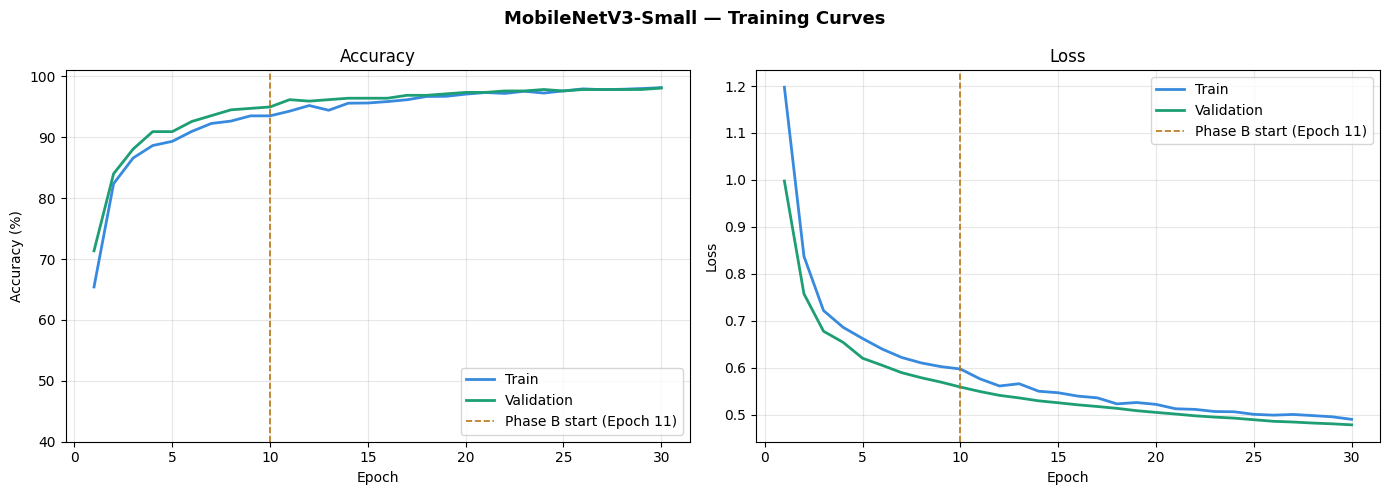

Training curves saved.

Loading best model for test set evaluation...

Test Loss     : 0.4692
Test Accuracy : 99.29%

Classification Report — MobileNetV3-Small
                 precision    recall  f1-score   support

BacterialBlight     0.9880    0.9880    0.9880        83
          Blast     0.9873    0.9873    0.9873        79
      BrownSpot     1.0000    0.9851    0.9925        67
        Healthy     0.9899    1.0000    0.9949        98
         Tungro     1.0000    1.0000    1.0000        98

       accuracy                         0.9929       425
      macro avg     0.9930    0.9921    0.9925       425
   weighted avg     0.9930    0.9929    0.9929       425



In [ ]:
# ==========================================================
# Training Curves
# ==========================================================

epochs   = [h["epoch"]      for h in history_small]
tr_acc   = [h["train_acc"]  for h in history_small]
va_acc   = [h["val_acc"]    for h in history_small]
tr_loss  = [h["train_loss"] for h in history_small]
va_loss  = [h["val_loss"]   for h in history_small]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

fig.suptitle(
    "MobileNetV3-Small — Training Curves",
    fontsize=13,
    fontweight="bold"
)

# ==========================================================
# Accuracy Curve
# ==========================================================

ax1.plot(
    epochs,
    tr_acc,
    label="Train",
    color="#378ADD",
    linewidth=2
)

ax1.plot(
    epochs,
    va_acc,
    label="Validation",
    color="#1D9E75",
    linewidth=2
)

ax1.axvline(
    PHASE_A_EPOCHS,
    color="#BA7517",
    linestyle="--",
    linewidth=1.2,
    label=f"Phase B start (Epoch {PHASE_A_EPOCHS+1})"
)

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy (%)")
ax1.set_title("Accuracy")
ax1.grid(alpha=0.3)
ax1.legend()
ax1.set_ylim([40, 101])

# ==========================================================
# Loss Curve
# ==========================================================

ax2.plot(
    epochs,
    tr_loss,
    label="Train",
    color="#378ADD",
    linewidth=2
)

ax2.plot(
    epochs,
    va_loss,
    label="Validation",
    color="#1D9E75",
    linewidth=2
)

ax2.axvline(
    PHASE_A_EPOCHS,
    color="#BA7517",
    linestyle="--",
    linewidth=1.2,
    label=f"Phase B start (Epoch {PHASE_A_EPOCHS+1})"
)

ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.set_title("Loss")
ax2.grid(alpha=0.3)
ax2.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR_SMALL,
        "training_curves.png"
    ),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Training curves saved.")

# ==========================================================
# Final Evaluation on Test Set
# ==========================================================

print("\nLoading best model for test set evaluation...")

model_small.load_state_dict(best_wts_small)

test_loss_small, test_acc_small, test_preds_small, test_labels_small = evaluate(

    model_small,

    test_loader,

    criterion_small

)

print(f"\nTest Loss     : {test_loss_small:.4f}")
print(f"Test Accuracy : {test_acc_small:.2f}%")

# ==========================================================
# Classification Report
# ==========================================================

classes = train_dataset.classes

report_small = classification_report(

    test_labels_small,

    test_preds_small,

    target_names=classes,

    digits=4

)

print("\n" + "=" * 60)
print("Classification Report — MobileNetV3-Small")
print("=" * 60)

print(report_small)

with open(

    os.path.join(
        OUTPUT_DIR_SMALL,
        "classification_report.txt"
    ),

    "w"

) as f:

    f.write("MobileNetV3-Small — Classification Report\n")
    f.write("=" * 60 + "\n")
    f.write(report_small)

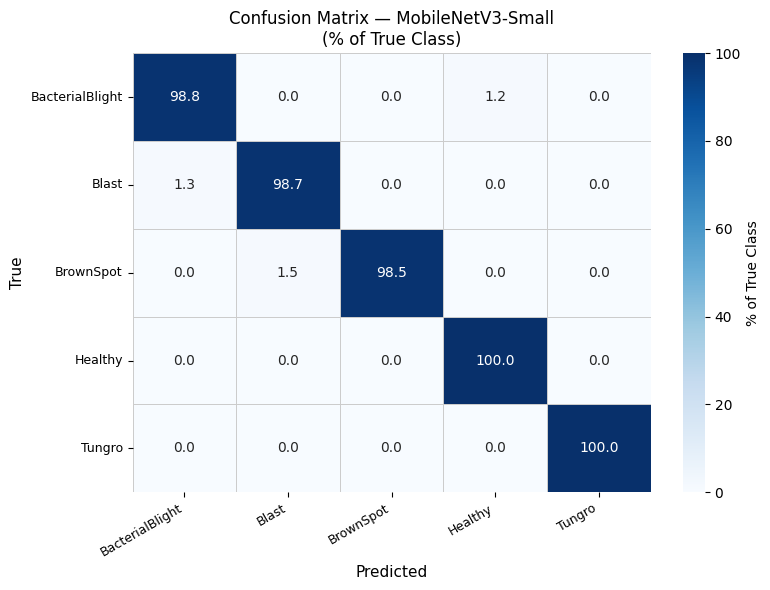

Confusion matrix saved.

Model Summary — MobileNetV3-Small
Total Parameters  : 1,522,981
Model Size (fp32) : 5.81 MB
Best Val Accuracy : 98.09%
Test Accuracy     : 99.29%

All outputs saved to: /content/drive/MyDrive/Results/MobileNetV3_Small/
  best_model.pth
  last_model.pth
  training_history.json
  training_curves.png
  confusion_matrix.png
  classification_report.txt
  model_info.json


In [ ]:
# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(
    test_labels_small,
    test_preds_small
)

cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    cm_pct,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
    linewidths=0.5,
    linecolor="#CCCCCC",
    cbar_kws={"label": "% of True Class"},
    ax=ax
)

ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("True", fontsize=11)

ax.set_title(
    "Confusion Matrix — MobileNetV3-Small\n(% of True Class)",
    fontsize=12
)

plt.xticks(rotation=30, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR_SMALL,
        "confusion_matrix.png"
    ),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved.")

# ==========================================================
# Model Summary
# ==========================================================

total_params_small = sum(
    p.numel()
    for p in model_small.parameters()
)

print("\n" + "=" * 50)
print("Model Summary — MobileNetV3-Small")
print("=" * 50)

print(f"Total Parameters  : {total_params_small:,}")
print(f"Model Size (fp32) : {total_params_small * 4 / 1024 / 1024:.2f} MB")
print(f"Best Val Accuracy : {best_acc_small:.2f}%")
print(f"Test Accuracy     : {test_acc_small:.2f}%")

print("=" * 50)

# ==========================================================
# Save Model Information
# ==========================================================

model_info_small = {

    "model": "MobileNetV3-Small",

    "total_params": total_params_small,

    "size_mb_fp32": round(
        total_params_small * 4 / 1024 / 1024,
        2
    ),

    "num_classes": NUM_CLASSES,

    "classes": classes,

    "best_val_acc": round(
        best_acc_small,
        4
    ),

    "test_acc": round(
        test_acc_small,
        4
    ),

    "phase_a_epochs": PHASE_A_EPOCHS,

    "phase_b_epochs": PHASE_B_EPOCHS,

    "lr_phase_a": LEARNING_RATE,

    "lr_phase_b": LR_PHASE_B,

    "batch_size": BATCH_SIZE,

    "optimizer": "AdamW",

    "scheduler": "ReduceLROnPlateau",

    "label_smoothing": 0.1

}

with open(

    os.path.join(
        OUTPUT_DIR_SMALL,
        "model_info.json"
    ),

    "w"

) as f:

    json.dump(
        model_info_small,
        f,
        indent=2
    )

# ==========================================================
# Finished
# ==========================================================

print(f"\nAll outputs saved to: {OUTPUT_DIR_SMALL}/")

print("  best_model.pth")
print("  last_model.pth")
print("  training_history.json")
print("  training_curves.png")
print("  confusion_matrix.png")
print("  classification_report.txt")
print("  model_info.json")

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import (
    mobilenet_v3_small,
    MobileNet_V3_Small_Weights
)

# ==========================================================
# Build MobileNetV3-Small
# ==========================================================

model_small = mobilenet_v3_small(weights=None)

# Replace classifier

in_features = model_small.classifier[3].in_features

model_small.classifier[3] = nn.Linear(
    in_features,
    NUM_CLASSES
)

# ==========================================================
# Load trained weights
# ==========================================================

MODEL_PATH = "/content/drive/MyDrive/Results/MobileNetV3_Small/best_model.pth"

state_dict = torch.load(
    MODEL_PATH,
    map_location=DEVICE
)

model_small.load_state_dict(state_dict)

model_small = model_small.to(DEVICE)

model_small.eval()

print("MobileNetV3-Small loaded successfully.")

MobileNetV3-Small loaded successfully.


In [ ]:
# ==========================================================
# Model Complexity Analysis
# MobileNetV3-Small
# ==========================================================

!pip install -q thop

import time
from thop import profile

model = model_small
model.eval()

dummy = torch.randn(1, 3, 224, 224).to(DEVICE)

# ==========================================================
# Parameter Count
# ==========================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

# ==========================================================
# FLOPs / MACs
# ==========================================================

macs, params = profile(
    model,
    inputs=(dummy,),
    verbose=False
)

# ==========================================================
# Peak GPU Memory
# ==========================================================

torch.cuda.empty_cache()
torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()

with torch.no_grad():
    _ = model(dummy)

torch.cuda.synchronize()

peak_memory = torch.cuda.max_memory_allocated() / (1024**2)

# ==========================================================
# Inference Time
# ==========================================================

# Warm-up

for _ in range(20):
    with torch.no_grad():
        _ = model(dummy)

torch.cuda.synchronize()

starter = torch.cuda.Event(enable_timing=True)
ender   = torch.cuda.Event(enable_timing=True)

times = []

for _ in range(100):

    starter.record()

    with torch.no_grad():
        _ = model(dummy)

    ender.record()

    torch.cuda.synchronize()

    times.append(
        starter.elapsed_time(ender)
    )

avg_time_ms = sum(times) / len(times)

fps = 1000 / avg_time_ms

# ==========================================================
# Model Depth
# ==========================================================

depth = sum(

    1

    for module in model.modules()

    if len(list(module.children())) == 0

)

# ==========================================================
# Model Size
# ==========================================================

model_size = total_params * 4 / (1024**2)

# ==========================================================
# Results
# ==========================================================

print("=" * 65)
print("MobileNetV3-Small Complexity Analysis")
print("=" * 65)

print(f"Total Parameters      : {total_params:,}")
print(f"Trainable Parameters  : {trainable_params:,}")

print("-" * 65)

print(f"MACs                  : {macs/1e6:.2f} M")
print(f"FLOPs                 : {(2*macs)/1e6:.2f} M")

print("-" * 65)

print(f"Peak GPU Memory       : {peak_memory:.2f} MB")

print(f"Average Inference     : {avg_time_ms:.2f} ms/image")

print(f"Images Per Second     : {fps:.2f} FPS")

print("-" * 65)

print(f"Model Depth           : {depth}")

print(f"Model Size            : {model_size:.2f} MB")

print("=" * 65)

MobileNetV3-Small Complexity Analysis
Total Parameters      : 1,522,981
Trainable Parameters  : 1,522,981
-----------------------------------------------------------------
MACs                  : 61.46 M
FLOPs                 : 122.92 M
-----------------------------------------------------------------
Peak GPU Memory       : 166.05 MB
Average Inference     : 5.67 ms/image
Images Per Second     : 176.46 FPS
-----------------------------------------------------------------
Model Depth           : 141
Model Size            : 5.81 MB


In [ ]:
# ==========================================================
# Experiment 6 — RiceDT
# Part 1 — Model Architecture
# Custom Lightweight CNN for Rice Leaf Disease Detection
# ==========================================================

import torch
import torch.nn as nn
import torch.nn.functional as F


# ==========================================================
# 1. Depthwise-Separable Convolution
# ==========================================================

class DWSepConv(nn.Module):
    """
    Depthwise-Separable Convolution

    Reduces computation compared with a standard convolution
    while preserving spatial feature extraction.
    """

    def __init__(self, in_ch, out_ch, stride=1):

        super().__init__()

        # Depthwise convolution
        self.dw = nn.Conv2d(
            in_ch,
            in_ch,
            kernel_size=3,
            stride=stride,
            padding=1,
            groups=in_ch,
            bias=False
        )

        # Pointwise convolution
        self.pw = nn.Conv2d(
            in_ch,
            out_ch,
            kernel_size=1,
            bias=False
        )

        self.bn = nn.BatchNorm2d(
            out_ch
        )


    def forward(self, x):

        x = self.dw(x)

        x = self.pw(x)

        x = self.bn(x)

        x = F.hardswish(x)

        return x


# ==========================================================
# 2. SE Channel Attention
# ==========================================================

class SEAttention(nn.Module):
    """
    Squeeze-and-Excitation channel attention.

    The attention mechanism learns the importance of
    individual feature channels.
    """

    def __init__(
        self,
        channels,
        reduction=8
    ):

        super().__init__()

        mid = max(
            channels // reduction,
            8
        )

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Sequential(

            nn.Linear(
                channels,
                mid,
                bias=False
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Linear(
                mid,
                channels,
                bias=False
            ),

            nn.Sigmoid()

        )


    def forward(self, x):

        B, C, _, _ = x.shape

        # Global channel descriptor
        w = self.pool(x)

        w = w.view(
            B,
            C
        )

        # Channel attention
        w = self.fc(w)

        w = w.view(
            B,
            C,
            1,
            1
        )

        return x * w


# ==========================================================
# 3. RiceBlock
# ==========================================================

class RiceBlock(nn.Module):
    """
    Core RiceDT building block.

    Structure:

        Depthwise-Separable Conv
                    ↓
             SE Attention
                    ↓
             Skip Connection
                    ↓
               HardSwish
    """

    def __init__(
        self,
        in_ch,
        out_ch,
        stride=1
    ):

        super().__init__()


        # Main branch
        self.conv = DWSepConv(
            in_ch,
            out_ch,
            stride=stride
        )


        # SE attention
        self.attn = SEAttention(
            out_ch,
            reduction=8
        )


        # Skip connection
        if (
            in_ch == out_ch
            and stride == 1
        ):

            self.skip = nn.Identity()

        else:

            self.skip = nn.Sequential(

                nn.Conv2d(
                    in_ch,
                    out_ch,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),

                nn.BatchNorm2d(
                    out_ch
                )

            )


    def forward(self, x):

        # Main branch
        out = self.conv(x)

        # SE channel recalibration
        out = self.attn(out)

        # Residual connection
        out = out + self.skip(x)

        # Activation
        out = F.hardswish(
            out
        )

        return out


# ==========================================================
# 4. RiceDT
# ==========================================================

class RiceDT(nn.Module):
    """
    RiceDT — Custom Lightweight CNN

    Input:
        3 × 224 × 224

    Output:
        NUM_CLASSES

    Architecture:

        Input
          ↓
        Stem: 3 → 32
          ↓
        RiceBlock: 32 → 64
          ↓
        RiceBlock: 64 → 128
          ↓
        RiceBlock: 128 → 128
          ↓
        RiceBlock: 128 → 256
          ↓
        RiceBlock: 256 → 256
          ↓
        Global Average Pooling
          ↓
        Dropout
          ↓
        Linear Classifier
    """

    def __init__(
        self,
        num_classes=5,
        dropout=0.35
    ):

        super().__init__()


        # ==================================================
        # Stem
        # ==================================================

        self.stem = nn.Sequential(

            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                32
            ),

            nn.Hardswish()

        )


        # ==================================================
        # RiceDT Body
        # ==================================================

        self.body = nn.Sequential(

            # 112 → 56
            RiceBlock(
                32,
                64,
                stride=2
            ),

            # 56 → 28
            RiceBlock(
                64,
                128,
                stride=2
            ),

            # Feature refinement
            RiceBlock(
                128,
                128,
                stride=1
            ),

            # 28 → 14
            RiceBlock(
                128,
                256,
                stride=2
            ),

            # Feature refinement
            RiceBlock(
                256,
                256,
                stride=1
            )

        )


        # ==================================================
        # Classification Head
        # ==================================================

        self.head = nn.Sequential(

            nn.AdaptiveAvgPool2d(1),

            nn.Flatten(),

            nn.Dropout(
                p=dropout
            ),

            nn.Linear(
                256,
                num_classes
            )

        )


        # Initialize weights
        self._init_weights()


    # ======================================================
    # Forward
    # ======================================================

    def forward(self, x):

        x = self.stem(x)

        x = self.body(x)

        x = self.head(x)

        return x


    # ======================================================
    # Weight Initialization
    # ======================================================

    def _init_weights(self):

        for m in self.modules():

            if isinstance(
                m,
                nn.Conv2d
            ):

                nn.init.kaiming_normal_(
                    m.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )


            elif isinstance(
                m,
                nn.BatchNorm2d
            ):

                nn.init.ones_(
                    m.weight
                )

                nn.init.zeros_(
                    m.bias
                )


            elif isinstance(
                m,
                nn.Linear
            ):

                nn.init.kaiming_normal_(
                    m.weight,
                    mode="fan_out"
                )

                if m.bias is not None:

                    nn.init.zeros_(
                        m.bias
                    )


    # ======================================================
    # Parameter Count
    # ======================================================

    def count_params(self):

        return sum(
            p.numel()
            for p in self.parameters()
        )


    # ======================================================
    # FP32 Model Size
    # ======================================================

    def size_mb(self):

        return round(
            self.count_params()
            * 4
            / (1024 ** 2),
            2
        )


# ==========================================================
# End of Part 1
# ==========================================================

print("✅ RiceDT architecture defined successfully.")

✅ RiceDT architecture defined successfully.


In [ ]:
# ==========================================================
# Experiment 6 — RiceDT
# Part 2 — Model Creation & Verification
# ==========================================================

# ==========================================================
# Create Model
# ==========================================================

model_ricedt = RiceDT(
    num_classes=NUM_CLASSES,
    dropout=0.35
)

model_ricedt = model_ricedt.to(DEVICE)


# ==========================================================
# Parameter Count
# ==========================================================

total_params_ricedt = sum(
    p.numel()
    for p in model_ricedt.parameters()
)

trainable_params_ricedt = sum(
    p.numel()
    for p in model_ricedt.parameters()
    if p.requires_grad
)


model_size_ricedt = (
    total_params_ricedt * 4
    / (1024 ** 2)
)


# ==========================================================
# Print Model Information
# ==========================================================

print("=" * 70)
print("RiceDT — Model Verification")
print("=" * 70)

print(
    f"Total Parameters     : "
    f"{total_params_ricedt:,}"
)

print(
    f"Trainable Parameters : "
    f"{trainable_params_ricedt:,}"
)

print(
    f"Model Size (FP32)    : "
    f"{model_size_ricedt:.2f} MB"
)

print(
    f"Device               : "
    f"{DEVICE}"
)

print("=" * 70)


# ==========================================================
# Forward Pass Test
# ==========================================================

dummy_input_ricedt = torch.randn(
    2,
    3,
    224,
    224
).to(DEVICE)


model_ricedt.eval()


with torch.no_grad():

    dummy_output_ricedt = model_ricedt(
        dummy_input_ricedt
    )


print("\nForward Pass Verification")
print("-" * 70)

print(
    f"Input Shape  : "
    f"{tuple(dummy_input_ricedt.shape)}"
)

print(
    f"Output Shape : "
    f"{tuple(dummy_output_ricedt.shape)}"
)

print(
    f"Expected     : "
    f"(2, {NUM_CLASSES})"
)


# ==========================================================
# Verify Output
# ==========================================================

assert dummy_output_ricedt.shape == (
    2,
    NUM_CLASSES
)


print("\n✅ RiceDT forward pass successful.")
print("✅ Input/output dimensions are correct.")
print("✅ Model is ready for training.")

print("=" * 70)

RiceDT — Model Verification
Total Parameters     : 220,165
Trainable Parameters : 220,165
Model Size (FP32)    : 0.84 MB
Device               : cuda

Forward Pass Verification
----------------------------------------------------------------------
Input Shape  : (2, 3, 224, 224)
Output Shape : (2, 5)
Expected     : (2, 5)

✅ RiceDT forward pass successful.
✅ Input/output dimensions are correct.
✅ Model is ready for training.


In [ ]:
# ==========================================================
# Experiment 6 — RiceDT
# Part 3 — Training Configuration
# ==========================================================

import os
import json
import copy
import time


# ==========================================================
# Training Configuration
# ==========================================================

RICEDT_EPOCHS = 60

RICEDT_WARMUP_EPOCHS = 5

RICEDT_MAX_LR = 3e-3

RICEDT_MIN_LR = 1e-5

RICEDT_WEIGHT_DECAY = 2e-4

RICEDT_LABEL_SMOOTHING = 0.1

RICEDT_DROPOUT = 0.35


# ==========================================================
# Output Directory
# ==========================================================

OUTPUT_DIR_RICEDT = (
    "/content/drive/MyDrive/Results/RiceDT"
)

os.makedirs(
    OUTPUT_DIR_RICEDT,
    exist_ok=True
)


# ==========================================================
# Loss Function
# ==========================================================

criterion_ricedt = nn.CrossEntropyLoss(
    label_smoothing=RICEDT_LABEL_SMOOTHING
)


# ==========================================================
# Optimizer
# ==========================================================

optimizer_ricedt = optim.AdamW(

    model_ricedt.parameters(),

    lr=RICEDT_MAX_LR,

    weight_decay=RICEDT_WEIGHT_DECAY

)


# ==========================================================
# Cosine Annealing Scheduler
# ==========================================================

scheduler_ricedt = optim.lr_scheduler.CosineAnnealingLR(

    optimizer_ricedt,

    T_max=RICEDT_EPOCHS - RICEDT_WARMUP_EPOCHS,

    eta_min=RICEDT_MIN_LR

)


# ==========================================================
# Print Configuration
# ==========================================================

print("=" * 70)
print("RiceDT — Training Configuration")
print("=" * 70)

print(
    f"Total Epochs       : "
    f"{RICEDT_EPOCHS}"
)

print(
    f"Warmup Epochs      : "
    f"{RICEDT_WARMUP_EPOCHS}"
)

print(
    f"Maximum LR         : "
    f"{RICEDT_MAX_LR:.2e}"
)

print(
    f"Minimum LR         : "
    f"{RICEDT_MIN_LR:.2e}"
)

print(
    f"Weight Decay       : "
    f"{RICEDT_WEIGHT_DECAY:.2e}"
)

print(
    f"Label Smoothing    : "
    f"{RICEDT_LABEL_SMOOTHING}"
)

print(
    f"Dropout            : "
    f"{RICEDT_DROPOUT}"
)

print(
    f"Batch Size         : "
    f"{BATCH_SIZE}"
)

print(
    f"Optimizer          : "
    f"AdamW"
)

print(
    f"Scheduler           : "
    f"CosineAnnealingLR"
)

print(
    f"Training Strategy  : "
    f"From Scratch"
)

print(
    f"Device             : "
    f"{DEVICE}"
)

print("=" * 70)

print(
    "\n✅ RiceDT training configuration ready."
)

RiceDT — Training Configuration
Total Epochs       : 60
Warmup Epochs      : 5
Maximum LR         : 3.00e-03
Minimum LR         : 1.00e-05
Weight Decay       : 2.00e-04
Label Smoothing    : 0.1
Dropout            : 0.35
Batch Size         : 32
Optimizer          : AdamW
Scheduler           : CosineAnnealingLR
Training Strategy  : From Scratch
Device             : cuda

✅ RiceDT training configuration ready.


In [ ]:
# ==========================================================
# Experiment 6 — RiceDT
# Part 4 — Training Loop
# ==========================================================

# ==========================================================
# Training / Evaluation Functions
# ==========================================================

def train_one_epoch_ricedt(
    model,
    loader,
    criterion,
    optimizer
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += images.size(0)

    epoch_loss = running_loss / total

    epoch_acc = (
        100.0 * correct / total
    )

    return epoch_loss, epoch_acc


# ==========================================================
# Validation / Test Function
# ==========================================================

@torch.no_grad()
def evaluate_ricedt(
    model,
    loader,
    criterion
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_predictions = []
    all_labels = []

    for images, labels in loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += images.size(0)

        all_predictions.extend(
            predictions.cpu().tolist()
        )

        all_labels.extend(
            labels.cpu().tolist()
        )

    epoch_loss = running_loss / total

    epoch_acc = (
        100.0 * correct / total
    )

    return (
        epoch_loss,
        epoch_acc,
        all_predictions,
        all_labels
    )


# ==========================================================
# Training History
# ==========================================================

history_ricedt = []

best_acc_ricedt = 0.0

best_wts_ricedt = copy.deepcopy(
    model_ricedt.state_dict()
)


# ==========================================================
# Start Training
# ==========================================================

print("=" * 75)
print("Training — RiceDT")
print("=" * 75)

print(
    f"Epochs      : 1–{RICEDT_EPOCHS}"
)

print(
    f"Warmup      : Epochs 1–{RICEDT_WARMUP_EPOCHS}"
)

print(
    f"Max LR      : {RICEDT_MAX_LR:.2e}"
)

print(
    f"Min LR      : {RICEDT_MIN_LR:.2e}"
)

print(
    f"Parameters  : {total_params_ricedt:,}"
)

print(
    f"Model Size  : {model_size_ricedt:.2f} MB"
)

print("=" * 75)

print(
    f"\n{'Epoch':>5} "
    f"{'Phase':>9} "
    f"{'Tr Loss':>10} "
    f"{'Tr Acc':>9} "
    f"{'Va Loss':>10} "
    f"{'Va Acc':>9} "
    f"{'LR':>11} "
    f"{'Time':>7}"
)

print("-" * 75)


# ==========================================================
# Epoch Loop
# ==========================================================

for epoch in range(
    1,
    RICEDT_EPOCHS + 1
):

    epoch_start = time.time()


    # ======================================================
    # Learning Rate
    # ======================================================

    if epoch <= RICEDT_WARMUP_EPOCHS:

        # Linear warmup
        warmup_progress = (
            epoch / RICEDT_WARMUP_EPOCHS
        )

        current_lr = (
            RICEDT_MAX_LR
            * warmup_progress
        )

        for param_group in optimizer_ricedt.param_groups:

            param_group["lr"] = current_lr

        phase = "Warmup"

    else:

        phase = "Cosine"

        current_lr = (
            optimizer_ricedt
            .param_groups[0]["lr"]
        )


    # ======================================================
    # Training
    # ======================================================

    train_loss, train_acc = train_one_epoch_ricedt(

        model_ricedt,

        train_loader,

        criterion_ricedt,

        optimizer_ricedt

    )


    # ======================================================
    # Validation
    # ======================================================

    val_loss, val_acc, _, _ = evaluate_ricedt(

        model_ricedt,

        val_loader,

        criterion_ricedt

    )


    # ======================================================
    # Cosine Scheduler
    # ======================================================

    if epoch > RICEDT_WARMUP_EPOCHS:

        scheduler_ricedt.step()


    # Get LR after scheduler update
    logged_lr = (
        optimizer_ricedt
        .param_groups[0]["lr"]
    )


    # ======================================================
    # Epoch Time
    # ======================================================

    elapsed = (
        time.time()
        - epoch_start
    )


    # ======================================================
    # Print Results
    # ======================================================

    print(

        f"{epoch:>5} "
        f"{phase:>9} "
        f"{train_loss:>10.4f} "
        f"{train_acc:>8.2f}% "
        f"{val_loss:>10.4f} "
        f"{val_acc:>8.2f}% "
        f"{logged_lr:>11.2e} "
        f"{elapsed:>6.0f}s"

    )


    # ======================================================
    # Save History
    # ======================================================

    history_ricedt.append({

        "epoch":
            epoch,

        "phase":
            phase,

        "train_loss":
            round(
                train_loss,
                6
            ),

        "train_acc":
            round(
                train_acc,
                4
            ),

        "val_loss":
            round(
                val_loss,
                6
            ),

        "val_acc":
            round(
                val_acc,
                4
            ),

        "lr":
            logged_lr

    })


    # ======================================================
    # Save Best Model
    # ======================================================

    if val_acc > best_acc_ricedt:

        best_acc_ricedt = val_acc

        best_wts_ricedt = copy.deepcopy(
            model_ricedt.state_dict()
        )

        torch.save(

            best_wts_ricedt,

            os.path.join(
                OUTPUT_DIR_RICEDT,
                "best_model.pth"
            )

        )


# ==========================================================
# Save Last Model
# ==========================================================

torch.save(

    model_ricedt.state_dict(),

    os.path.join(
        OUTPUT_DIR_RICEDT,
        "last_model.pth"
    )

)


# ==========================================================
# Save Training History
# ==========================================================

with open(

    os.path.join(
        OUTPUT_DIR_RICEDT,
        "training_history.json"
    ),

    "w"

) as f:

    json.dump(
        history_ricedt,
        f,
        indent=2
    )


# ==========================================================
# Training Complete
# ==========================================================

print("\n" + "=" * 75)

print("Training complete.")

print(
    f"Best Val Accuracy : "
    f"{best_acc_ricedt:.2f}%"
)

print(
    f"Saved to          : "
    f"{OUTPUT_DIR_RICEDT}"
)

print("=" * 75)

Training — RiceDT
Epochs      : 1–60
Warmup      : Epochs 1–5
Max LR      : 3.00e-03
Min LR      : 1.00e-05
Parameters  : 220,165
Model Size  : 0.84 MB

Epoch     Phase    Tr Loss    Tr Acc    Va Loss    Va Acc          LR    Time
---------------------------------------------------------------------------
    1    Warmup     2.1424    44.18%     1.1584    69.21%    6.00e-04    789s
    2    Warmup     1.4782    56.03%     1.0293    68.02%    1.20e-03    129s
    3    Warmup     1.1630    65.00%     0.9183    77.09%    1.80e-03    132s
    4    Warmup     1.0010    71.24%     0.7635    79.95%    2.40e-03    135s
    5    Warmup     0.9031    76.29%     0.8106    77.57%    3.00e-03    131s
    6    Cosine     0.7919    82.09%     0.7593    82.82%    3.00e-03    133s
    7    Cosine     0.7157    85.47%     0.6370    90.93%    2.99e-03    132s
    8    Cosine     0.6876    86.19%     0.6345    89.50%    2.98e-03    129s
    9    Cosine     0.6596    87.79%     0.5978    90.93%    2.96e-03

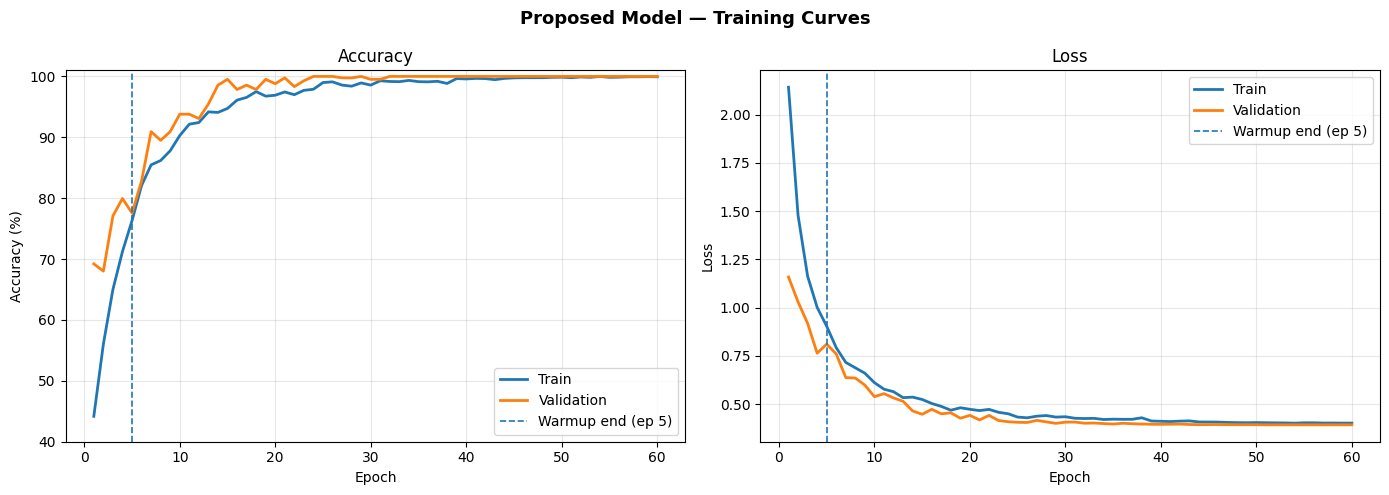

✅ Training curves saved → /content/drive/MyDrive/Results/RiceDT/training_curves.png


In [ ]:
# ==========================================================
# Experiment 6 — RiceDT
# Part 5 — Training Curves
# ==========================================================

import matplotlib.pyplot as plt


# ==========================================================
# Extract History
# ==========================================================

epochs = [
    h["epoch"]
    for h in history_ricedt
]

train_acc = [
    h["train_acc"]
    for h in history_ricedt
]

val_acc = [
    h["val_acc"]
    for h in history_ricedt
]

train_loss = [
    h["train_loss"]
    for h in history_ricedt
]

val_loss = [
    h["val_loss"]
    for h in history_ricedt
]


# ==========================================================
# Create Figure
# ==========================================================

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

fig.suptitle(
    "Proposed Model — Training Curves",
    fontsize=13,
    fontweight="bold"
)


# ==========================================================
# Accuracy
# ==========================================================

ax1.plot(
    epochs,
    train_acc,
    label="Train",
    linewidth=2
)

ax1.plot(
    epochs,
    val_acc,
    label="Validation",
    linewidth=2
)

ax1.axvline(
    RICEDT_WARMUP_EPOCHS,
    linestyle="--",
    linewidth=1.2,
    label=f"Warmup end (ep {RICEDT_WARMUP_EPOCHS})"
)

ax1.set_xlabel(
    "Epoch"
)

ax1.set_ylabel(
    "Accuracy (%)"
)

ax1.set_title(
    "Accuracy"
)

ax1.legend()

ax1.grid(
    alpha=0.3
)

ax1.set_ylim(
    [40, 101]
)


# ==========================================================
# Loss
# ==========================================================

ax2.plot(
    epochs,
    train_loss,
    label="Train",
    linewidth=2
)

ax2.plot(
    epochs,
    val_loss,
    label="Validation",
    linewidth=2
)

ax2.axvline(
    RICEDT_WARMUP_EPOCHS,
    linestyle="--",
    linewidth=1.2,
    label=f"Warmup end (ep {RICEDT_WARMUP_EPOCHS})"
)

ax2.set_xlabel(
    "Epoch"
)

ax2.set_ylabel(
    "Loss"
)

ax2.set_title(
    "Loss"
)

ax2.legend()

ax2.grid(
    alpha=0.3
)


# ==========================================================
# Layout
# ==========================================================

plt.tight_layout()


# ==========================================================
# Save
# ==========================================================

CURVE_PATH = os.path.join(
    OUTPUT_DIR_RICEDT,
    "training_curves.png"
)

plt.savefig(
    CURVE_PATH,
    dpi=150,
    bbox_inches="tight"
)

plt.show()


print(
    f"✅ Training curves saved → {CURVE_PATH}"
)

In [ ]:
# ==========================================================
# Experiment 6 — RiceDT
# Part 6 — Final Test Set Evaluation
# ==========================================================

from sklearn.metrics import classification_report
import os


# ==========================================================
# Load Best Model
# ==========================================================

print("=" * 65)
print("Loading best RiceDT model...")
print("=" * 65)

model_ricedt.load_state_dict(
    best_wts_ricedt
)

model_ricedt = model_ricedt.to(
    DEVICE
)

model_ricedt.eval()


# ==========================================================
# Evaluate Test Set
# ==========================================================

test_loss_ricedt, test_acc_ricedt, test_preds_ricedt, test_labels_ricedt = evaluate_ricedt(
    model_ricedt,
    test_loader,
    criterion_ricedt
)


# ==========================================================
# Print Test Results
# ==========================================================

print("\n" + "=" * 65)
print("RiceDT — Test Set Results")
print("=" * 65)

print(
    f"Test Loss     : "
    f"{test_loss_ricedt:.4f}"
)

print(
    f"Test Accuracy : "
    f"{test_acc_ricedt:.2f}%"
)

print("=" * 65)


# ==========================================================
# Classification Report
# ==========================================================

classes_ricedt = train_dataset.classes

report_ricedt = classification_report(

    test_labels_ricedt,

    test_preds_ricedt,

    target_names=classes_ricedt,

    digits=4

)


print("\n" + "=" * 65)
print("Classification Report — RiceDT")
print("=" * 65)

print(
    report_ricedt
)


# ==========================================================
# Save Classification Report
# ==========================================================

REPORT_PATH = os.path.join(
    OUTPUT_DIR_RICEDT,
    "classification_report.txt"
)

with open(
    REPORT_PATH,
    "w"
) as f:

    f.write(
        "Proposed Model — Classification Report\n"
    )

    f.write(
        "=" * 65 + "\n"
    )

    f.write(
        report_ricedt
    )


print(
    f"\n✅ Classification report saved → "
    f"{REPORT_PATH}"
)


# ==========================================================
# Save Test Results
# ==========================================================

test_results_ricedt = {

    "model":
        "RiceDT",

    "test_loss":
        round(
            test_loss_ricedt,
            6
        ),

    "test_accuracy":
        round(
            test_acc_ricedt,
            4
        ),

    "best_validation_accuracy":
        round(
            best_acc_ricedt,
            4
        ),

    "parameters":
        total_params_ricedt,

    "model_size_mb":
        round(
            model_size_ricedt,
            2
        ),

    "num_classes":
        NUM_CLASSES,

    "classes":
        classes_ricedt

}


RESULTS_PATH = os.path.join(
    OUTPUT_DIR_RICEDT,
    "test_results.json"
)


with open(
    RESULTS_PATH,
    "w"
) as f:

    json.dump(
        test_results_ricedt,
        f,
        indent=2
    )


print(
    f"✅ Test results saved → "
    f"{RESULTS_PATH}"
)


print("\n" + "=" * 65)
print("Proposed Model test evaluation complete.")
print("=" * 65)

Loading best RiceDT model...

RiceDT — Test Set Results
Test Loss     : 0.4137
Test Accuracy : 99.77%

Classification Report — RiceDT
                 precision    recall  f1-score   support

BacterialBlight     0.9881    1.0000    0.9940        83
          Blast     1.0000    0.9873    0.9936        79
      BrownSpot     1.0000    1.0000    1.0000        69
        Healthy     1.0000    1.0000    1.0000        98
         Tungro     1.0000    1.0000    1.0000        98

       accuracy                         0.9977       427
      macro avg     0.9976    0.9975    0.9975       427
   weighted avg     0.9977    0.9977    0.9977       427


✅ Classification report saved → /content/drive/MyDrive/Results/RiceDT/classification_report.txt
✅ Test results saved → /content/drive/MyDrive/Results/RiceDT/test_results.json

Proposed Model test evaluation complete.


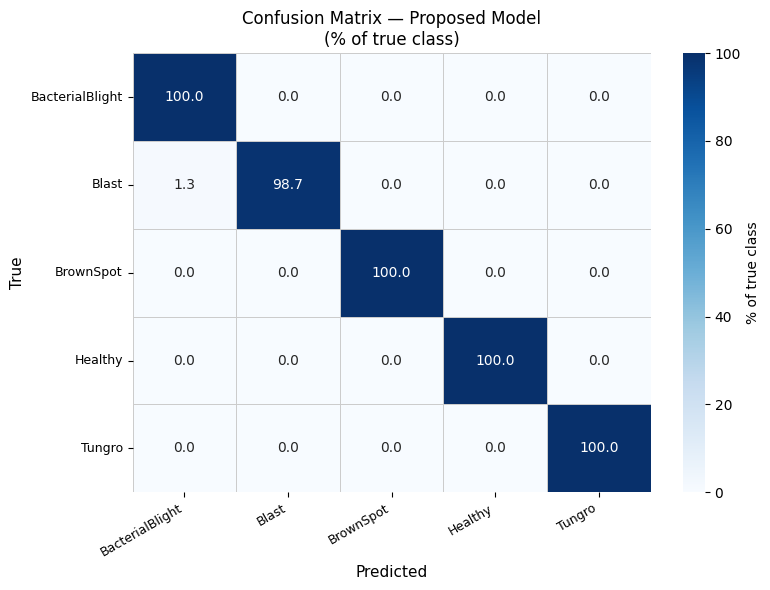

✅ Confusion matrix saved → /content/drive/MyDrive/Results/RiceDT/confusion_matrix.png

RiceDT — Confusion Matrix
[[83  0  0  0  0]
 [ 1 78  0  0  0]
 [ 0  0 69  0  0]
 [ 0  0  0 98  0]
 [ 0  0  0  0 98]]


In [ ]:
# ==========================================================
# Experiment 6 — RiceDT
# Part 7 — Confusion Matrix
# ==========================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os


# ==========================================================
# Confusion Matrix
# ==========================================================

cm_ricedt = confusion_matrix(
    test_labels_ricedt,
    test_preds_ricedt
)


# ==========================================================
# Convert to Percentage
# ==========================================================

cm_ricedt_pct = (
    cm_ricedt.astype(float)
    / cm_ricedt.sum(axis=1, keepdims=True)
    * 100
)


# ==========================================================
# Plot
# ==========================================================

fig, ax = plt.subplots(
    figsize=(8, 6)
)


sns.heatmap(
    cm_ricedt_pct,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    xticklabels=classes_ricedt,
    yticklabels=classes_ricedt,
    ax=ax,
    linewidths=0.5,
    linecolor="#cccccc",
    cbar_kws={
        "label": "% of true class"
    }
)


ax.set_xlabel(
    "Predicted",
    fontsize=11
)

ax.set_ylabel(
    "True",
    fontsize=11
)

ax.set_title(
    "Confusion Matrix — Proposed Model\n(% of true class)",
    fontsize=12
)


plt.xticks(
    rotation=30,
    ha="right",
    fontsize=9
)

plt.yticks(
    rotation=0,
    fontsize=9
)


plt.tight_layout()


# ==========================================================
# Save
# ==========================================================

CM_PATH = os.path.join(
    OUTPUT_DIR_RICEDT,
    "confusion_matrix.png"
)


plt.savefig(
    CM_PATH,
    dpi=150,
    bbox_inches="tight"
)


plt.show()


print(
    f"✅ Confusion matrix saved → {CM_PATH}"
)


# ==========================================================
# Print Raw Confusion Matrix
# ==========================================================

print("\n" + "=" * 65)
print("RiceDT — Confusion Matrix")
print("=" * 65)

print(
    cm_ricedt
)

print("=" * 65)

In [ ]:
# ==========================================================
# Experiment 6 — RiceDT
# Part 8 — Complexity Analysis
# ==========================================================

# Install THOP if necessary
!pip install -q thop


# ==========================================================
# Imports
# ==========================================================

import torch
import torch.nn as nn
import time
import os

from thop import profile


# ==========================================================
# Make Sure Best RiceDT Model Is Loaded
# ==========================================================

MODEL_PATH_RICEDT = os.path.join(
    OUTPUT_DIR_RICEDT,
    "best_model.pth"
)

model_ricedt.load_state_dict(
    torch.load(
        MODEL_PATH_RICEDT,
        map_location=DEVICE
    )
)

model_ricedt = model_ricedt.to(
    DEVICE
)

model_ricedt.eval()


# ==========================================================
# Parameter Count
# ==========================================================

total_params = sum(
    p.numel()
    for p in model_ricedt.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model_ricedt.parameters()
    if p.requires_grad
)


# ==========================================================
# Model Size
# ==========================================================

model_size_mb = (
    total_params * 4
    / (1024 ** 2)
)


# ==========================================================
# Dummy Input
# ==========================================================

dummy_input = torch.randn(
    1,
    3,
    224,
    224,
    device=DEVICE
)


# ==========================================================
# MACs and FLOPs
# ==========================================================

model_ricedt.eval()

with torch.no_grad():

    macs, params = profile(
        model_ricedt,
        inputs=(dummy_input,),
        verbose=False
    )


flops = macs * 2


# ==========================================================
# GPU Memory Measurement
# ==========================================================

if torch.cuda.is_available():

    torch.cuda.empty_cache()

    torch.cuda.reset_peak_memory_stats(
        DEVICE
    )

    # Warm-up
    with torch.no_grad():

        for _ in range(20):

            _ = model_ricedt(
                dummy_input
            )

    torch.cuda.synchronize(
        DEVICE
    )

    torch.cuda.reset_peak_memory_stats(
        DEVICE
    )

else:

    print(
        "⚠️ CUDA is not available."
    )


# ==========================================================
# Inference Timing
# ==========================================================

NUM_TIMING_RUNS = 100

times = []


if torch.cuda.is_available():

    for _ in range(NUM_TIMING_RUNS):

        torch.cuda.synchronize(
            DEVICE
        )

        start = time.perf_counter()

        with torch.no_grad():

            _ = model_ricedt(
                dummy_input
            )

        torch.cuda.synchronize(
            DEVICE
        )

        end = time.perf_counter()

        times.append(
            (end - start) * 1000
        )

else:

    for _ in range(NUM_TIMING_RUNS):

        start = time.perf_counter()

        with torch.no_grad():

            _ = model_ricedt(
                dummy_input
            )

        end = time.perf_counter()

        times.append(
            (end - start) * 1000
        )


# ==========================================================
# Timing Statistics
# ==========================================================

avg_inference_ms = sum(times) / len(times)

fps = (
    1000.0
    / avg_inference_ms
)


# ==========================================================
# Peak GPU Memory
# ==========================================================

if torch.cuda.is_available():

    peak_memory_mb = (
        torch.cuda.max_memory_allocated(
            DEVICE
        )
        / (1024 ** 2)
    )

else:

    peak_memory_mb = 0.0


# ==========================================================
# Model Depth
# ==========================================================

model_depth = sum(
    1
    for _ in model_ricedt.modules()
)


# ==========================================================
# Print Final Results
# ==========================================================

print("\n" + "=" * 65)
print("RiceDT Complexity Analysis")
print("=" * 65)

print(
    f"Total Parameters      : "
    f"{total_params:,}"
)

print(
    f"Trainable Parameters  : "
    f"{trainable_params:,}"
)

print("-" * 65)

print(
    f"MACs                  : "
    f"{macs / 1e6:.2f} M"
)

print(
    f"FLOPs                 : "
    f"{flops / 1e6:.2f} M"
)

print("-" * 65)

print(
    f"Peak GPU Memory       : "
    f"{peak_memory_mb:.2f} MB"
)

print(
    f"Average Inference     : "
    f"{avg_inference_ms:.2f} ms/image"
)

print(
    f"Images Per Second     : "
    f"{fps:.2f} FPS"
)

print("-" * 65)

print(
    f"Model Depth           : "
    f"{model_depth}"
)

print(
    f"Model Size            : "
    f"{model_size_mb:.2f} MB"
)

print("=" * 65)


# ==========================================================
# Save Complexity Information
# ==========================================================

complexity_info_ricedt = {

    "model":
        "RiceDT",

    "input_shape":
        [1, 3, 224, 224],

    "total_parameters":
        total_params,

    "trainable_parameters":
        trainable_params,

    "macs":
        round(
            macs,
            2
        ),

    "macs_m":
        round(
            macs / 1e6,
            4
        ),

    "flops":
        round(
            flops,
            2
        ),

    "flops_m":
        round(
            flops / 1e6,
            4
        ),

    "peak_gpu_memory_mb":
        round(
            peak_memory_mb,
            4
        ),

    "average_inference_ms":
        round(
            avg_inference_ms,
            4
        ),

    "fps":
        round(
            fps,
            4
        ),

    "model_depth":
        model_depth,

    "model_size_mb_fp32":
        round(
            model_size_mb,
            4
        )

}


COMPLEXITY_PATH = os.path.join(
    OUTPUT_DIR_RICEDT,
    "complexity_info.json"
)


with open(
    COMPLEXITY_PATH,
    "w"
) as f:

    json.dump(
        complexity_info_ricedt,
        f,
        indent=2
    )


print(
    f"\n✅ Complexity information saved → "
    f"{COMPLEXITY_PATH}"
)


RiceDT Complexity Analysis
Total Parameters      : 220,165
Trainable Parameters  : 220,165
-----------------------------------------------------------------
MACs                  : 83.61 M
FLOPs                 : 167.22 M
-----------------------------------------------------------------
Peak GPU Memory       : 27.05 MB
Average Inference     : 2.60 ms/image
Images Per Second     : 384.28 FPS
-----------------------------------------------------------------
Model Depth           : 82
Model Size            : 0.84 MB

✅ Complexity information saved → /content/drive/MyDrive/Results/RiceDT/complexity_info.json


In [ ]:
# ==========================================================
# Experiment 6 — RiceDT
# Part 9 — Final Model Information
# ==========================================================

import json
import os


# ==========================================================
# Make Sure Required Variables Exist
# ==========================================================

# If complexity analysis was already run, these variables
# contain the measured values.

final_model_info_ricedt = {

    # ------------------------------------------------------
    # Model
    # ------------------------------------------------------

    "model":
        "RiceDT",

    "architecture":
        "Custom Lightweight CNN",

    "input_size":
        "224x224",

    "num_classes":
        NUM_CLASSES,

    "classes":
        classes_ricedt,


    # ------------------------------------------------------
    # Architecture Components
    # ------------------------------------------------------

    "components": [

        "Depthwise-Separable Convolution",

        "Squeeze-and-Excitation Attention",

        "Residual Skip Connections",

        "HardSwish Activation",

        "Global Average Pooling"

    ],


    # ------------------------------------------------------
    # Training
    # ------------------------------------------------------

    "epochs":
        RICEDT_EPOCHS,

    "warmup_epochs":
        RICEDT_WARMUP_EPOCHS,

    "optimizer":
        "AdamW",

    "scheduler":
        "CosineAnnealingLR",

    "learning_rate_max":
        RICEDT_MAX_LR,

    "learning_rate_min":
        RICEDT_MIN_LR,

    "weight_decay":
        RICEDT_WEIGHT_DECAY,

    "label_smoothing":
        RICEDT_LABEL_SMOOTHING,

    "dropout":
        RICEDT_DROPOUT,

    "batch_size":
        BATCH_SIZE,

    "training_strategy":
        "From Scratch",


    # ------------------------------------------------------
    # Accuracy
    # ------------------------------------------------------

    "best_validation_accuracy":
        round(
            best_acc_ricedt,
            4
        ),

    "test_accuracy":
        round(
            test_acc_ricedt,
            4
        ),

    "test_loss":
        round(
            test_loss_ricedt,
            6
        ),


    # ------------------------------------------------------
    # Parameters
    # ------------------------------------------------------

    "total_parameters":
        total_params,

    "trainable_parameters":
        trainable_params,

    "parameters_million":
        round(
            total_params / 1e6,
            6
        ),


    # ------------------------------------------------------
    # Model Size
    # ------------------------------------------------------

    "model_size_mb_fp32":
        round(
            model_size_mb,
            4
        ),


    # ------------------------------------------------------
    # Computational Complexity
    # ------------------------------------------------------

    "macs":
        round(
            macs,
            2
        ),

    "macs_million":
        round(
            macs / 1e6,
            4
        ),

    "flops":
        round(
            flops,
            2
        ),

    "flops_million":
        round(
            flops / 1e6,
            4
        ),


    # ------------------------------------------------------
    # Runtime Performance
    # ------------------------------------------------------

    "peak_gpu_memory_mb":
        round(
            peak_memory_mb,
            4
        ),

    "average_inference_ms":
        round(
            avg_inference_ms,
            4
        ),

    "fps":
        round(
            fps,
            4
        ),

    "model_depth":
        model_depth,


    # ------------------------------------------------------
    # Hardware / Profiling
    # ------------------------------------------------------

    "device":
        str(DEVICE),

    "profiling_input":
        [
            1,
            3,
            224,
            224
        ],

    "profiling_framework":
        "PyTorch + THOP",

    "flops_definition":
        "FLOPs = 2 × MACs",


    # ------------------------------------------------------
    # Files
    # ------------------------------------------------------

    "files": {

        "best_model":
            "best_model.pth",

        "last_model":
            "last_model.pth",

        "training_history":
            "training_history.json",

        "training_curves":
            "training_curves.png",

        "confusion_matrix":
            "confusion_matrix.png",

        "classification_report":
            "classification_report.txt",

        "test_results":
            "test_results.json",

        "complexity_info":
            "complexity_info.json"

    }

}


# ==========================================================
# Save
# ==========================================================

MODEL_INFO_PATH = os.path.join(

    OUTPUT_DIR_RICEDT,

    "model_info.json"

)


with open(
    MODEL_INFO_PATH,
    "w"
) as f:

    json.dump(
        final_model_info_ricedt,
        f,
        indent=4
    )


# ==========================================================
# Print Summary
# ==========================================================

print("=" * 70)
print("RiceDT — Final Model Information")
print("=" * 70)

print(
    f"Test Accuracy      : "
    f"{test_acc_ricedt:.2f}%"
)

print(
    f"Parameters         : "
    f"{total_params:,}"
)

print(
    f"Model Size         : "
    f"{model_size_mb:.2f} MB"
)

print(
    f"MACs               : "
    f"{macs / 1e6:.2f} M"
)

print(
    f"FLOPs              : "
    f"{flops / 1e6:.2f} M"
)

print(
    f"Peak GPU Memory    : "
    f"{peak_memory_mb:.2f} MB"
)

print(
    f"Inference          : "
    f"{avg_inference_ms:.2f} ms"
)

print(
    f"FPS                : "
    f"{fps:.2f}"
)

print(
    f"Depth              : "
    f"{model_depth}"
)

print("=" * 70)

print(
    f"\n✅ Complete model information saved:"
)

print(
    MODEL_INFO_PATH
)

RiceDT — Final Model Information
Test Accuracy      : 99.77%
Parameters         : 220,165
Model Size         : 0.84 MB
MACs               : 83.61 M
FLOPs              : 167.22 M
Peak GPU Memory    : 27.05 MB
Inference          : 2.60 ms
FPS                : 384.28
Depth              : 82

✅ Complete model information saved:
/content/drive/MyDrive/Results/RiceDT/model_info.json


In [ ]:
# ==========================================================
# Experiment 7 — GhostNet
# Part 1 — Model Setup & Architecture
# ==========================================================

# ==========================================================
# Install timm
# ==========================================================

!pip install -q timm


# ==========================================================
# Imports
# ==========================================================

import torch
import torch.nn as nn
import timm
import os
import json
import copy
import time


# ==========================================================
# Configuration
# ==========================================================

GHOSTNET_NUM_CLASSES = NUM_CLASSES

GHOSTNET_DROPOUT = 0.2

GHOSTNET_OUTPUT_DIR = (
    "/content/drive/MyDrive/Results/GhostNet"
)

os.makedirs(
    GHOSTNET_OUTPUT_DIR,
    exist_ok=True
)


# ==========================================================
# Create GhostNet
# ==========================================================

model_ghostnet = timm.create_model(

    "ghostnet_100",

    pretrained=True,

    num_classes=GHOSTNET_NUM_CLASSES,

    drop_rate=GHOSTNET_DROPOUT

)


# ==========================================================
# Move to GPU
# ==========================================================

model_ghostnet = model_ghostnet.to(
    DEVICE
)


# ==========================================================
# Parameter Count
# ==========================================================

total_params_ghostnet = sum(
    p.numel()
    for p in model_ghostnet.parameters()
)

trainable_params_ghostnet = sum(
    p.numel()
    for p in model_ghostnet.parameters()
    if p.requires_grad
)


# ==========================================================
# Model Size
# ==========================================================

model_size_ghostnet = (

    total_params_ghostnet
    * 4
    / (1024 ** 2)

)


# ==========================================================
# Print Model Information
# ==========================================================

print("=" * 70)
print("GhostNet — Model Verification")
print("=" * 70)

print(
    f"Total Parameters     : "
    f"{total_params_ghostnet:,}"
)

print(
    f"Trainable Parameters : "
    f"{trainable_params_ghostnet:,}"
)

print(
    f"Model Size (FP32)    : "
    f"{model_size_ghostnet:.2f} MB"
)

print(
    f"Device               : "
    f"{DEVICE}"
)

print("=" * 70)


# ==========================================================
# Forward Pass Test
# ==========================================================

dummy_input_ghostnet = torch.randn(

    2,
    3,
    224,
    224

).to(DEVICE)


model_ghostnet.eval()


with torch.no_grad():

    dummy_output_ghostnet = (
        model_ghostnet(
            dummy_input_ghostnet
        )
    )


print("\nForward Pass Verification")
print("-" * 70)

print(
    f"Input Shape  : "
    f"{tuple(dummy_input_ghostnet.shape)}"
)

print(
    f"Output Shape : "
    f"{tuple(dummy_output_ghostnet.shape)}"
)

print(
    f"Expected     : "
    f"(2, {NUM_CLASSES})"
)


# ==========================================================
# Verify Output
# ==========================================================

assert dummy_output_ghostnet.shape == (

    2,
    NUM_CLASSES

)


print(
    "\n✅ GhostNet forward pass successful."
)

print(
    "✅ Input/output dimensions are correct."
)

print(
    "✅ GhostNet is ready for training."
)

print("=" * 70)

model.safetensors: reconstructing file:   0%|          |  0.00B / 20.9MB            

model.safetensors: downloading bytes:           |  0.00B            

GhostNet — Model Verification
Total Parameters     : 3,907,913
Trainable Parameters : 3,907,913
Model Size (FP32)    : 14.91 MB
Device               : cuda

Forward Pass Verification
----------------------------------------------------------------------
Input Shape  : (2, 3, 224, 224)
Output Shape : (2, 5)
Expected     : (2, 5)

✅ GhostNet forward pass successful.
✅ Input/output dimensions are correct.
✅ GhostNet is ready for training.


In [ ]:
# ==========================================================
# Experiment 7 — GhostNet
# Part 2 — Training Configuration
# ==========================================================

# ==========================================================
# Training Configuration
# ==========================================================

GHOSTNET_EPOCHS = 30

GHOSTNET_PHASE_A_EPOCHS = 10

GHOSTNET_PHASE_B_EPOCHS = 20

GHOSTNET_LR_PHASE_A = 1e-4

GHOSTNET_LR_PHASE_B = 1e-5

GHOSTNET_WEIGHT_DECAY = WEIGHT_DECAY

GHOSTNET_LABEL_SMOOTHING = 0.1


# ==========================================================
# Output Directory
# ==========================================================

GHOSTNET_OUTPUT_DIR = (
    "/content/drive/MyDrive/Results/GhostNet"
)

os.makedirs(
    GHOSTNET_OUTPUT_DIR,
    exist_ok=True
)


# ==========================================================
# Loss Function
# ==========================================================

criterion_ghostnet = nn.CrossEntropyLoss(
    label_smoothing=GHOSTNET_LABEL_SMOOTHING
)


# ==========================================================
# Phase A — Frozen Backbone
# ==========================================================

for param in model_ghostnet.parameters():
    param.requires_grad = False


# Find classifier
classifier_params = []

for name, param in model_ghostnet.named_parameters():

    if (
        "classifier" in name
        or "head" in name
    ):

        param.requires_grad = True

        classifier_params.append(param)


# ==========================================================
# Optimizer — Phase A
# ==========================================================

optimizer_ghostnet = torch.optim.AdamW(

    filter(
        lambda p: p.requires_grad,
        model_ghostnet.parameters()
    ),

    lr=GHOSTNET_LR_PHASE_A,

    weight_decay=GHOSTNET_WEIGHT_DECAY

)


# ==========================================================
# Scheduler — Phase A
# ==========================================================

scheduler_ghostnet = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer_ghostnet,

    mode="min",

    factor=0.5,

    patience=5,

    min_lr=1e-7

)


# ==========================================================
# Print Configuration
# ==========================================================

phase_a_trainable = sum(

    p.numel()

    for p in model_ghostnet.parameters()

    if p.requires_grad

)


print("=" * 70)
print("GhostNet — Training Configuration")
print("=" * 70)

print(
    f"Phase A Epochs       : "
    f"1–{GHOSTNET_PHASE_A_EPOCHS}"
)

print(
    f"Phase B Epochs       : "
    f"{GHOSTNET_PHASE_A_EPOCHS + 1}–"
    f"{GHOSTNET_EPOCHS}"
)

print(
    f"Phase A Learning Rate: "
    f"{GHOSTNET_LR_PHASE_A:.2e}"
)

print(
    f"Phase B Learning Rate: "
    f"{GHOSTNET_LR_PHASE_B:.2e}"
)

print(
    f"Weight Decay         : "
    f"{GHOSTNET_WEIGHT_DECAY:.2e}"
)

print(
    f"Label Smoothing      : "
    f"{GHOSTNET_LABEL_SMOOTHING}"
)

print(
    f"Batch Size           : "
    f"{BATCH_SIZE}"
)

print(
    f"Optimizer            : "
    f"AdamW"
)

print(
    f"Scheduler             : "
    f"ReduceLROnPlateau"
)

print(
    f"Phase A Trainable    : "
    f"{phase_a_trainable:,}"
)

print(
    f"Device               : "
    f"{DEVICE}"
)

print("=" * 70)

print(
    "\n✅ GhostNet training configuration ready."
)

GhostNet — Training Configuration
Phase A Epochs       : 1–10
Phase B Epochs       : 11–30
Phase A Learning Rate: 1.00e-04
Phase B Learning Rate: 1.00e-05
Weight Decay         : 1.00e-04
Label Smoothing      : 0.1
Batch Size           : 32
Optimizer            : AdamW
Scheduler             : ReduceLROnPlateau
Phase A Trainable    : 1,236,485
Device               : cuda

✅ GhostNet training configuration ready.


In [ ]:
# ==========================================================
# Experiment 7 — GhostNet
# Part 3 — Training Loop
# ==========================================================

# ==========================================================
# Training Function
# ==========================================================

def train_one_epoch_ghostnet(
    model,
    loader,
    criterion,
    optimizer
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item()
            * images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += images.size(0)

    epoch_loss = (
        running_loss / total
    )

    epoch_acc = (
        100.0 * correct / total
    )

    return epoch_loss, epoch_acc


# ==========================================================
# Evaluation Function
# ==========================================================

@torch.no_grad()
def evaluate_ghostnet(
    model,
    loader,
    criterion
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_predictions = []
    all_labels = []

    for images, labels in loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        running_loss += (
            loss.item()
            * images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += images.size(0)

        all_predictions.extend(
            predictions.cpu().tolist()
        )

        all_labels.extend(
            labels.cpu().tolist()
        )

    epoch_loss = (
        running_loss / total
    )

    epoch_acc = (
        100.0 * correct / total
    )

    return (
        epoch_loss,
        epoch_acc,
        all_predictions,
        all_labels
    )


# ==========================================================
# Training History
# ==========================================================

history_ghostnet = []

best_acc_ghostnet = 0.0

best_wts_ghostnet = copy.deepcopy(
    model_ghostnet.state_dict()
)


# ==========================================================
# Training Start
# ==========================================================

print("=" * 75)
print("Training — GhostNet")
print("=" * 75)

print(
    f"Phase A : Epochs 1–"
    f"{GHOSTNET_PHASE_A_EPOCHS} "
    f"(classifier training, "
    f"LR={GHOSTNET_LR_PHASE_A})"
)

print(
    f"Phase B : Epochs "
    f"{GHOSTNET_PHASE_A_EPOCHS + 1}–"
    f"{GHOSTNET_EPOCHS} "
    f"(fine-tuning, "
    f"LR={GHOSTNET_LR_PHASE_B})"
)

print("=" * 75)

print(
    f"\n{'Epoch':>5} "
    f"{'Phase':>7} "
    f"{'Tr Loss':>10} "
    f"{'Tr Acc':>9} "
    f"{'Va Loss':>10} "
    f"{'Va Acc':>9} "
    f"{'LR':>11} "
    f"{'Time':>7}"
)

print("-" * 75)


# ==========================================================
# Epoch Loop
# ==========================================================

for epoch in range(
    1,
    GHOSTNET_EPOCHS + 1
):

    epoch_start = time.time()


    # ======================================================
    # Phase B Switch
    # ======================================================

    if epoch == (
        GHOSTNET_PHASE_A_EPOCHS + 1
    ):

        print("\n" + "-" * 75)

        print(
            "Switching to Phase B — "
            "fine-tuning GhostNet backbone"
        )


        # --------------------------------------------------
        # Unfreeze Entire Backbone
        # --------------------------------------------------

        for param in model_ghostnet.parameters():

            param.requires_grad = True


        # --------------------------------------------------
        # Count Trainable Parameters
        # --------------------------------------------------

        trainable_now = sum(

            p.numel()

            for p in model_ghostnet.parameters()

            if p.requires_grad

        )


        print(
            f"Trainable parameters: "
            f"{trainable_now:,}"
        )


        # --------------------------------------------------
        # New Optimizer
        # --------------------------------------------------

        optimizer_ghostnet = torch.optim.AdamW(

            filter(
                lambda p: p.requires_grad,
                model_ghostnet.parameters()
            ),

            lr=GHOSTNET_LR_PHASE_B,

            weight_decay=GHOSTNET_WEIGHT_DECAY

        )


        # --------------------------------------------------
        # New Scheduler
        # --------------------------------------------------

        scheduler_ghostnet = (
            torch.optim.lr_scheduler
            .ReduceLROnPlateau(

                optimizer_ghostnet,

                mode="min",

                factor=0.5,

                patience=5,

                min_lr=1e-7

            )
        )


        print("-" * 75 + "\n")


    # ======================================================
    # Current Phase
    # ======================================================

    phase = (

        "A"
        if epoch <= GHOSTNET_PHASE_A_EPOCHS
        else "B"

    )


    # ======================================================
    # Train
    # ======================================================

    train_loss, train_acc = (
        train_one_epoch_ghostnet(

            model_ghostnet,

            train_loader,

            criterion_ghostnet,

            optimizer_ghostnet

        )
    )


    # ======================================================
    # Validate
    # ======================================================

    val_loss, val_acc, _, _ = (
        evaluate_ghostnet(

            model_ghostnet,

            val_loader,

            criterion_ghostnet

        )
    )


    # ======================================================
    # Scheduler
    # ======================================================

    scheduler_ghostnet.step(
        val_loss
    )


    # ======================================================
    # Current LR
    # ======================================================

    current_lr = (
        optimizer_ghostnet
        .param_groups[0]["lr"]
    )


    # ======================================================
    # Epoch Time
    # ======================================================

    elapsed = (
        time.time()
        - epoch_start
    )


    # ======================================================
    # Print
    # ======================================================

    print(

        f"{epoch:>5} "
        f"{phase:>7} "
        f"{train_loss:>10.4f} "
        f"{train_acc:>8.2f}% "
        f"{val_loss:>10.4f} "
        f"{val_acc:>8.2f}% "
        f"{current_lr:>11.2e} "
        f"{elapsed:>6.0f}s"

    )


    # ======================================================
    # Save History
    # ======================================================

    history_ghostnet.append({

        "epoch":
            epoch,

        "phase":
            phase,

        "train_loss":
            round(
                train_loss,
                6
            ),

        "train_acc":
            round(
                train_acc,
                4
            ),

        "val_loss":
            round(
                val_loss,
                6
            ),

        "val_acc":
            round(
                val_acc,
                4
            ),

        "lr":
            current_lr

    })


    # ======================================================
    # Save Best Model
    # ======================================================

    if val_acc > best_acc_ghostnet:

        best_acc_ghostnet = val_acc

        best_wts_ghostnet = (
            copy.deepcopy(
                model_ghostnet.state_dict()
            )
        )


        torch.save(

            best_wts_ghostnet,

            os.path.join(
                GHOSTNET_OUTPUT_DIR,
                "best_model.pth"
            )

        )


# ==========================================================
# Save Last Model
# ==========================================================

torch.save(

    model_ghostnet.state_dict(),

    os.path.join(
        GHOSTNET_OUTPUT_DIR,
        "last_model.pth"
    )

)


# ==========================================================
# Save Training History
# ==========================================================

with open(

    os.path.join(
        GHOSTNET_OUTPUT_DIR,
        "training_history.json"
    ),

    "w"

) as f:

    json.dump(
        history_ghostnet,
        f,
        indent=2
    )


# ==========================================================
# Complete
# ==========================================================

print("\n" + "=" * 75)

print(
    "Training complete."
)

print(
    f"Best Val Accuracy : "
    f"{best_acc_ghostnet:.2f}%"
)

print(
    f"Saved to          : "
    f"{GHOSTNET_OUTPUT_DIR}"
)

print("=" * 75)

Training — GhostNet
Phase A : Epochs 1–10 (classifier training, LR=0.0001)
Phase B : Epochs 11–30 (fine-tuning, LR=1e-05)

Epoch   Phase    Tr Loss    Tr Acc    Va Loss    Va Acc          LR    Time
---------------------------------------------------------------------------
    1       A     1.2974    61.22%     1.2444    58.71%    1.00e-04    482s
    2       A     0.9148    80.19%     0.9000    79.00%    1.00e-04     99s
    3       A     0.7599    84.82%     0.7514    85.92%    1.00e-04    100s
    4       A     0.6898    87.56%     0.6917    88.54%    1.00e-04     99s
    5       A     0.6721    88.80%     0.6558    91.41%    1.00e-04    101s
    6       A     0.6316    91.21%     0.6141    92.12%    1.00e-04    100s
    7       A     0.6098    92.52%     0.5860    93.32%    1.00e-04    102s
    8       A     0.5966    93.43%     0.5812    94.27%    1.00e-04    103s
    9       A     0.5856    92.85%     0.5644    94.51%    1.00e-04    104s
   10       A     0.5777    94.24%     0.

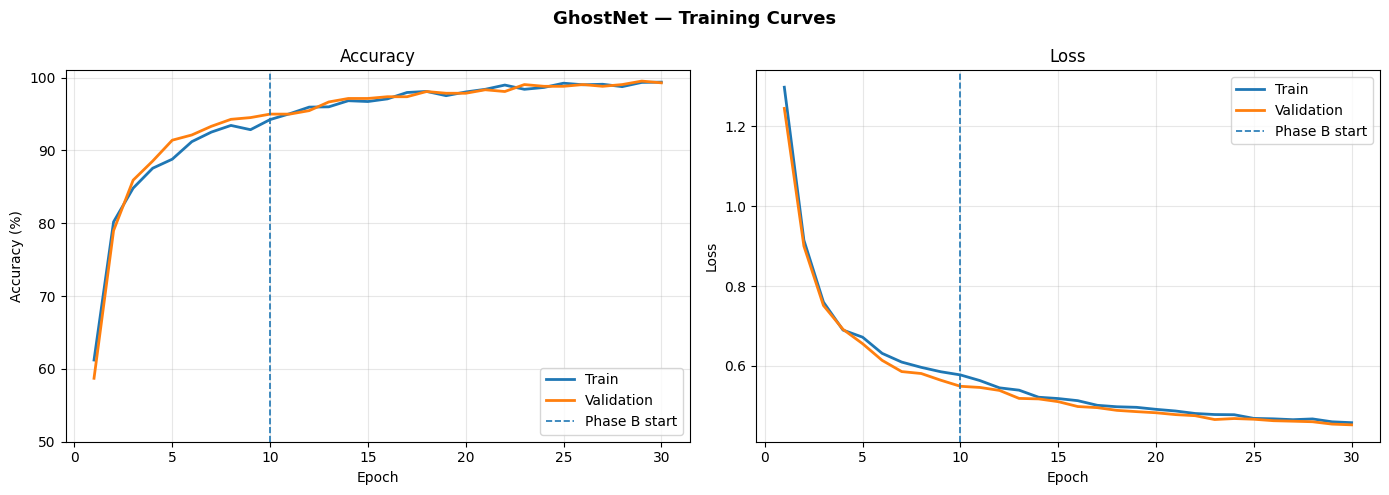

✅ GhostNet training curves saved → /content/drive/MyDrive/Results/GhostNet/training_curves.png


In [ ]:
# ==========================================================
# Experiment 7 — GhostNet
# Part 4 — Training Curves
# ==========================================================

import matplotlib.pyplot as plt


# ==========================================================
# Extract History
# ==========================================================

epochs_ghostnet = [
    h["epoch"]
    for h in history_ghostnet
]

train_acc_ghostnet = [
    h["train_acc"]
    for h in history_ghostnet
]

val_acc_ghostnet = [
    h["val_acc"]
    for h in history_ghostnet
]

train_loss_ghostnet = [
    h["train_loss"]
    for h in history_ghostnet
]

val_loss_ghostnet = [
    h["val_loss"]
    for h in history_ghostnet
]


# ==========================================================
# Create Figure
# ==========================================================

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

fig.suptitle(
    "GhostNet — Training Curves",
    fontsize=13,
    fontweight="bold"
)


# ==========================================================
# Accuracy
# ==========================================================

ax1.plot(
    epochs_ghostnet,
    train_acc_ghostnet,
    label="Train",
    linewidth=2
)

ax1.plot(
    epochs_ghostnet,
    val_acc_ghostnet,
    label="Validation",
    linewidth=2
)

ax1.axvline(
    GHOSTNET_PHASE_A_EPOCHS,
    linestyle="--",
    linewidth=1.2,
    label="Phase B start"
)

ax1.set_xlabel(
    "Epoch"
)

ax1.set_ylabel(
    "Accuracy (%)"
)

ax1.set_title(
    "Accuracy"
)

ax1.legend()

ax1.grid(
    alpha=0.3
)

ax1.set_ylim(
    [50, 101]
)


# ==========================================================
# Loss
# ==========================================================

ax2.plot(
    epochs_ghostnet,
    train_loss_ghostnet,
    label="Train",
    linewidth=2
)

ax2.plot(
    epochs_ghostnet,
    val_loss_ghostnet,
    label="Validation",
    linewidth=2
)

ax2.axvline(
    GHOSTNET_PHASE_A_EPOCHS,
    linestyle="--",
    linewidth=1.2,
    label="Phase B start"
)

ax2.set_xlabel(
    "Epoch"
)

ax2.set_ylabel(
    "Loss"
)

ax2.set_title(
    "Loss"
)

ax2.legend()

ax2.grid(
    alpha=0.3
)


# ==========================================================
# Layout
# ==========================================================

plt.tight_layout()


# ==========================================================
# Save
# ==========================================================

GHOSTNET_CURVE_PATH = os.path.join(
    GHOSTNET_OUTPUT_DIR,
    "training_curves.png"
)

plt.savefig(
    GHOSTNET_CURVE_PATH,
    dpi=150,
    bbox_inches="tight"
)

plt.show()


print(
    f"✅ GhostNet training curves saved → "
    f"{GHOSTNET_CURVE_PATH}"
)

In [ ]:
# ==========================================================
# Experiment 7 — GhostNet
# Part 5 — Final Test Set Evaluation
# ==========================================================

from sklearn.metrics import classification_report
import os
import json


# ==========================================================
# Load Best GhostNet Model
# ==========================================================

GHOSTNET_BEST_PATH = os.path.join(
    GHOSTNET_OUTPUT_DIR,
    "best_model.pth"
)

print("=" * 65)
print("Loading best GhostNet model...")
print("=" * 65)

model_ghostnet.load_state_dict(
    torch.load(
        GHOSTNET_BEST_PATH,
        map_location=DEVICE
    )
)

model_ghostnet = model_ghostnet.to(
    DEVICE
)

model_ghostnet.eval()


# ==========================================================
# Evaluate Test Set
# ==========================================================

test_loss_ghostnet, test_acc_ghostnet, \
test_preds_ghostnet, test_labels_ghostnet = evaluate_ghostnet(

    model_ghostnet,

    test_loader,

    criterion_ghostnet

)


# ==========================================================
# Print Test Results
# ==========================================================

print("\n" + "=" * 65)
print("GhostNet — Test Set Results")
print("=" * 65)

print(
    f"Test Loss     : "
    f"{test_loss_ghostnet:.4f}"
)

print(
    f"Test Accuracy : "
    f"{test_acc_ghostnet:.2f}%"
)

print("=" * 65)


# ==========================================================
# Classification Report
# ==========================================================

classes_ghostnet = train_dataset.classes

report_ghostnet = classification_report(

    test_labels_ghostnet,

    test_preds_ghostnet,

    target_names=classes_ghostnet,

    digits=4

)


print("\n" + "=" * 65)
print("Classification Report — GhostNet")
print("=" * 65)

print(
    report_ghostnet
)


# ==========================================================
# Save Classification Report
# ==========================================================

GHOSTNET_REPORT_PATH = os.path.join(
    GHOSTNET_OUTPUT_DIR,
    "classification_report.txt"
)

with open(
    GHOSTNET_REPORT_PATH,
    "w"
) as f:

    f.write(
        "GhostNet — Classification Report\n"
    )

    f.write(
        "=" * 65 + "\n"
    )

    f.write(
        report_ghostnet
    )


print(
    f"\n✅ Classification report saved → "
    f"{GHOSTNET_REPORT_PATH}"
)


# ==========================================================
# Save Test Results
# ==========================================================

ghostnet_test_results = {

    "model":
        "GhostNet",

    "test_loss":
        round(
            test_loss_ghostnet,
            6
        ),

    "test_accuracy":
        round(
            test_acc_ghostnet,
            4
        ),

    "best_validation_accuracy":
        round(
            best_acc_ghostnet,
            4
        ),

    "total_parameters":
        total_params_ghostnet,

    "model_size_mb":
        round(
            model_size_ghostnet,
            4
        ),

    "num_classes":
        GHOSTNET_NUM_CLASSES,

    "classes":
        classes_ghostnet

}


GHOSTNET_TEST_PATH = os.path.join(
    GHOSTNET_OUTPUT_DIR,
    "test_results.json"
)


with open(
    GHOSTNET_TEST_PATH,
    "w"
) as f:

    json.dump(
        ghostnet_test_results,
        f,
        indent=4
    )


print(
    f"✅ Test results saved → "
    f"{GHOSTNET_TEST_PATH}"
)


print("\n" + "=" * 65)
print("GhostNet test evaluation complete.")
print("=" * 65)

Loading best GhostNet model...

GhostNet — Test Set Results
Test Loss     : 0.4507
Test Accuracy : 99.77%

Classification Report — GhostNet
                 precision    recall  f1-score   support

BacterialBlight     1.0000    1.0000    1.0000        83
          Blast     1.0000    1.0000    1.0000        79
      BrownSpot     1.0000    1.0000    1.0000        69
        Healthy     0.9899    1.0000    0.9949        98
         Tungro     1.0000    0.9898    0.9949        98

       accuracy                         0.9977       427
      macro avg     0.9980    0.9980    0.9980       427
   weighted avg     0.9977    0.9977    0.9977       427


✅ Classification report saved → /content/drive/MyDrive/Results/GhostNet/classification_report.txt
✅ Test results saved → /content/drive/MyDrive/Results/GhostNet/test_results.json

GhostNet test evaluation complete.


In [ ]:
# ==========================================================
# Experiment 7 — GhostNet
# Part 6 — Complexity Analysis
# ==========================================================

!pip install -q thop


import torch
import time
import json
import os

from thop import profile


# ==========================================================
# Load Best Model
# ==========================================================

GHOSTNET_BEST_PATH = os.path.join(
    GHOSTNET_OUTPUT_DIR,
    "best_model.pth"
)

model_ghostnet.load_state_dict(
    torch.load(
        GHOSTNET_BEST_PATH,
        map_location=DEVICE
    )
)

model_ghostnet = model_ghostnet.to(
    DEVICE
)

model_ghostnet.eval()


# ==========================================================
# Parameter Count
# ==========================================================

total_params_ghostnet = sum(
    p.numel()
    for p in model_ghostnet.parameters()
)

trainable_params_ghostnet = sum(
    p.numel()
    for p in model_ghostnet.parameters()
    if p.requires_grad
)


# ==========================================================
# FP32 Model Size
# ==========================================================

model_size_ghostnet = (
    total_params_ghostnet
    * 4
    / (1024 ** 2)
)


# ==========================================================
# Standard Input
# ==========================================================

dummy_input_ghostnet = torch.randn(
    1,
    3,
    224,
    224,
    device=DEVICE
)


# ==========================================================
# MACs and FLOPs
# ==========================================================

with torch.no_grad():

    macs_ghostnet, _ = profile(
        model_ghostnet,
        inputs=(dummy_input_ghostnet,),
        verbose=False
    )

flops_ghostnet = (
    macs_ghostnet * 2
)


# ==========================================================
# GPU Memory
# ==========================================================

if torch.cuda.is_available():

    torch.cuda.empty_cache()

    torch.cuda.reset_peak_memory_stats(
        DEVICE
    )

    # Warm-up
    with torch.no_grad():

        for _ in range(20):

            model_ghostnet(
                dummy_input_ghostnet
            )

    torch.cuda.synchronize(
        DEVICE
    )

    torch.cuda.reset_peak_memory_stats(
        DEVICE
    )

else:

    print(
        "⚠️ CUDA unavailable."
    )


# ==========================================================
# Inference Timing
# ==========================================================

NUM_RUNS_GHOSTNET = 100

timings_ghostnet = []


for _ in range(
    NUM_RUNS_GHOSTNET
):

    if torch.cuda.is_available():

        torch.cuda.synchronize(
            DEVICE
        )

    start_time = time.perf_counter()


    with torch.no_grad():

        model_ghostnet(
            dummy_input_ghostnet
        )


    if torch.cuda.is_available():

        torch.cuda.synchronize(
            DEVICE
        )

    end_time = time.perf_counter()


    timings_ghostnet.append(

        (end_time - start_time)
        * 1000

    )


# ==========================================================
# Runtime Statistics
# ==========================================================

avg_inference_ghostnet = (
    sum(timings_ghostnet)
    / len(timings_ghostnet)
)


fps_ghostnet = (
    1000
    / avg_inference_ghostnet
)


# ==========================================================
# Peak GPU Memory
# ==========================================================

if torch.cuda.is_available():

    peak_memory_ghostnet = (

        torch.cuda.max_memory_allocated(
            DEVICE
        )
        / (1024 ** 2)

    )

else:

    peak_memory_ghostnet = 0.0


# ==========================================================
# Model Depth
# ==========================================================

model_depth_ghostnet = sum(
    1
    for _ in model_ghostnet.modules()
)


# ==========================================================
# Print Results
# ==========================================================

print("\n" + "=" * 65)
print("GhostNet Complexity Analysis")
print("=" * 65)

print(
    f"Total Parameters      : "
    f"{total_params_ghostnet:,}"
)

print(
    f"Trainable Parameters  : "
    f"{trainable_params_ghostnet:,}"
)

print("-" * 65)

print(
    f"MACs                  : "
    f"{macs_ghostnet / 1e6:.2f} M"
)

print(
    f"FLOPs                 : "
    f"{flops_ghostnet / 1e6:.2f} M"
)

print("-" * 65)

print(
    f"Peak GPU Memory       : "
    f"{peak_memory_ghostnet:.2f} MB"
)

print(
    f"Average Inference     : "
    f"{avg_inference_ghostnet:.2f} ms/image"
)

print(
    f"Images Per Second     : "
    f"{fps_ghostnet:.2f} FPS"
)

print("-" * 65)

print(
    f"Model Depth           : "
    f"{model_depth_ghostnet}"
)

print(
    f"Model Size            : "
    f"{model_size_ghostnet:.2f} MB"
)

print("=" * 65)


# ==========================================================
# Save Complexity Information
# ==========================================================

ghostnet_complexity = {

    "model":
        "GhostNet",

    "input_shape":
        [1, 3, 224, 224],

    "total_parameters":
        total_params_ghostnet,

    "trainable_parameters":
        trainable_params_ghostnet,

    "macs_m":
        round(
            macs_ghostnet / 1e6,
            4
        ),

    "flops_m":
        round(
            flops_ghostnet / 1e6,
            4
        ),

    "peak_gpu_memory_mb":
        round(
            peak_memory_ghostnet,
            4
        ),

    "average_inference_ms":
        round(
            avg_inference_ghostnet,
            4
        ),

    "fps":
        round(
            fps_ghostnet,
            4
        ),

    "model_depth":
        model_depth_ghostnet,

    "model_size_mb_fp32":
        round(
            model_size_ghostnet,
            4
        )

}


GHOSTNET_COMPLEXITY_PATH = os.path.join(
    GHOSTNET_OUTPUT_DIR,
    "complexity_info.json"
)


with open(
    GHOSTNET_COMPLEXITY_PATH,
    "w"
) as f:

    json.dump(
        ghostnet_complexity,
        f,
        indent=4
    )


print(
    f"\n✅ Complexity information saved → "
    f"{GHOSTNET_COMPLEXITY_PATH}"
)


GhostNet Complexity Analysis
Total Parameters      : 3,907,913
Trainable Parameters  : 3,907,913
-----------------------------------------------------------------
MACs                  : 153.88 M
FLOPs                 : 307.77 M
-----------------------------------------------------------------
Peak GPU Memory       : 99.58 MB
Average Inference     : 18.45 ms/image
Images Per Second     : 54.19 FPS
-----------------------------------------------------------------
Model Depth           : 412
Model Size            : 14.91 MB

✅ Complexity information saved → /content/drive/MyDrive/Results/GhostNet/complexity_info.json


In [ ]:
# ==========================================================
# FINAL STANDARDIZED BENCHMARK
# Six Models — Load From Saved Checkpoints
#
# Models:
#   1. MobileNetV2
#   2. MobileNetV3-Small
#   3. MobileNetV3-Large
#   4. EfficientNet-B0
#   5. GhostNet
#   6. Proposed Model
#
# Same benchmark:
#   Input       : 1 × 3 × 224 × 224
#   Warm-up     : 30
#   Timed runs  : 100
#   Batch size  : 1
#   Device      : CUDA
# ==========================================================


# ==========================================================
# 1. Install / Import
# ==========================================================

!pip install -q thop timm

import os
import time
import copy
import json

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import timm

from torchvision.models import (
    mobilenet_v2,
    mobilenet_v3_small,
    mobilenet_v3_large,
    efficientnet_b0,
    MobileNet_V2_Weights,
    MobileNet_V3_Small_Weights,
    MobileNet_V3_Large_Weights,
    EfficientNet_B0_Weights
)

from thop import profile


# ==========================================================
# 2. Device
# ==========================================================

DEVICE_BENCH = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 80)
print("FINAL STANDARDIZED MODEL BENCHMARK")
print("=" * 80)

print(
    f"Device       : {DEVICE_BENCH}"
)

print(
    "Input        : 1 × 3 × 224 × 224"
)

print(
    "Warm-up Runs : 30"
)

print(
    "Timed Runs   : 100"
)

print("=" * 80)


# ==========================================================
# 3. Number of Classes
# ==========================================================

NUM_CLASSES_BENCH = 5


# ==========================================================
# 4. Results Directory
# ==========================================================

RESULTS_DIR = (
    "/content/drive/MyDrive/Results"
)

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)


# ==========================================================
# 5. Checkpoint Paths
# ==========================================================

CHECKPOINTS = {

    "MobileNetV2":
        "/content/drive/MyDrive/Results/MobileNetV2/best_model.pth",

    "MobileNetV3-Small":
        "/content/drive/MyDrive/Results/MobileNetV3_Small/best_model.pth",

    "MobileNetV3-Large":
        "/content/drive/MyDrive/Results/MobileNetV3_Large_Baseline Clean/best_model.pth",

    "EfficientNet-B0":
        "/content/drive/MyDrive/Results/EfficientNet_B0/best_model.pth",

    "GhostNet":
        "/content/drive/MyDrive/Results/GhostNet/best_model.pth",

    "Proposed Model":
        "/content/drive/MyDrive/Results/RiceDT/best_model.pth"
}


# ==========================================================
# 6. Verify Checkpoints
# ==========================================================

print("\nChecking saved checkpoints...")
print("-" * 80)

missing = []

for name, path in CHECKPOINTS.items():

    if os.path.exists(path):

        print(
            f"✅ {name:<25} found"
        )

    else:

        print(
            f"❌ {name:<25} NOT FOUND"
        )

        print(
            f"   Path: {path}"
        )

        missing.append(name)


if len(missing) > 0:

    print("\n" + "=" * 80)

    print(
        "⚠️ Some checkpoint paths were not found."
    )

    print(
        "Do NOT continue yet."
    )

    print(
        "\nMissing models:"
    )

    for name in missing:
        print(
            f"  - {name}"
        )

    print(
        "\nSend me the missing path(s), "
        "and I will correct the code."
    )

    print("=" * 80)

else:

    print(
        "\n✅ All six checkpoints found."
    )


# ==========================================================
# 7. Model Constructors
# ==========================================================

def build_mobilenetv2():

    model = mobilenet_v2(
        weights=None
    )

    model.classifier[1] = nn.Linear(
        model.classifier[1].in_features,
        NUM_CLASSES_BENCH
    )

    return model


def build_mobilenetv3_small():

    model = mobilenet_v3_small(
        weights=None
    )

    model.classifier[3] = nn.Linear(
        model.classifier[3].in_features,
        NUM_CLASSES_BENCH
    )

    return model


def build_mobilenetv3_large():

    model = mobilenet_v3_large(
        weights=None
    )

    model.classifier[3] = nn.Linear(
        model.classifier[3].in_features,
        NUM_CLASSES_BENCH
    )

    return model


def build_efficientnet_b0():

    model = efficientnet_b0(
        weights=None
    )

    model.classifier[1] = nn.Linear(
        model.classifier[1].in_features,
        NUM_CLASSES_BENCH
    )

    return model


def build_ghostnet():

    model = timm.create_model(

        "ghostnet_100",

        pretrained=False,

        num_classes=NUM_CLASSES_BENCH,

        drop_rate=0.2

    )

    return model


# ==========================================================
# 8. Proposed Model Constructor
# ==========================================================
#
# Your Proposed Model architecture must already be defined
# in the notebook.
#
# We first try to use RiceDT.
# If RiceDT is not currently defined, this will stop and
# tell you to run the architecture cell.
# ==========================================================

if "RiceDT" not in globals():

    print(
        "\n⚠️ RiceDT class is not currently defined."
    )

    print(
        "Run your Proposed Model architecture cell first."
    )

else:

    print(
        "\n✅ RiceDT architecture detected."
    )


def build_proposed_model():

    if "RiceDT" not in globals():

        raise RuntimeError(
            "RiceDT class is not defined. "
            "Run the Proposed Model architecture cell first."
        )

    model = RiceDT(
        num_classes=NUM_CLASSES_BENCH,
        dropout=0.35
    )

    return model


# ==========================================================
# 9. Model Builder Dictionary
# ==========================================================

MODEL_BUILDERS = {

    "MobileNetV2":
        build_mobilenetv2,

    "MobileNetV3-Small":
        build_mobilenetv3_small,

    "MobileNetV3-Large":
        build_mobilenetv3_large,

    "EfficientNet-B0":
        build_efficientnet_b0,

    "GhostNet":
        build_ghostnet,

    "Proposed Model":
        build_proposed_model

}


# ==========================================================
# 10. Load Model From Checkpoint
# ==========================================================

def load_checkpoint_model(
    model_name
):

    print(
        f"\nLoading {model_name}..."
    )


    # ------------------------------------------------------
    # Build architecture
    # ------------------------------------------------------

    model = MODEL_BUILDERS[
        model_name
    ]()


    # ------------------------------------------------------
    # Checkpoint path
    # ------------------------------------------------------

    checkpoint_path = CHECKPOINTS[
        model_name
    ]


    if not os.path.exists(
        checkpoint_path
    ):

        raise FileNotFoundError(
            f"Checkpoint not found:\n"
            f"{checkpoint_path}"
        )


    # ------------------------------------------------------
    # Load weights
    # ------------------------------------------------------

    checkpoint = torch.load(

        checkpoint_path,

        map_location="cpu"

    )


    # ------------------------------------------------------
    # Handle possible checkpoint formats
    # ------------------------------------------------------

    if isinstance(
        checkpoint,
        dict
    ):

        if "state_dict" in checkpoint:

            state_dict = checkpoint[
                "state_dict"
            ]

        elif "model_state_dict" in checkpoint:

            state_dict = checkpoint[
                "model_state_dict"
            ]

        else:

            state_dict = checkpoint

    else:

        state_dict = checkpoint


    # ------------------------------------------------------
    # Remove possible DataParallel prefix
    # ------------------------------------------------------

    cleaned_state_dict = {}

    for key, value in state_dict.items():

        if key.startswith(
            "module."
        ):

            key = key[
                len("module.") :
            ]

        cleaned_state_dict[
            key
        ] = value


    # ------------------------------------------------------
    # Load
    # ------------------------------------------------------

    model.load_state_dict(
        cleaned_state_dict,
        strict=True
    )


    model = model.to(
        DEVICE_BENCH
    )

    model.eval()


    print(
        f"✅ {model_name} loaded."
    )


    return model


# ==========================================================
# 11. Standard Input
# ==========================================================

benchmark_input = torch.randn(

    1,
    3,
    224,
    224,

    device=DEVICE_BENCH

)


# ==========================================================
# 12. Benchmark Function
# ==========================================================

def benchmark_model(

    model,

    model_name,

    warmup_runs=30,

    timed_runs=100

):

    model.eval()


    # ------------------------------------------------------
    # Clear GPU state
    # ------------------------------------------------------

    if torch.cuda.is_available():

        torch.cuda.empty_cache()

        torch.cuda.synchronize()


    # ------------------------------------------------------
    # Warm-up
    # ------------------------------------------------------

    with torch.no_grad():

        for _ in range(
            warmup_runs
        ):

            _ = model(
                benchmark_input
            )


    if torch.cuda.is_available():

        torch.cuda.synchronize()


    # ------------------------------------------------------
    # Reset memory AFTER warm-up
    # ------------------------------------------------------

    if torch.cuda.is_available():

        torch.cuda.reset_peak_memory_stats()

        torch.cuda.synchronize()


    # ------------------------------------------------------
    # Timed inference
    # ------------------------------------------------------

    timings = []


    with torch.no_grad():

        for _ in range(
            timed_runs
        ):

            if torch.cuda.is_available():

                torch.cuda.synchronize()


            start = time.perf_counter()


            _ = model(
                benchmark_input
            )


            if torch.cuda.is_available():

                torch.cuda.synchronize()


            end = time.perf_counter()


            timings.append(

                (end - start)
                * 1000

            )


    timings = np.array(
        timings
    )


    # ------------------------------------------------------
    # Statistics
    # ------------------------------------------------------

    avg_ms = float(
        np.mean(timings)
    )

    median_ms = float(
        np.median(timings)
    )

    std_ms = float(
        np.std(timings)
    )

    min_ms = float(
        np.min(timings)
    )

    max_ms = float(
        np.max(timings)
    )

    fps = (
        1000.0
        / avg_ms
    )


    # ------------------------------------------------------
    # Peak GPU Memory
    # ------------------------------------------------------

    if torch.cuda.is_available():

        peak_memory = (

            torch.cuda
            .max_memory_allocated()
            / (1024 ** 2)

        )

    else:

        peak_memory = 0.0


    # ------------------------------------------------------
    # Parameters
    # ------------------------------------------------------

    total_params = sum(

        p.numel()

        for p in model.parameters()

    )


    model_size = (

        total_params
        * 4
        / (1024 ** 2)

    )


    # ------------------------------------------------------
    # MACs
    # ------------------------------------------------------

    try:

        macs, _ = profile(

            model,

            inputs=(benchmark_input,),

            verbose=False

        )

        macs_m = (
            macs / 1e6
        )

        flops_m = (
            macs * 2 / 1e6
        )

    except Exception as e:

        print(
            f"⚠️ MAC calculation failed "
            f"for {model_name}: {e}"
        )

        macs_m = None
        flops_m = None


    # ------------------------------------------------------
    # Return
    # ------------------------------------------------------

    return {

        "Model":
            model_name,

        "Test Accuracy (%)":
            None,

        "Parameters (M)":
            total_params / 1e6,

        "Model Size (MB)":
            model_size,

        "MACs (M)":
            macs_m,

        "FLOPs (M)":
            flops_m,

        "Peak GPU Memory (MB)":
            peak_memory,

        "Average Inference (ms)":
            avg_ms,

        "Median Inference (ms)":
            median_ms,

        "Std (ms)":
            std_ms,

        "Minimum (ms)":
            min_ms,

        "Maximum (ms)":
            max_ms,

        "FPS":
            fps

    }


# ==========================================================
# 13. Run All Six Models
# ==========================================================

benchmark_results_final = []


for model_name in MODEL_BUILDERS.keys():

    print("\n")
    print("=" * 80)

    print(
        f"BENCHMARKING: {model_name}"
    )

    print("=" * 80)


    # ------------------------------------------------------
    # Load
    # ------------------------------------------------------

    model = load_checkpoint_model(
        model_name
    )


    # ------------------------------------------------------
    # Benchmark
    # ------------------------------------------------------

    result = benchmark_model(

        model,

        model_name,

        warmup_runs=30,

        timed_runs=100

    )


    benchmark_results_final.append(
        result
    )


    # ------------------------------------------------------
    # Print
    # ------------------------------------------------------

    print(
        f"Parameters : "
        f"{result['Parameters (M)']:.3f} M"
    )

    print(
        f"MACs       : "
        f"{result['MACs (M)']:.2f} M"
    )

    print(
        f"Inference  : "
        f"{result['Average Inference (ms)']:.3f} ms"
    )

    print(
        f"FPS        : "
        f"{result['FPS']:.2f}"
    )

    print(
        f"GPU Memory : "
        f"{result['Peak GPU Memory (MB)']:.2f} MB"
    )


    # ------------------------------------------------------
    # Delete model before next benchmark
    # ------------------------------------------------------

    del model

    if torch.cuda.is_available():

        torch.cuda.empty_cache()

        torch.cuda.synchronize()


# ==========================================================
# 14. Final DataFrame
# ==========================================================

benchmark_df = pd.DataFrame(
    benchmark_results_final
)


# ==========================================================
# 15. Insert Actual Test Accuracies
# ==========================================================
#
# These are your actual previously obtained test results.
# ==========================================================

accuracy_map = {

    "MobileNetV2":
        98.59,

    "MobileNetV3-Small":
        99.29,

    "MobileNetV3-Large":
        99.76,

    "EfficientNet-B0":
        99.76,

    "GhostNet":
        99.77,

    "Proposed Model":
        99.77
}


benchmark_df[
    "Test Accuracy (%)"
] = benchmark_df[
    "Model"
].map(
    accuracy_map
)


# ==========================================================
# 16. Reorder Columns
# ==========================================================

benchmark_df = benchmark_df[

    [

        "Model",

        "Test Accuracy (%)",

        "Parameters (M)",

        "Model Size (MB)",

        "MACs (M)",

        "FLOPs (M)",

        "Peak GPU Memory (MB)",

        "Average Inference (ms)",

        "Median Inference (ms)",

        "Std (ms)",

        "Minimum (ms)",

        "Maximum (ms)",

        "FPS"

    ]

]


# ==========================================================
# 17. Display Final Table
# ==========================================================

print("\n\n")

print("=" * 145)

print(
    "FINAL STANDARDIZED BENCHMARK — ALL SIX MODELS"
)

print("=" * 145)


display(

    benchmark_df.style.format({

        "Test Accuracy (%)":
            "{:.2f}%",

        "Parameters (M)":
            "{:.3f}",

        "Model Size (MB)":
            "{:.2f}",

        "MACs (M)":
            "{:.2f}",

        "FLOPs (M)":
            "{:.2f}",

        "Peak GPU Memory (MB)":
            "{:.2f}",

        "Average Inference (ms)":
            "{:.3f}",

        "Median Inference (ms)":
            "{:.3f}",

        "Std (ms)":
            "{:.3f}",

        "Minimum (ms)":
            "{:.3f}",

        "Maximum (ms)":
            "{:.3f}",

        "FPS":
            "{:.2f}"

    })

)


# ==========================================================
# 18. Thesis-Friendly Compact Table
# ==========================================================

print("\n")

print("=" * 120)

print(
    "THESIS-READY STANDARDIZED COMPARISON"
)

print("=" * 120)


print(

    f"{'Model':<25}"
    f"{'Accuracy':>12}"
    f"{'Params(M)':>12}"
    f"{'Size(MB)':>12}"
    f"{'MACs(M)':>12}"
    f"{'Infer(ms)':>12}"
    f"{'FPS':>12}"

)

print("-" * 120)


for _, row in benchmark_df.iterrows():

    print(

        f"{row['Model']:<25}"

        f"{row['Test Accuracy (%)']:>11.2f}%"

        f"{row['Parameters (M)']:>12.3f}"

        f"{row['Model Size (MB)']:>12.2f}"

        f"{row['MACs (M)']:>12.2f}"

        f"{row['Average Inference (ms)']:>12.3f}"

        f"{row['FPS']:>12.2f}"

    )


print("-" * 120)


# ==========================================================
# 19. Save CSV
# ==========================================================

FINAL_BENCHMARK_CSV = os.path.join(

    RESULTS_DIR,

    "final_standardized_model_benchmark.csv"

)


benchmark_df.to_csv(

    FINAL_BENCHMARK_CSV,

    index=False

)


print(
    f"\n✅ CSV saved → "
    f"{FINAL_BENCHMARK_CSV}"
)


# ==========================================================
# 20. Save JSON
# ==========================================================

FINAL_BENCHMARK_JSON = os.path.join(

    RESULTS_DIR,

    "final_standardized_model_benchmark.json"

)


with open(

    FINAL_BENCHMARK_JSON,

    "w"

) as f:

    json.dump(

        benchmark_results_final,

        f,

        indent=4

    )


print(
    f"✅ JSON saved → "
    f"{FINAL_BENCHMARK_JSON}"
)


# ==========================================================
# 21. Proposed Model Comparison
# ==========================================================

proposed = benchmark_df[

    benchmark_df["Model"]
    == "Proposed Model"

].iloc[0]


print("\n")

print("=" * 90)

print(
    "PROPOSED MODEL — STANDARDIZED BENCHMARK RESULTS"
)

print("=" * 90)


print(
    f"Test Accuracy       : "
    f"{proposed['Test Accuracy (%)']:.2f}%"
)

print(
    f"Parameters          : "
    f"{proposed['Parameters (M)']:.3f} M"
)

print(
    f"Model Size          : "
    f"{proposed['Model Size (MB)']:.2f} MB"
)

print(
    f"MACs                : "
    f"{proposed['MACs (M)']:.2f} M"
)

print(
    f"FLOPs               : "
    f"{proposed['FLOPs (M)']:.2f} M"
)

print(
    f"Average Inference   : "
    f"{proposed['Average Inference (ms)']:.3f} ms"
)

print(
    f"Median Inference    : "
    f"{proposed['Median Inference (ms)']:.3f} ms"
)

print(
    f"FPS                 : "
    f"{proposed['FPS']:.2f}"
)

print(
    f"Peak GPU Memory     : "
    f"{proposed['Peak GPU Memory (MB)']:.2f} MB"
)

print("=" * 90)


print(
    "\n✅ FINAL STANDARDIZED BENCHMARK COMPLETE."
)

FINAL STANDARDIZED MODEL BENCHMARK
Device       : cuda
Input        : 1 × 3 × 224 × 224
Warm-up Runs : 30
Timed Runs   : 100

Checking saved checkpoints...
--------------------------------------------------------------------------------
✅ MobileNetV2               found
✅ MobileNetV3-Small         found
✅ MobileNetV3-Large         found
✅ EfficientNet-B0           found
✅ GhostNet                  found
✅ Proposed Model            found

✅ All six checkpoints found.

✅ RiceDT architecture detected.


BENCHMARKING: MobileNetV2

Loading MobileNetV2...
✅ MobileNetV2 loaded.
Parameters : 2.230 M
MACs       : 326.21 M
Inference  : 5.263 ms
FPS        : 190.02
GPU Memory : 112.47 MB


BENCHMARKING: MobileNetV3-Small

Loading MobileNetV3-Small...
✅ MobileNetV3-Small loaded.
Parameters : 1.523 M
MACs       : 61.46 M
Inference  : 5.537 ms
FPS        : 180.60
GPU Memory : 101.62 MB


BENCHMARKING: MobileNetV3-Large

Loading MobileNetV3-Large...
✅ MobileNetV3-Large loaded.
Parameters : 4.208 M
MA

,Model,Test Accuracy (%),Parameters (M),Model Size (MB),MACs (M),FLOPs (M),Peak GPU Memory (MB),Average Inference (ms),Median Inference (ms),Std (ms),Minimum (ms),Maximum (ms),FPS
0,MobileNetV2,98.59%,2.230,8.51,326.21,652.43,112.47,5.263,5.021,0.810,4.837,10.093,190.02
1,MobileNetV3-Small,99.29%,1.523,5.81,61.46,122.92,101.62,5.537,5.289,0.862,4.928,10.150,180.60
2,MobileNetV3-Large,99.76%,4.208,16.05,233.56,467.13,116.90,7.750,7.084,2.027,5.693,12.824,129.03
3,EfficientNet-B0,99.76%,4.014,15.31,413.87,827.74,119.29,11.442,10.539,1.741,9.755,18.087,87.40
4,GhostNet,99.77%,3.908,14.91,153.88,307.77,130.83,13.757,13.511,4.167,9.397,29.750,72.69
5,Proposed Model,99.77%,0.220,0.84,83.61,167.22,129.13,2.293,2.211,0.213,2.139,3.552,436.10




THESIS-READY STANDARDIZED COMPARISON
Model                        Accuracy   Params(M)    Size(MB)     MACs(M)   Infer(ms)         FPS
------------------------------------------------------------------------------------------------------------------------
MobileNetV2                    98.59%       2.230        8.51      326.21       5.263      190.02
MobileNetV3-Small              99.29%       1.523        5.81       61.46       5.537      180.60
MobileNetV3-Large              99.76%       4.208       16.05      233.56       7.750      129.03
EfficientNet-B0                99.76%       4.014       15.31      413.87      11.442       87.40
GhostNet                       99.77%       3.908       14.91      153.88      13.757       72.69
Proposed Model                 99.77%       0.220        0.84       83.61       2.293      436.10
------------------------------------------------------------------------------------------------------------------------

✅ CSV saved → /content/drive/MyD

In [ ]:
# ==========================================================
# RiceDT / Proposed Model Conversion
# CONTINUE AFTER RUNTIME RESTART
# ==========================================================

import os
import sys
import gc
import shutil
import subprocess

import numpy as np
import torch
import onnx
import onnxruntime as ort
import tensorflow as tf


# ==========================================================
# CONFIGURATION
# ==========================================================

MODEL_PATH = (
    "/content/drive/MyDrive/"
    "Results/RiceDT/best_model.pth"
)

ONNX_PATH = (
    "/content/ricedt.onnx"
)

TFLITE_DIR = (
    "/content/ricedt_tflite"
)

DRIVE_OUTPUT = (
    "/content/drive/MyDrive/"
    "Results/RiceDT/TFLite"
)

NUM_CLASSES = 5
IMAGE_SIZE = 224

CLASS_NAMES = [
    "BacterialBlight",
    "Blast",
    "BrownSpot",
    "Healthy",
    "Tungro"
]

os.makedirs(
    TFLITE_DIR,
    exist_ok=True
)

os.makedirs(
    DRIVE_OUTPUT,
    exist_ok=True
)


# ==========================================================
# STEP 1 — ENVIRONMENT CHECK
# ==========================================================

print("=" * 80)
print("RiceDT — MODEL CONVERSION PIPELINE")
print("=" * 80)

print("\nEnvironment")
print("-" * 80)

print(
    "Python      :",
    sys.version.split()[0]
)

print(
    "NumPy       :",
    np.__version__
)

print(
    "PyTorch     :",
    torch.__version__
)

print(
    "TensorFlow  :",
    tf.__version__
)

print(
    "ONNX        :",
    onnx.__version__
)

print(
    "ONNXRuntime :",
    ort.__version__
)

print("=" * 80)


# ==========================================================
# STEP 2 — CHECK RICEDT ARCHITECTURE
# ==========================================================

print("\n")
print("=" * 80)
print("STEP 2 — CHECKING RiceDT ARCHITECTURE")
print("=" * 80)

if "RiceDT" not in globals():

    raise RuntimeError(
        "\n❌ RiceDT class is not defined.\n\n"
        "Run your ACTUAL Proposed Model architecture cell first.\n"
        "Do NOT use the old MobileNetV3-SE architecture."
    )

print(
    "✅ RiceDT class detected."
)


# ==========================================================
# STEP 3 — CHECK CHECKPOINT
# ==========================================================

print("\n")
print("=" * 80)
print("STEP 3 — CHECKING TRAINED CHECKPOINT")
print("=" * 80)

if not os.path.exists(
    MODEL_PATH
):

    raise FileNotFoundError(
        f"\n❌ Checkpoint not found:\n"
        f"{MODEL_PATH}"
    )

print(
    "Checkpoint found:"
)

print(
    MODEL_PATH
)


# ==========================================================
# STEP 4 — CREATE ACTUAL RICEDT MODEL
# ==========================================================

print("\n")
print("=" * 80)
print("STEP 4 — REBUILDING RiceDT")
print("=" * 80)


model = RiceDT(
    num_classes=NUM_CLASSES,
    dropout=0.35
)


# Count parameters
parameter_count = sum(
    p.numel()
    for p in model.parameters()
)


print(
    f"Parameters : {parameter_count:,}"
)


# VERY IMPORTANT CHECK
EXPECTED_PARAMETERS = 220165

if parameter_count != EXPECTED_PARAMETERS:

    raise RuntimeError(
        "\n❌ ARCHITECTURE MISMATCH\n\n"
        f"Expected parameters : "
        f"{EXPECTED_PARAMETERS:,}\n"
        f"Actual parameters   : "
        f"{parameter_count:,}\n\n"
        "The RiceDT architecture currently defined in the notebook "
        "does not match the trained Proposed Model."
    )

print(
    "✅ Parameter count matches the trained Proposed Model."
)


# ==========================================================
# STEP 5 — LOAD TRAINED WEIGHTS
# ==========================================================

print("\n")
print("=" * 80)
print("STEP 5 — LOADING TRAINED WEIGHTS")
print("=" * 80)


checkpoint = torch.load(
    MODEL_PATH,
    map_location="cpu"
)


# ----------------------------------------------------------
# Handle different checkpoint formats
# ----------------------------------------------------------

if isinstance(
    checkpoint,
    dict
):

    if "state_dict" in checkpoint:

        state_dict = checkpoint[
            "state_dict"
        ]

    elif "model_state_dict" in checkpoint:

        state_dict = checkpoint[
            "model_state_dict"
        ]

    elif "model" in checkpoint:

        state_dict = checkpoint[
            "model"
        ]

    else:

        state_dict = checkpoint

else:

    state_dict = checkpoint


# ----------------------------------------------------------
# Remove DataParallel prefix
# ----------------------------------------------------------

clean_state_dict = {}

for key, value in state_dict.items():

    if key.startswith(
        "module."
    ):

        key = key[
            len("module.") :
        ]

    clean_state_dict[
        key
    ] = value


# ----------------------------------------------------------
# Load weights
# ----------------------------------------------------------

missing_keys, unexpected_keys = (
    model.load_state_dict(
        clean_state_dict,
        strict=False
    )
)


if len(missing_keys) > 0:

    print(
        "\n⚠️ Missing keys:"
    )

    for key in missing_keys:

        print(
            " ",
            key
        )


if len(unexpected_keys) > 0:

    print(
        "\n⚠️ Unexpected keys:"
    )

    for key in unexpected_keys:

        print(
            " ",
            key
        )


if (
    len(missing_keys) > 0
    or
    len(unexpected_keys) > 0
):

    raise RuntimeError(
        "\n❌ Checkpoint does not exactly match RiceDT."
    )


model.eval()

print(
    "\n✅ Trained RiceDT weights loaded successfully."
)


# ==========================================================
# STEP 6 — PYTORCH FORWARD VERIFICATION
# ==========================================================

print("\n")
print("=" * 80)
print("STEP 6 — PYTORCH FORWARD VERIFICATION")
print("=" * 80)


dummy_input = torch.randn(
    1,
    3,
    IMAGE_SIZE,
    IMAGE_SIZE
)


with torch.no_grad():

    pytorch_output = model(
        dummy_input
    )


print(
    "Input shape  :",
    tuple(dummy_input.shape)
)

print(
    "Output shape :",
    tuple(pytorch_output.shape)
)


if tuple(
    pytorch_output.shape
) != (
    1,
    NUM_CLASSES
):

    raise RuntimeError(
        "\n❌ RiceDT output shape is incorrect."
    )


print(
    "✅ PyTorch forward pass successful."
)


# ==========================================================
# STEP 7 — EXPORT PYTORCH → ONNX
# ==========================================================

print("\n")
print("=" * 80)
print("STEP 7 — EXPORTING RiceDT → ONNX")
print("=" * 80)


torch.onnx.export(

    model,

    dummy_input,

    ONNX_PATH,

    export_params=True,

    opset_version=17,

    do_constant_folding=True,

    input_names=[
        "input"
    ],

    output_names=[
        "output"
    ],

    dynamic_axes={

        "input": {
            0: "batch_size"
        },

        "output": {
            0: "batch_size"
        }

    }
)


print(
    "✅ ONNX exported:"
)

print(
    ONNX_PATH
)


# ==========================================================
# STEP 8 — VERIFY ONNX
# ==========================================================

print("\n")
print("=" * 80)
print("STEP 8 — VERIFYING ONNX")
print("=" * 80)


onnx_model = onnx.load(
    ONNX_PATH
)

onnx.checker.check_model(
    onnx_model
)

print(
    "✅ ONNX structure is valid."
)


# ==========================================================
# STEP 9 — VERIFY ONNX INFERENCE
# ==========================================================

print("\n")
print("=" * 80)
print("STEP 9 — VERIFYING ONNX INFERENCE")
print("=" * 80)


ort_session = ort.InferenceSession(
    ONNX_PATH,
    providers=[
        "CPUExecutionProvider"
    ]
)


onnx_input_name = (
    ort_session
    .get_inputs()[0]
    .name
)


onnx_output_name = (
    ort_session
    .get_outputs()[0]
    .name
)


onnx_input = (
    dummy_input
    .numpy()
    .astype(np.float32)
)


onnx_output = (
    ort_session.run(
        [onnx_output_name],
        {
            onnx_input_name:
                onnx_input
        }
    )[0]
)


print(
    "ONNX input shape  :",
    onnx_input.shape
)

print(
    "ONNX output shape :",
    onnx_output.shape
)


if tuple(
    onnx_output.shape
) != (
    1,
    NUM_CLASSES
):

    raise RuntimeError(
        "❌ ONNX output shape is incorrect."
    )


print(
    "✅ ONNX inference successful."
)


# ==========================================================
# STEP 10 — COMPARE PYTORCH vs ONNX
# ==========================================================

print("\n")
print("=" * 80)
print("STEP 10 — PYTORCH vs ONNX")
print("=" * 80)


pytorch_numpy = (
    pytorch_output
    .numpy()
)


max_difference = np.max(
    np.abs(
        pytorch_numpy
        -
        onnx_output
    )
)


print(
    f"Maximum output difference : "
    f"{max_difference:.8f}"
)


if max_difference < 1e-3:

    print(
        "✅ PyTorch and ONNX outputs match."
    )

else:

    print(
        "⚠️ Noticeable difference detected."
    )


# ==========================================================
# STEP 11 — ONNX → TFLITE
# ==========================================================

print("\n")
print("=" * 80)
print("STEP 11 — CONVERTING ONNX → TFLITE")
print("=" * 80)


conversion_command = [

    "onnx2tf",

    "-i",
    ONNX_PATH,

    "-o",
    TFLITE_DIR,

    "--non_verbose"

]


print(
    "Running:"
)

print(
    " ".join(
        conversion_command
    )
)


result = subprocess.run(

    conversion_command,

    capture_output=True,

    text=True
)


if result.returncode != 0:

    print(
        "\n❌ ONNX → TFLite conversion failed."
    )

    print(
        "\nSTDOUT:"
    )

    print(
        result.stdout
    )

    print(
        "\nSTDERR:"
    )

    print(
        result.stderr
    )

    raise RuntimeError(
        "ONNX → TFLite conversion failed."
    )


print(
    "✅ ONNX → TFLite conversion completed."
)


# ==========================================================
# STEP 12 — FIND GENERATED TFLITE FILES
# ==========================================================

print("\n")
print("=" * 80)
print("STEP 12 — FINDING TFLITE MODEL")
print("=" * 80)


tflite_files = []

for root, dirs, files in os.walk(
    TFLITE_DIR
):

    for filename in files:

        if filename.lower().endswith(
            ".tflite"
        ):

            full_path = os.path.join(
                root,
                filename
            )

            tflite_files.append(
                full_path
            )


if len(
    tflite_files
) == 0:

    raise RuntimeError(
        "❌ No .tflite file was generated."
    )


for path in tflite_files:

    print(
        "Found:",
        path
    )


# Prefer Float32 model
float32_candidates = [

    path

    for path in tflite_files

    if (
        "float32"
        in
        os.path.basename(
            path
        ).lower()
    )

]


if len(
    float32_candidates
) > 0:

    TFLITE_PATH = (
        float32_candidates[0]
    )

else:

    TFLITE_PATH = (
        tflite_files[0]
    )


print(
    "\nSelected model:"
)

print(
    TFLITE_PATH
)


# ==========================================================
# STEP 13 — TFLITE INTERPRETER VERIFICATION
# ==========================================================

print("\n")
print("=" * 80)
print("STEP 13 — VERIFYING TFLITE")
print("=" * 80)


interpreter = (
    tf.lite.Interpreter(
        model_path=TFLITE_PATH
    )
)


interpreter.allocate_tensors()


input_details = (
    interpreter
    .get_input_details()
)


output_details = (
    interpreter
    .get_output_details()
)


print(
    "Input shape :",
    input_details[0]["shape"]
)

print(
    "Input dtype :",
    input_details[0]["dtype"]
)

print(
    "Output shape:",
    output_details[0]["shape"]
)


# ==========================================================
# STEP 14 — TFLITE INFERENCE TEST
# ==========================================================

print("\n")
print("=" * 80)
print("STEP 14 — TESTING TFLITE INFERENCE")
print("=" * 80)


# TFLite generally expects NHWC:
# [batch, height, width, channels]

tflite_input = (
    np.transpose(
        dummy_input.numpy(),
        (0, 2, 3, 1)
    )
    .astype(
        np.float32
    )
)


expected_shape = tuple(
    input_details[0]["shape"]
)


print(
    "TFLite input shape:",
    tflite_input.shape
)

print(
    "Expected shape    :",
    expected_shape
)


if tuple(
    tflite_input.shape
) != expected_shape:

    raise RuntimeError(
        "\n❌ TFLite input shape mismatch."
    )


interpreter.set_tensor(

    input_details[0]["index"],

    tflite_input

)


interpreter.invoke()


tflite_output = (
    interpreter
    .get_tensor(
        output_details[0]["index"]
    )
)


print(
    "TFLite output shape:",
    tflite_output.shape
)


if tuple(
    tflite_output.shape
) != (
    1,
    NUM_CLASSES
):

    raise RuntimeError(
        "❌ TFLite output shape is incorrect."
    )


print(
    "✅ TFLite inference successful."
)


# ==========================================================
# STEP 15 — COMPARE PYTORCH vs TFLITE
# ==========================================================

print("\n")
print("=" * 80)
print("STEP 15 — PYTORCH vs TFLITE")
print("=" * 80)


tflite_difference = np.max(
    np.abs(
        pytorch_numpy
        -
        tflite_output
    )
)


print(
    f"Maximum output difference : "
    f"{tflite_difference:.8f}"
)


if tflite_difference < 1e-2:

    print(
        "✅ PyTorch and TFLite outputs are numerically close."
    )

else:

    print(
        "⚠️ TFLite output differs noticeably."
    )


# ==========================================================
# STEP 16 — FILE SIZE
# ==========================================================

print("\n")
print("=" * 80)
print("STEP 16 — MODEL FILE SIZE")
print("=" * 80)


onnx_size_mb = (
    os.path.getsize(
        ONNX_PATH
    )
    /
    (1024 ** 2)
)


tflite_size_mb = (
    os.path.getsize(
        TFLITE_PATH
    )
    /
    (1024 ** 2)
)


print(
    f"ONNX   : {onnx_size_mb:.3f} MB"
)

print(
    f"TFLite : {tflite_size_mb:.3f} MB"
)


# ==========================================================
# STEP 17 — COPY FINAL MODEL TO GOOGLE DRIVE
# ==========================================================

print("\n")
print("=" * 80)
print("STEP 17 — COPYING MODEL TO GOOGLE DRIVE")
print("=" * 80)


FINAL_TFLITE_NAME = (
    "ricedt_model_float32.tflite"
)


FINAL_TFLITE_PATH = os.path.join(

    DRIVE_OUTPUT,

    FINAL_TFLITE_NAME

)


shutil.copy(

    TFLITE_PATH,

    FINAL_TFLITE_PATH

)


print(
    "✅ TFLite model saved:"
)

print(
    FINAL_TFLITE_PATH
)


# Also copy ONNX
FINAL_ONNX_PATH = os.path.join(

    DRIVE_OUTPUT,

    "ricedt_model.onnx"

)


shutil.copy(

    ONNX_PATH,

    FINAL_ONNX_PATH

)


print(
    "\n✅ ONNX model saved:"
)

print(
    FINAL_ONNX_PATH
)


# ==========================================================
# STEP 18 — FINAL SUMMARY
# ==========================================================

final_size_mb = (
    os.path.getsize(
        FINAL_TFLITE_PATH
    )
    /
    (1024 ** 2)
)


print("\n\n")

print("=" * 80)
print("RICE DT — CONVERSION COMPLETE")
print("=" * 80)

print(
    f"Architecture       : RiceDT / Proposed Model"
)

print(
    f"Parameters         : {parameter_count:,}"
)

print(
    f"Classes            : {NUM_CLASSES}"
)

print(
    f"Input              : 224 × 224"
)

print(
    f"ONNX               : {FINAL_ONNX_PATH}"
)

print(
    f"TFLite             : {FINAL_TFLITE_PATH}"
)

print(
    f"TFLite Size        : {final_size_mb:.3f} MB"
)

print("=" * 80)

print(
    "\n✅ RiceDT TFLite model is ready for Flutter."
)

print(
    "\nFlutter asset:"
)

print(
    "assets/model/ricedt_model_float32.tflite"
)

print(
    "\nClasses:"
)

for i, class_name in enumerate(
    CLASS_NAMES
):

    print(
        f"  {i}: {class_name}"
    )

print(
    "\n"
    "Next step: copy the TFLite file into your Flutter "
    "project's assets/model/ directory."
)

# Cleanup
del model
del dummy_input

gc.collect()

print(
    "\n✅ Conversion pipeline finished successfully."
)

RiceDT — MODEL CONVERSION PIPELINE

Environment
--------------------------------------------------------------------------------
Python      : 3.13.15
NumPy       : 2.2.6
PyTorch     : 2.11.0+cu128
TensorFlow  : 2.20.0
ONNX        : 1.20.1
ONNXRuntime : 1.26.0


STEP 2 — CHECKING RiceDT ARCHITECTURE
✅ RiceDT class detected.


STEP 3 — CHECKING TRAINED CHECKPOINT
Checkpoint found:
/content/drive/MyDrive/Results/RiceDT/best_model.pth


STEP 4 — REBUILDING RiceDT
Parameters : 220,165
✅ Parameter count matches the trained Proposed Model.


STEP 5 — LOADING TRAINED WEIGHTS

✅ Trained RiceDT weights loaded successfully.


STEP 6 — PYTORCH FORWARD VERIFICATION
Input shape  : (1, 3, 224, 224)
Output shape : (1, 5)
✅ PyTorch forward pass successful.


STEP 7 — EXPORTING RiceDT → ONNX


/tmp/ipykernel_7338/859011029.py:398: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0901 04:10:23.627000 7338 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `RiceDT([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `RiceDT([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
        func=_partial_convert_version, model=model
    )
  File "/usr/local/lib/python3.13/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
  File "/usr/local/lib/python3.13/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
        proto, target_version=self.target_version
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/onnx/version

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
Applied 34 of general pattern rewrite rules.
[torch.onnx] Optimize the ONNX graph... ✅
✅ ONNX exported:
/content/ricedt.onnx


STEP 8 — VERIFYING ONNX
✅ ONNX structure is valid.


STEP 9 — VERIFYING ONNX INFERENCE
ONNX input shape  : (1, 3, 224, 224)
ONNX output shape : (1, 5)
✅ ONNX inference successful.


STEP 10 — PYTORCH vs ONNX
Maximum output difference : 0.00000238
✅ PyTorch and ONNX outputs match.


STEP 11 — CONVERTING ONNX → TFLITE
Running:
onnx2tf -i /content/ricedt.onnx -o /content/ricedt_tflite --non_verbose
✅ ONNX → TFLite conversion completed.


STEP 12 — FINDING TFLITE MODEL
Found: /content/ricedt_tflite/ricedt_float32.tflite
Found: /content/ricedt_tflite/ricedt_float16.tflite

Selected model:
/content/ricedt_tflite/ricedt_float32.tflite


STEP 13 — VERIFYING TFLITE
Input shape : [  1 224 224   3]
Input

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



✅ Conversion pipeline finished successfully.
